In [1]:
import random
import time
import numpy as np
from path_planning import priority_algorithm, cooperative_a_star, yen_k_algorithm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
# core parameters

# grid_cells = [10]
# obstacles_rates =[30]
# robot_counts = [2]
            
grid_cells = [30, 40, 50]
# obstacles_rates =[0, 5, 10, 15]
obstacles_rates =[0, 10, 20, 30, 40]
robot_counts = [1, 3, 5, 7, 9]

# runs = 1
runs = 10
# runs = 100

# only find the shortest
K = 1
K_values = [k for k in range(1, K+1)]

data=[]

In [3]:
def analyze_algorithm(algorithm, grid_cell, obstacles_rate, robot_count):
    total_path_lengths = [] 
    computation_times = []  
    success_counts = 0 
    full_success_counts = 0 

    obstacles_num=round(grid_cell* grid_cell * obstacles_rate / 100)
        
    for _ in range(runs):     
        obstacles = {(random.randint(0, grid_cell - 1), random.randint(0, grid_cell - 1)) for _ in range(obstacles_num)}
        robots = [{'start': (random.randint(0, grid_cell - 1), random.randint(0, grid_cell - 1)),
                   'goal': (random.randint(0, grid_cell - 1), random.randint(0, grid_cell - 1))} for _ in range(robot_count)]
       
        start_time = time.time()
        paths = algorithm(robots, obstacles, grid_cell, K)
        end_time = time.time()      
        computation_times.append(end_time - start_time)

        success_paths = sum(1 for robot in robots if (robot['goal'] in paths))
        success_counts+=success_paths
              
        if success_paths > 0:  # At least one path found
            valid_path_lengths = len(paths)/success_paths
            
            if success_paths == robot_count:  # Successfully found paths for all robots
                total_path_lengths.append(valid_path_lengths)
                full_success_counts += 1
        else:
            total_path_lengths.append(float('inf'))
    
    success_rate = full_success_counts / runs  
    
    effective_path_rate = success_counts / runs/ robot_count

    meaningful_path_lengths = [length for length in total_path_lengths if length != float('inf')]  
    # Collection of all meaningful path lengths

    # Remove any outliers or incorrect data points from computation times if needed
    computation_times = [time for time in computation_times if time > 0]
    
    return success_rate, effective_path_rate, computation_times, meaningful_path_lengths

In [4]:
def plot_results(grid_cell, obstacles_rate, robot_count,
                 priority_success, priority_effective, priority_times, priority_lengths,
                 cooperative_success, cooperative_effective, cooperative_times, cooperative_lengths,
                 yen_success, yen_effective, yen_times, yen_lengths):

    plt.figure(figsize=(16, 5))
    gs = gridspec.GridSpec(2, 4, height_ratios=[1, 20], width_ratios=[1, 1, 1, 1])

    # Success Rate
    success_rates = [priority_success, cooperative_success, yen_success]
    ax1 = plt.subplot(gs[1, 0])
    ax1.bar(['Priority', 'Cooperative', 'Yen\'s'], success_rates, color=['blue', 'green', 'red'])
    ax1.set_ylabel('Success Rate')
    ax1.set_ylim(0, 1)
    ax1.set_title('Algorithm Success Rate')
    
    # Effective Paths Rate
    effective_rates = [priority_effective, cooperative_effective, yen_effective]
    ax2 = plt.subplot(gs[1, 1])
    ax2.bar(['Priority', 'Cooperative', 'Yen\'s'], effective_rates, color=['blue', 'green', 'red'])
    ax2.set_ylabel('Effective Paths Rate')
    ax2.set_ylim(0, 1)
    ax2.set_title('Algorithm Effective Paths Rate')

    # Computation Time
    ax3 = plt.subplot(gs[1, 2])
    ax3.boxplot([priority_times, cooperative_times, yen_times], labels=['Priority', 'Cooperative', 'Yen\'s'])
    ax3.set_ylabel('Computation Time (s)')
    ax3.set_title('Algorithm Computation Time')
    
    # Legal Path Length
    ax4 = plt.subplot(gs[1, 3])
    valid_lengths = [l for l in [priority_lengths, cooperative_lengths, yen_lengths] if len(l) > 0]
    valid_labels = ['Priority', 'Cooperative', 'Yen\'s'][:len(valid_lengths)]
    if valid_lengths:
        ax4.boxplot(valid_lengths, labels=valid_labels)
        ax4.set_ylabel('Path Length')
        ax4.set_title('Algorithm Path Length')
    else:
        ax4.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center')
    
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    plt.figtext(0.5, 0.01, f'Algorithm Performance (Grid Cells={grid_cell}, Obstacles Rate={obstacles_rate}%, Robot Count={robot_count})', ha='center', fontsize=16, fontweight='bold')

    plt.show()

In [5]:
results = []

def is_valid_number(x):
    return not (np.isnan(x) or np.isinf(x))

def analyze_algorithm_safe(algorithm, robots, obstacles, grid_cell):
    try:
        lengths, times, success = analyze_algorithm(algorithm, robots, obstacles, grid_cell)
        if all(map(is_valid_number, lengths)) and all(map(is_valid_number, times)):
            return lengths, times, success
        else:
            print(f"Invalid numbers encountered for K={K}, grid_cell={grid_cell}, obstacles_rate={obstacles_rate}, robot_count={robot_count}")
            return [], [], []
    except Exception as e:
        print(f"Error in algorithm execution for K={K}, grid_cell={grid_cell}, obstacles_rate={obstacles_rate}, robot_count={robot_count}: {e}")
        return [], [], []

25.0
18.0
19.0
4.0
22.0
12.0
6.0
8.0
23.0
24.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.00022656917572021483
Meaningful Path Lengths: [25.0, 18.0, 19.0, 4.0, 22.0, 12.0, 6.0, 8.0, 23.0, 24.0]
29.0
7.0
27.0
10.0
15.0
7.0
35.0
31.0
17.0
41.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0008378028869628906
Meaningful Path Lengths: [29.0, 7.0, 27.0, 10.0, 15.0, 7.0, 35.0, 31.0, 17.0, 41.0]
8.0
23.0
36.0
16.0
20.0
12.0
17.0
33.0
28.0
29.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.00048274993896484374
Meaningful Path Lengths: [8.0, 23.0, 36.0, 16.0, 20.0, 12.0, 17.0, 33.0, 28.0, 29.0]


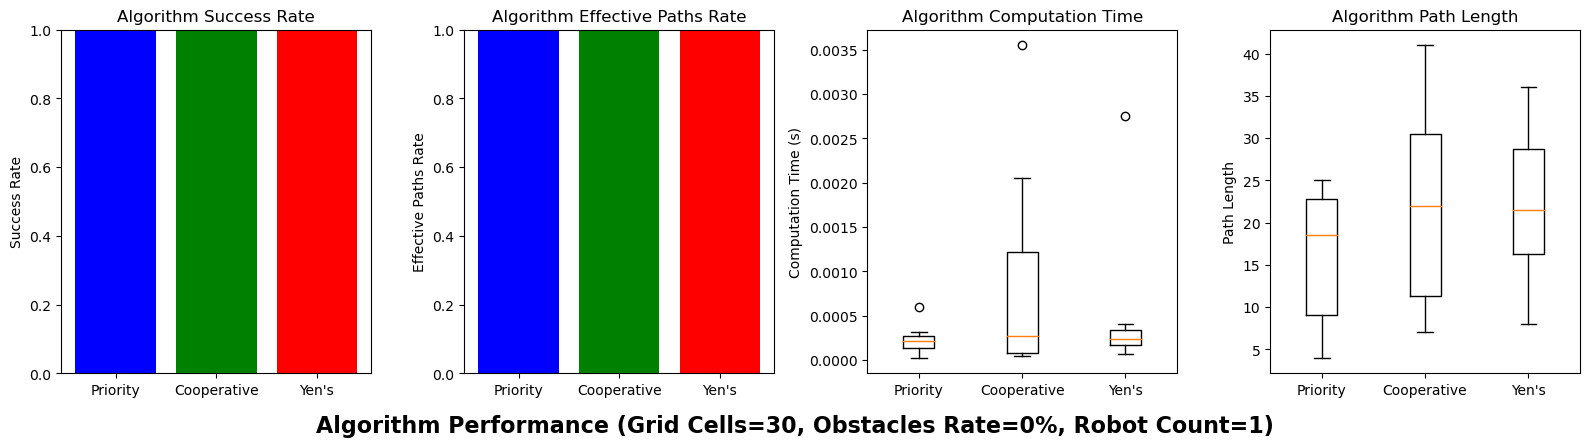

19.333333333333332
18.666666666666668
19.0
17.333333333333332
16.333333333333332
14.333333333333334
14.666666666666666
23.666666666666668
17.333333333333332
18.333333333333332
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0012526273727416991
Meaningful Path Lengths: [19.333333333333332, 18.666666666666668, 19.0, 17.333333333333332, 16.333333333333332, 14.333333333333334, 14.666666666666666, 23.666666666666668, 17.333333333333332, 18.333333333333332]
34.666666666666664
21.666666666666668
13.0
22.333333333333332
25.333333333333332
18.333333333333332
28.333333333333332
18.666666666666668
25.333333333333332
31.666666666666668
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.005801153182983398
Meaningful Path Lengths: [34.666666666666664, 21.666666666666668, 13.0, 22.333333333333332, 25.333333333333332, 18.333333333333332, 28.333333333333332, 18.666666666666668, 25.333333333333332, 31.666666666666668]
18.0
21.666666666666668
21.333333333333332


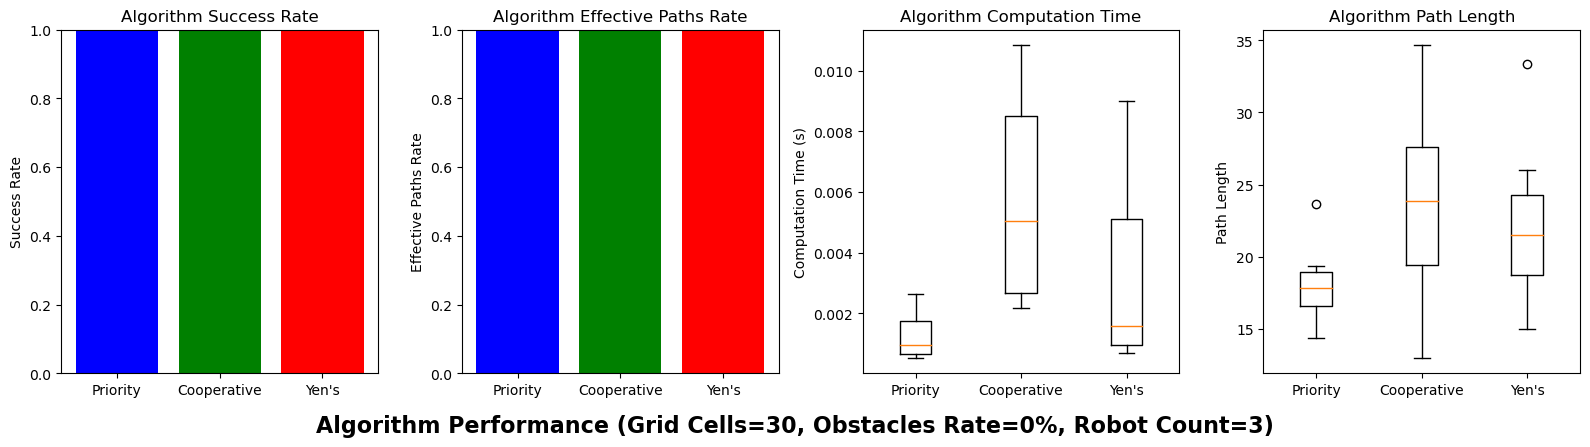

20.0
17.2
16.2
28.6
15.0
17.2
16.8
22.6
19.4
18.4
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0033548355102539064
Meaningful Path Lengths: [20.0, 17.2, 16.2, 28.6, 15.0, 17.2, 16.8, 22.6, 19.4, 18.4]
19.8
16.2
23.75
21.6
18.8
17.4
32.8
21.2
23.0
17.4
Success Rate: 0.9
Effective Path Rate: 0.9800000000000001
Average Computation Time: 0.006544280052185059
Meaningful Path Lengths: [19.8, 16.2, 21.6, 18.8, 17.4, 32.8, 21.2, 23.0, 17.4]
14.6
22.0
20.4
14.2
16.8
12.8
23.4
19.4
15.6
21.2
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0028011322021484373
Meaningful Path Lengths: [14.6, 22.0, 20.4, 14.2, 16.8, 12.8, 23.4, 19.4, 15.6, 21.2]


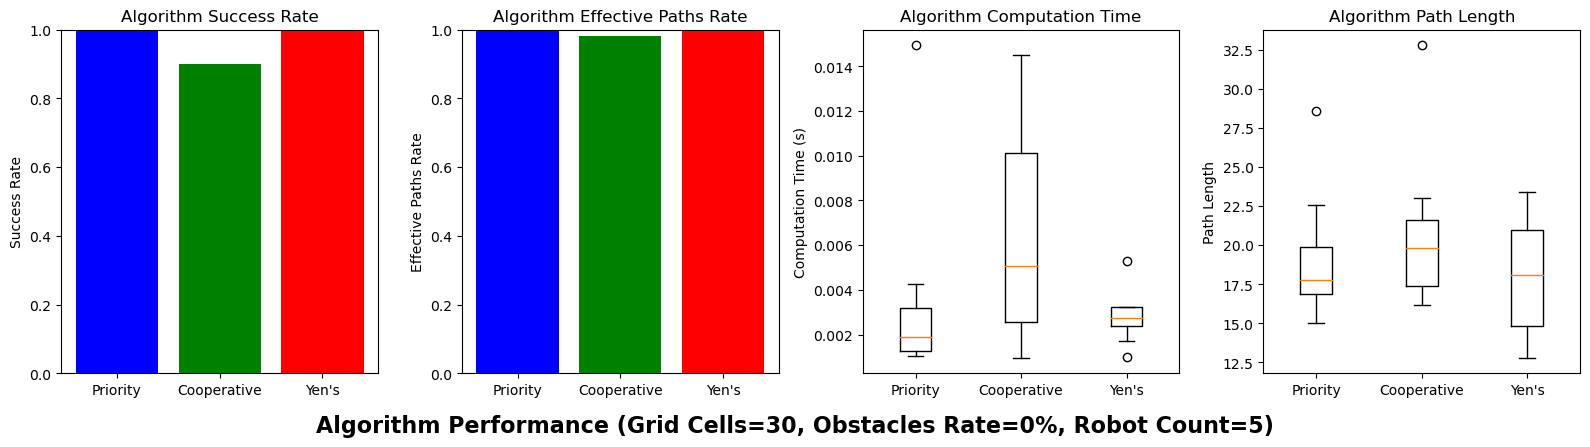

22.285714285714285
25.857142857142858
19.0
26.428571428571427
20.857142857142858
20.285714285714285
22.142857142857142
24.285714285714285
11.0
19.714285714285715
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.005058598518371582
Meaningful Path Lengths: [22.285714285714285, 25.857142857142858, 19.0, 26.428571428571427, 20.857142857142858, 20.285714285714285, 22.142857142857142, 24.285714285714285, 11.0, 19.714285714285715]
37.666666666666664
26.333333333333332
23.142857142857142
20.142857142857142
17.142857142857142
29.571428571428573
22.142857142857142
38.285714285714285
19.857142857142858
25.571428571428573
Success Rate: 0.8
Effective Path Rate: 0.9714285714285714
Average Computation Time: 0.01035616397857666
Meaningful Path Lengths: [23.142857142857142, 20.142857142857142, 17.142857142857142, 29.571428571428573, 22.142857142857142, 38.285714285714285, 19.857142857142858, 25.571428571428573]
16.857142857142858
15.142857142857142
20.142857142857142
19.2857142857

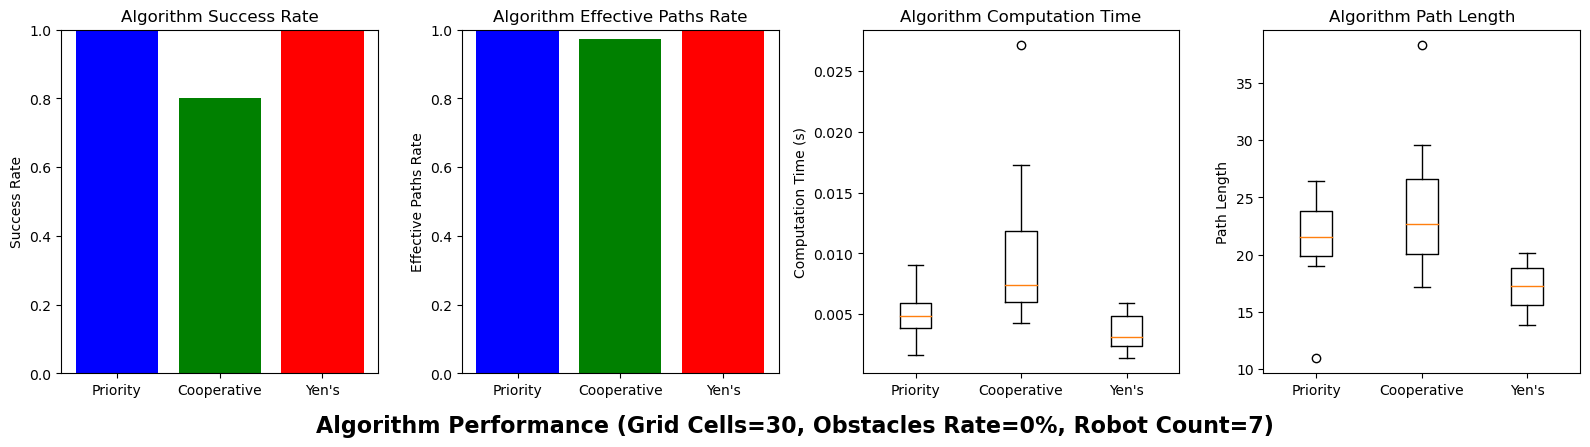

17.444444444444443
18.0
22.22222222222222
19.666666666666668
16.666666666666668
20.77777777777778
19.11111111111111
20.333333333333332
18.88888888888889
18.333333333333332
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.005940842628479004
Meaningful Path Lengths: [17.444444444444443, 18.0, 22.22222222222222, 19.666666666666668, 16.666666666666668, 20.77777777777778, 19.11111111111111, 20.333333333333332, 18.88888888888889, 18.333333333333332]
14.777777777777779
14.666666666666666
25.5
24.125
19.88888888888889
24.285714285714285
28.375
18.88888888888889
26.555555555555557
18.88888888888889
Success Rate: 0.6
Effective Path Rate: 0.9444444444444444
Average Computation Time: 0.011375927925109863
Meaningful Path Lengths: [14.777777777777779, 14.666666666666666, 19.88888888888889, 18.88888888888889, 26.555555555555557, 18.88888888888889]
22.88888888888889
18.11111111111111
17.77777777777778
19.88888888888889
23.333333333333332
17.444444444444443
21.666666666666668
19.5

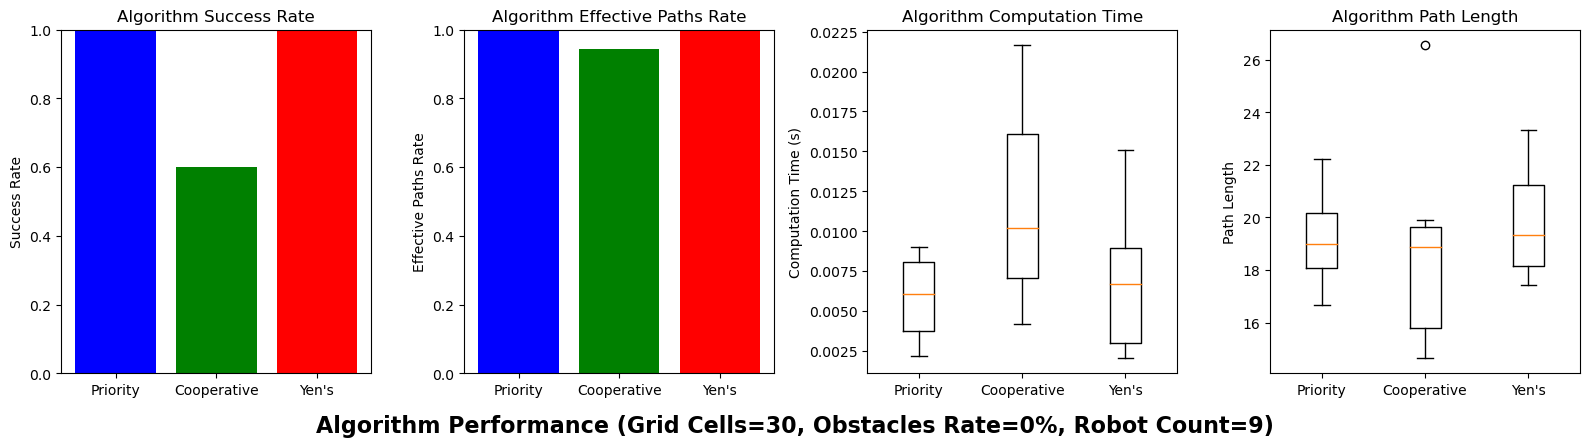

18.0
20.0
11.0
42.0
25.0
32.0
20.0
12.0
Success Rate: 0.8
Effective Path Rate: 0.8
Average Computation Time: 0.0021858453750610352
Meaningful Path Lengths: [18.0, 20.0, 11.0, 42.0, 25.0, 32.0, 20.0, 12.0]
18.0
28.0
40.0
16.0
10.0
18.0
17.0
17.0
31.0
7.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0003137111663818359
Meaningful Path Lengths: [18.0, 28.0, 40.0, 16.0, 10.0, 18.0, 17.0, 17.0, 31.0, 7.0]
17.0
13.0
18.0
31.0
48.0
15.0
11.0
33.0
23.0
Success Rate: 0.9
Effective Path Rate: 0.9
Average Computation Time: 0.0018246889114379883
Meaningful Path Lengths: [17.0, 13.0, 18.0, 31.0, 48.0, 15.0, 11.0, 33.0, 23.0]


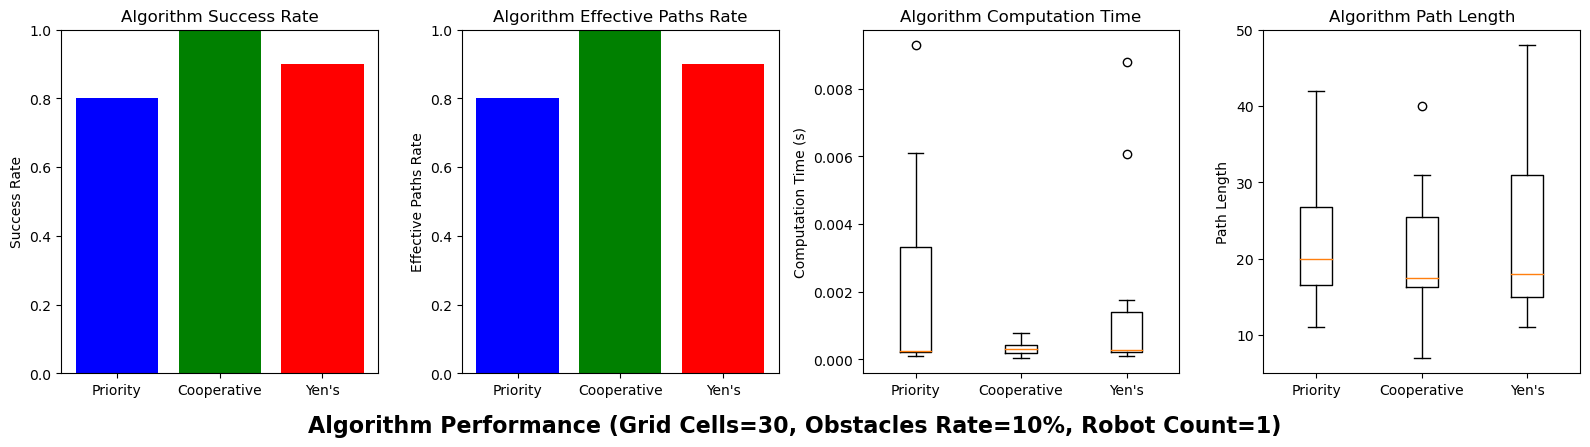

17.5
14.0
14.5
21.0
14.0
19.0
24.0
18.5
29.333333333333332
17.333333333333332
Success Rate: 0.4
Effective Path Rate: 0.7999999999999999
Average Computation Time: 0.005127859115600586
Meaningful Path Lengths: [14.0, 14.0, 29.333333333333332, 17.333333333333332]
26.666666666666668
24.666666666666668
23.0
15.0
15.5
17.0
23.5
16.5
28.5
16.333333333333332
Success Rate: 0.3
Effective Path Rate: 0.7666666666666666
Average Computation Time: 0.006429409980773926
Meaningful Path Lengths: [26.666666666666668, 24.666666666666668, 16.333333333333332]
27.333333333333332
19.333333333333332
25.0
22.0
15.333333333333334
22.5
9.0
31.0
19.0
28.666666666666668
Success Rate: 0.6
Effective Path Rate: 0.7999999999999999
Average Computation Time: 0.0048163414001464845
Meaningful Path Lengths: [27.333333333333332, 19.333333333333332, 22.0, 15.333333333333334, 19.0, 28.666666666666668]


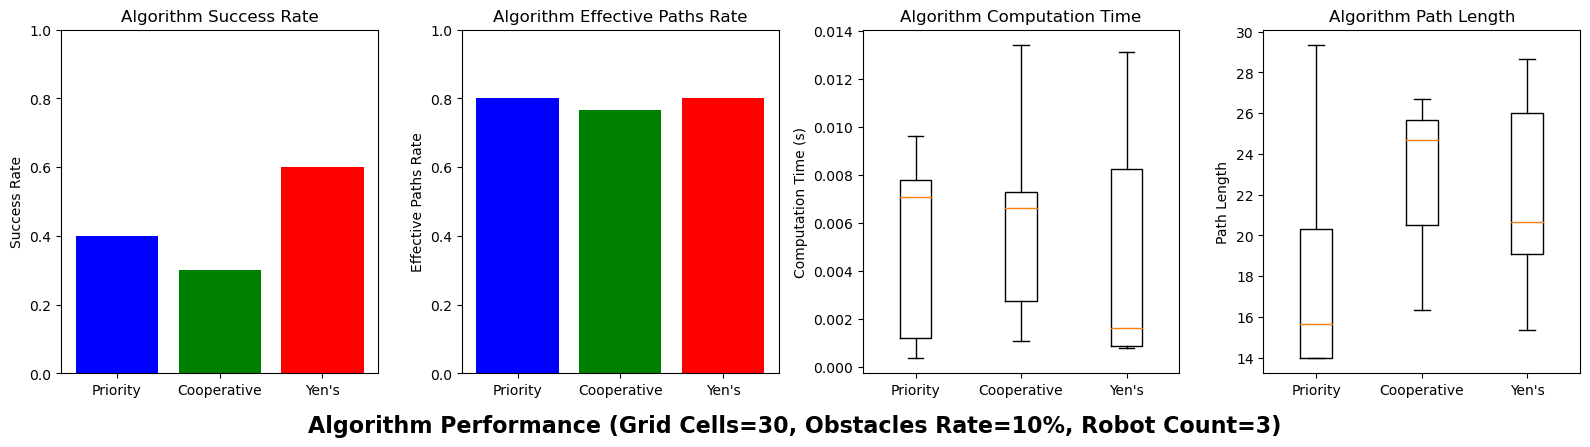

20.6
20.0
20.2
15.25
30.0
25.8
20.0
22.8
31.5
20.2
Success Rate: 0.7
Effective Path Rate: 0.9
Average Computation Time: 0.0065860748291015625
Meaningful Path Lengths: [20.6, 20.2, 30.0, 25.8, 20.0, 22.8, 20.2]
23.75
25.5
46.75
34.75
32.6
14.333333333333334
20.333333333333332
27.0
38.0
26.8
Success Rate: 0.2
Effective Path Rate: 0.78
Average Computation Time: 0.009285736083984374
Meaningful Path Lengths: [32.6, 26.8]
13.8
23.2
17.8
15.8
12.4
19.0
22.2
19.6
24.0
18.0
Success Rate: 0.9
Effective Path Rate: 0.9800000000000001
Average Computation Time: 0.003814291954040527
Meaningful Path Lengths: [13.8, 23.2, 17.8, 15.8, 12.4, 19.0, 22.2, 19.6, 18.0]


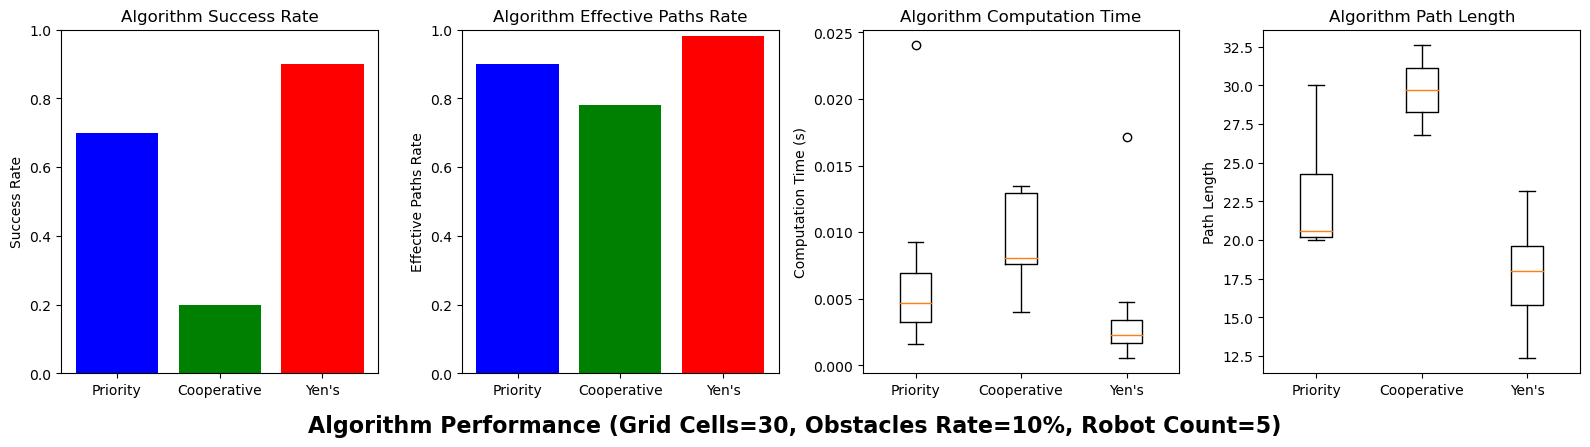

14.0
20.142857142857142
14.166666666666666
24.428571428571427
22.285714285714285
20.142857142857142
16.5
19.0
21.0
19.571428571428573
Success Rate: 0.5
Effective Path Rate: 0.9142857142857144
Average Computation Time: 0.007832598686218262
Meaningful Path Lengths: [20.142857142857142, 24.428571428571427, 22.285714285714285, 20.142857142857142, 19.571428571428573]
28.5
16.0
15.4
27.6
18.666666666666668
14.857142857142858
24.166666666666668
36.75
16.571428571428573
18.571428571428573
Success Rate: 0.4
Effective Path Rate: 0.8571428571428571
Average Computation Time: 0.009520149230957032
Meaningful Path Lengths: [16.0, 14.857142857142858, 16.571428571428573, 18.571428571428573]
18.857142857142858
17.571428571428573
12.0
18.285714285714285
17.857142857142858
18.428571428571427
23.0
24.571428571428573
15.0
22.2
Success Rate: 0.7
Effective Path Rate: 0.9428571428571428
Average Computation Time: 0.006480550765991211
Meaningful Path Lengths: [18.857142857142858, 17.571428571428573, 12.0, 18.285

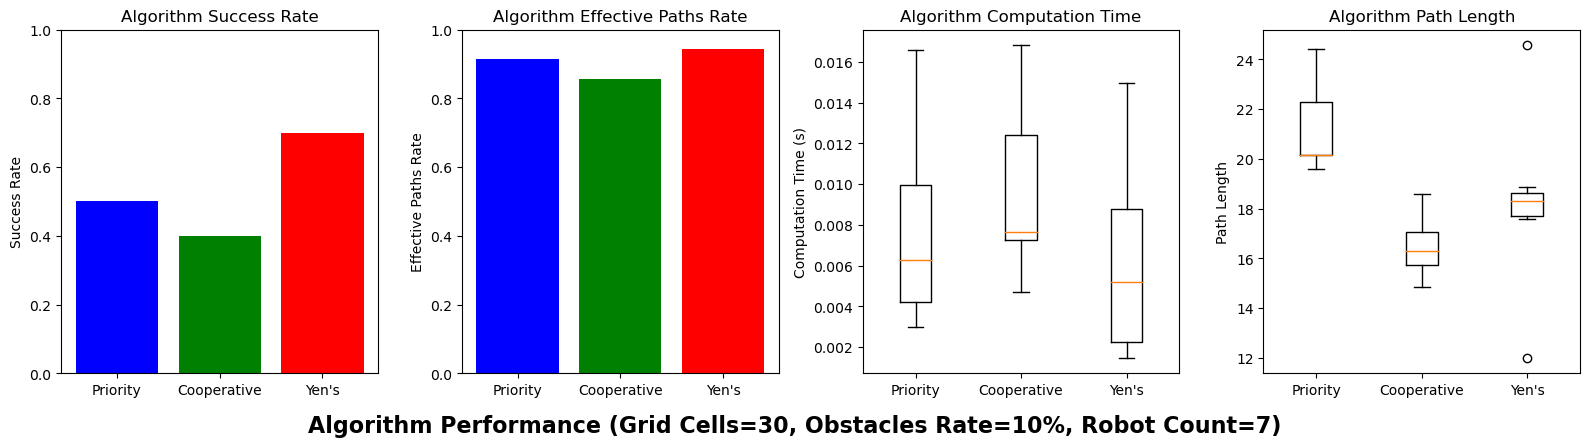

20.22222222222222
22.8
17.571428571428573
14.0
21.5
17.375
20.75
21.428571428571427
12.666666666666666
17.375
Success Rate: 0.1
Effective Path Rate: 0.8222222222222223
Average Computation Time: 0.014392995834350586
Meaningful Path Lengths: [20.22222222222222]
28.714285714285715
20.285714285714285
23.285714285714285
21.25
19.875
21.625
22.8
10.75
21.25
23.125
Success Rate: 0.0
Effective Path Rate: 0.7333333333333333
Average Computation Time: 0.011525464057922364
Meaningful Path Lengths: []
19.75
21.22222222222222
18.444444444444443
17.0
25.714285714285715
21.285714285714285
18.125
18.625
14.142857142857142
14.571428571428571
Success Rate: 0.3
Effective Path Rate: 0.8777777777777778
Average Computation Time: 0.011654019355773926
Meaningful Path Lengths: [21.22222222222222, 18.444444444444443, 17.0]


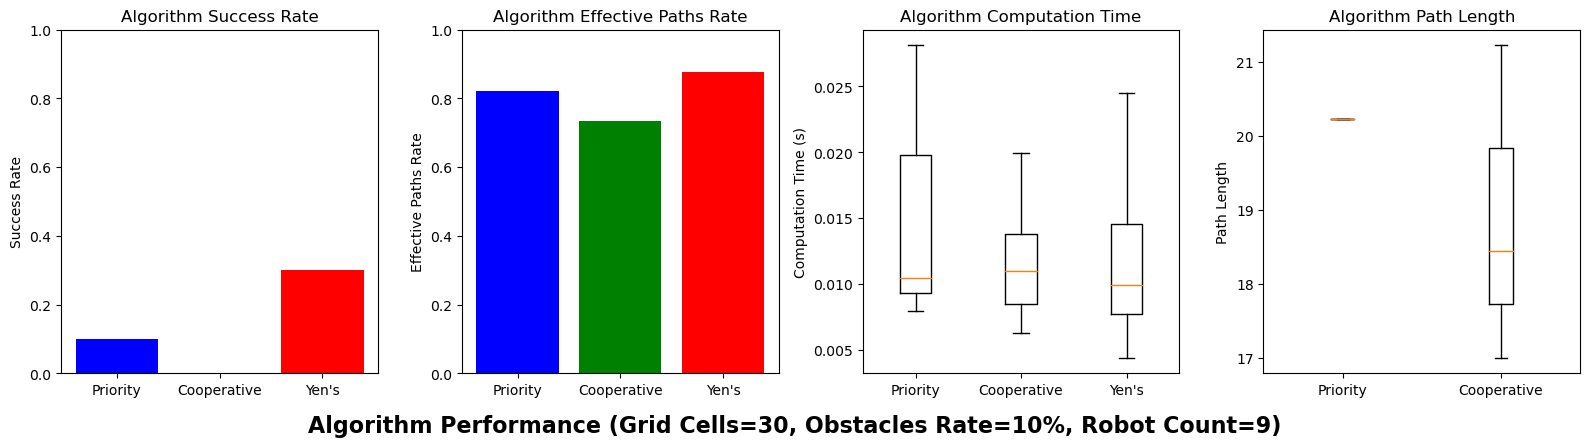

43.0
24.0
15.0
9.0
4.0
45.0
1.0
37.0
Success Rate: 0.8
Effective Path Rate: 0.8
Average Computation Time: 0.0015990495681762694
Meaningful Path Lengths: [43.0, 24.0, 15.0, 9.0, 4.0, 45.0, 1.0, 37.0]
16.0
24.0
15.0
18.0
27.0
23.0
9.0
10.0
Success Rate: 0.8
Effective Path Rate: 0.8
Average Computation Time: 0.0012117147445678711
Meaningful Path Lengths: [16.0, 24.0, 15.0, 18.0, 27.0, 23.0, 9.0, 10.0]
18.0
9.0
33.0
11.0
20.0
23.0
23.0
25.0
14.0
Success Rate: 0.9
Effective Path Rate: 0.9
Average Computation Time: 0.000790858268737793
Meaningful Path Lengths: [18.0, 9.0, 33.0, 11.0, 20.0, 23.0, 23.0, 25.0, 14.0]


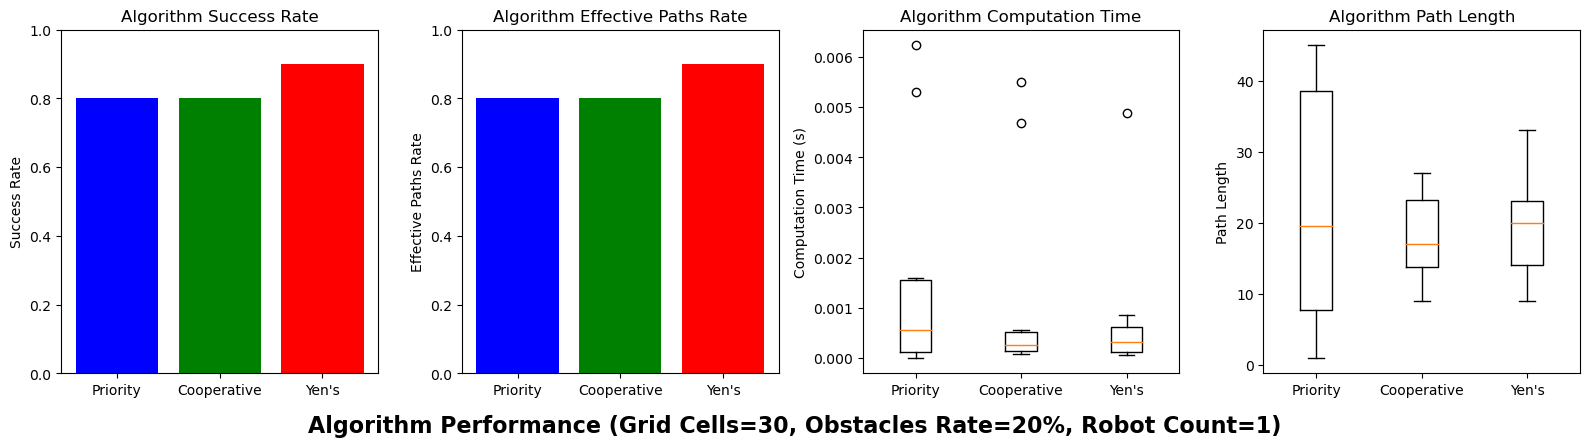

14.0
16.333333333333332
28.0
11.666666666666666
28.333333333333332
24.666666666666668
21.0
8.5
26.0
20.0
Success Rate: 0.7
Effective Path Rate: 0.9
Average Computation Time: 0.0029580116271972655
Meaningful Path Lengths: [14.0, 16.333333333333332, 11.666666666666666, 28.333333333333332, 24.666666666666668, 21.0, 26.0]
15.0
29.333333333333332
22.666666666666668
28.666666666666668
19.333333333333332
19.0
3.5
22.333333333333332
32.0
33.666666666666664
Success Rate: 0.8
Effective Path Rate: 0.9333333333333332
Average Computation Time: 0.0029886722564697265
Meaningful Path Lengths: [15.0, 29.333333333333332, 22.666666666666668, 28.666666666666668, 19.333333333333332, 19.0, 22.333333333333332, 33.666666666666664]
28.666666666666668
17.0
11.5
27.666666666666668
17.333333333333332
26.666666666666668
24.333333333333332
25.0
27.666666666666668
26.0
Success Rate: 0.7
Effective Path Rate: 0.9
Average Computation Time: 0.003605818748474121
Meaningful Path Lengths: [28.666666666666668, 27.6666666666

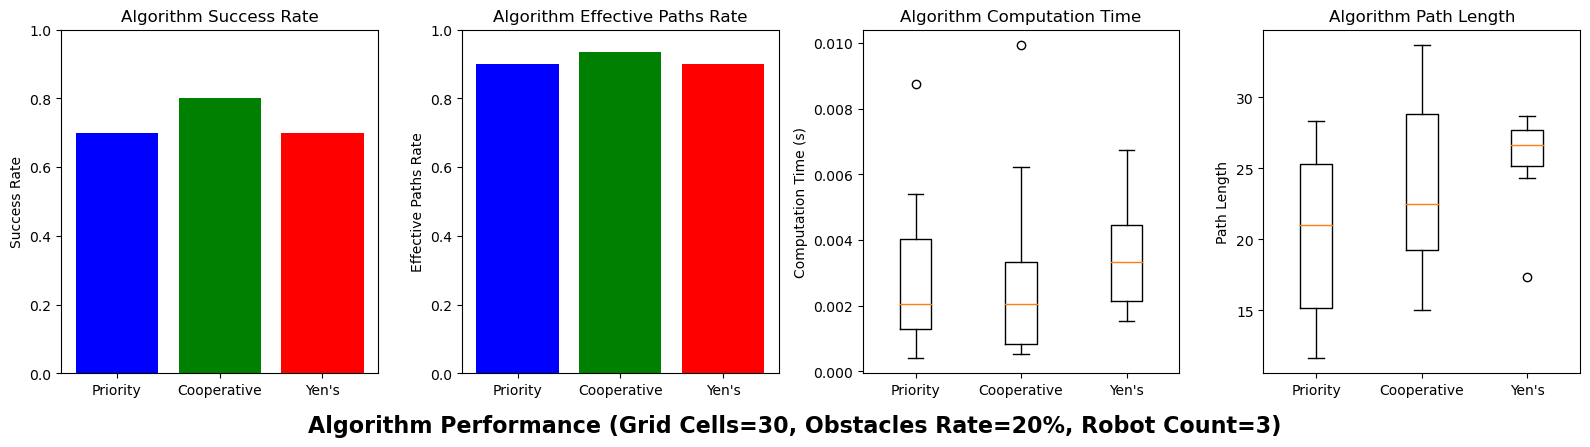

19.0
23.0
18.6
17.5
21.75
18.5
20.25
27.0
33.2
21.0
Success Rate: 0.5
Effective Path Rate: 0.86
Average Computation Time: 0.006892108917236328
Meaningful Path Lengths: [23.0, 18.6, 27.0, 33.2, 21.0]
34.5
26.666666666666668
12.333333333333334
24.0
18.0
19.75
23.333333333333332
16.8
22.6
10.25
Success Rate: 0.3
Effective Path Rate: 0.76
Average Computation Time: 0.006304192543029785
Meaningful Path Lengths: [18.0, 16.8, 22.6]
17.4
23.0
20.0
19.0
18.2
24.333333333333332
29.25
18.25
19.5
19.4
Success Rate: 0.3
Effective Path Rate: 0.8
Average Computation Time: 0.006918501853942871
Meaningful Path Lengths: [17.4, 18.2, 19.4]


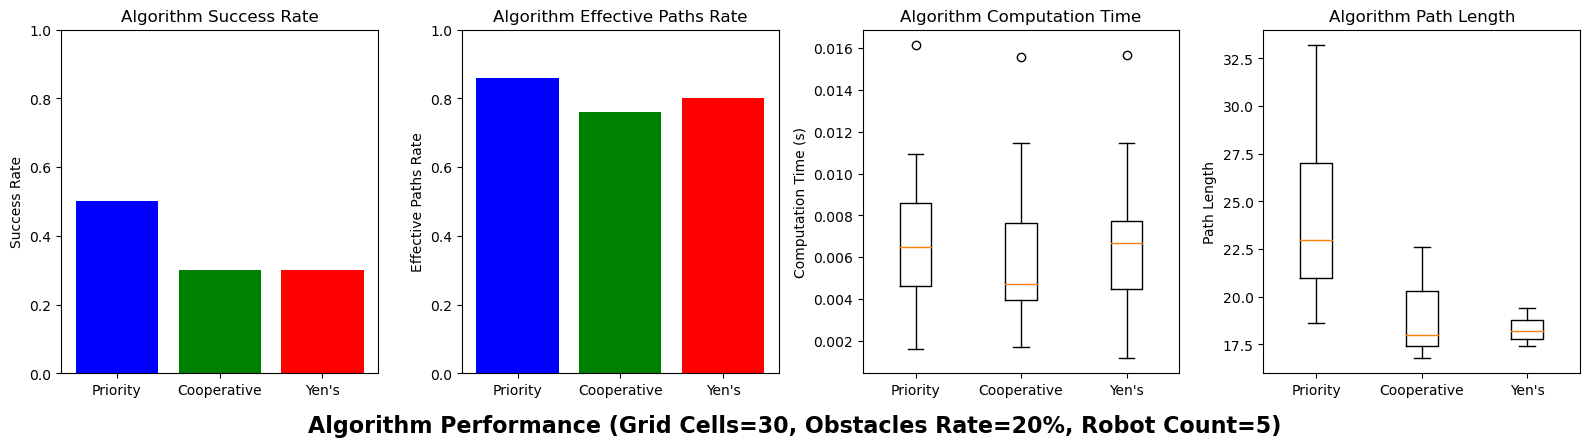

21.428571428571427
23.8
30.2
21.285714285714285
18.0
19.428571428571427
17.666666666666668
21.166666666666668
22.6
15.0
Success Rate: 0.3
Effective Path Rate: 0.8285714285714285
Average Computation Time: 0.009863710403442383
Meaningful Path Lengths: [21.428571428571427, 21.285714285714285, 19.428571428571427]
26.6
35.4
29.0
34.0
25.0
26.75
18.75
32.333333333333336
38.333333333333336
14.0
Success Rate: 0.0
Effective Path Rate: 0.6714285714285715
Average Computation Time: 0.011559796333312989
Meaningful Path Lengths: []
20.166666666666668
16.166666666666668
22.25
20.285714285714285
15.571428571428571
26.0
23.0
19.428571428571427
17.166666666666668
15.714285714285714
Success Rate: 0.4
Effective Path Rate: 0.8285714285714285
Average Computation Time: 0.00915219783782959
Meaningful Path Lengths: [20.285714285714285, 15.571428571428571, 19.428571428571427, 15.714285714285714]


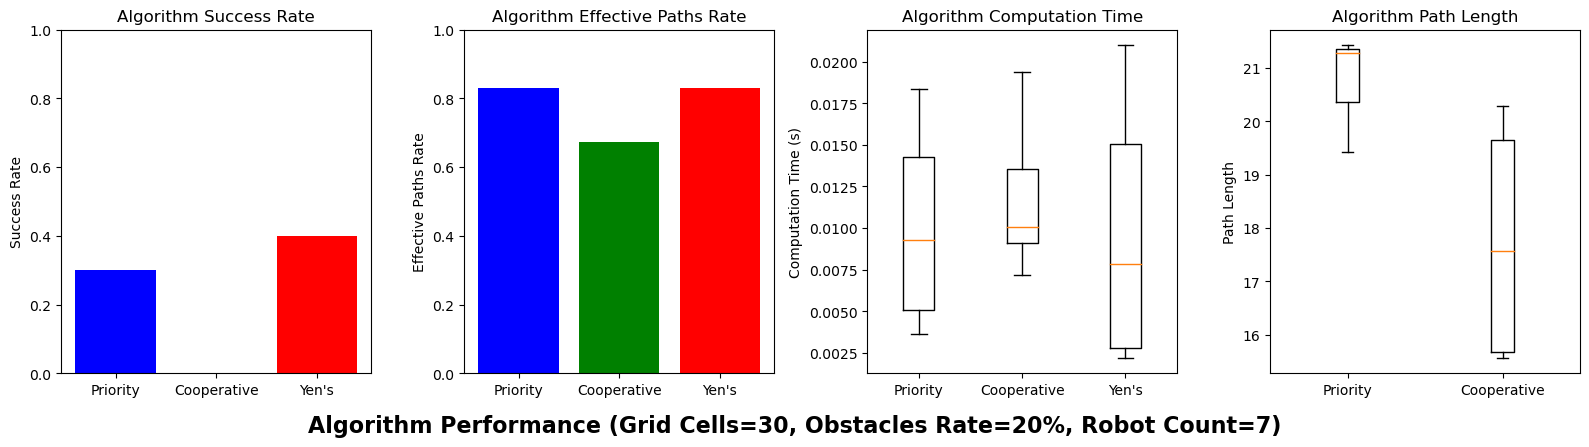

18.285714285714285
18.666666666666668
18.666666666666668
12.375
16.857142857142858
17.571428571428573
19.625
20.4
25.833333333333332
17.25
Success Rate: 0.2
Effective Path Rate: 0.8222222222222223
Average Computation Time: 0.011114859580993652
Meaningful Path Lengths: [18.666666666666668, 18.666666666666668]
24.571428571428573
15.666666666666666
20.857142857142858
21.0
20.285714285714285
22.142857142857142
24.142857142857142
26.166666666666668
26.833333333333332
18.375
Success Rate: 0.0
Effective Path Rate: 0.7333333333333333
Average Computation Time: 0.009453105926513671
Meaningful Path Lengths: []
15.333333333333334
23.11111111111111
25.833333333333332
20.77777777777778
19.5
23.333333333333332
19.0
19.11111111111111
16.25
17.25
Success Rate: 0.4
Effective Path Rate: 0.8777777777777778
Average Computation Time: 0.009401178359985352
Meaningful Path Lengths: [15.333333333333334, 23.11111111111111, 20.77777777777778, 19.11111111111111]


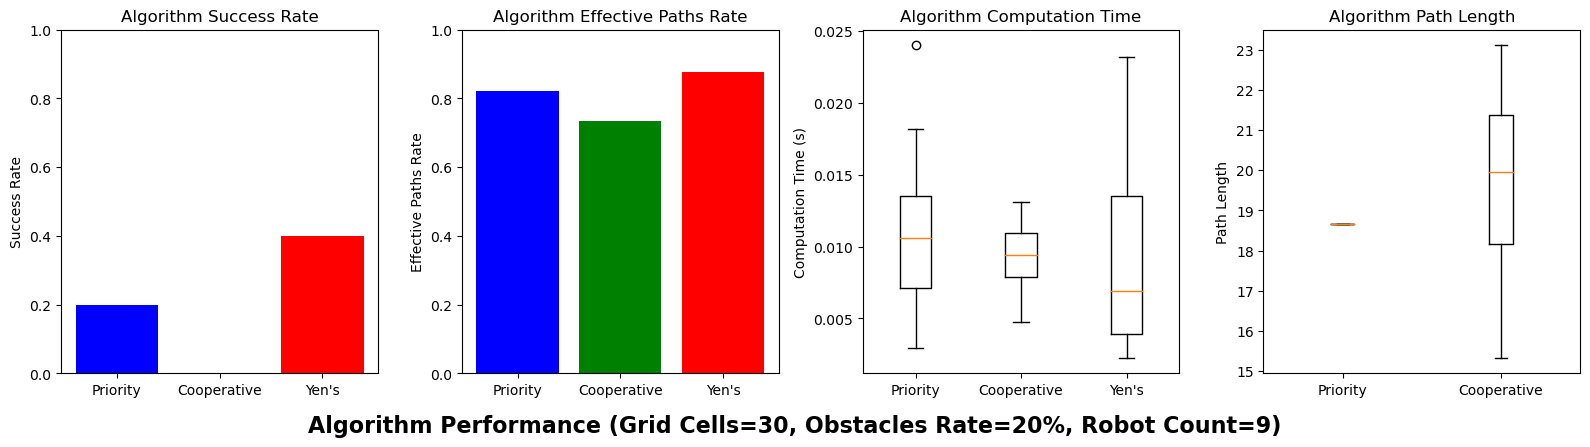

19.0
34.0
28.0
43.0
31.0
18.0
28.0
Success Rate: 0.7
Effective Path Rate: 0.7
Average Computation Time: 0.007635736465454101
Meaningful Path Lengths: [19.0, 34.0, 28.0, 43.0, 31.0, 18.0, 28.0]
35.0
39.0
18.0
31.0
27.0
17.0
34.0
Success Rate: 0.7
Effective Path Rate: 0.7
Average Computation Time: 0.001223611831665039
Meaningful Path Lengths: [35.0, 39.0, 18.0, 31.0, 27.0, 17.0, 34.0]
16.0
35.0
10.0
17.0
28.0
15.0
7.0
19.0
Success Rate: 0.8
Effective Path Rate: 0.8
Average Computation Time: 0.0010591268539428711
Meaningful Path Lengths: [16.0, 35.0, 10.0, 17.0, 28.0, 15.0, 7.0, 19.0]


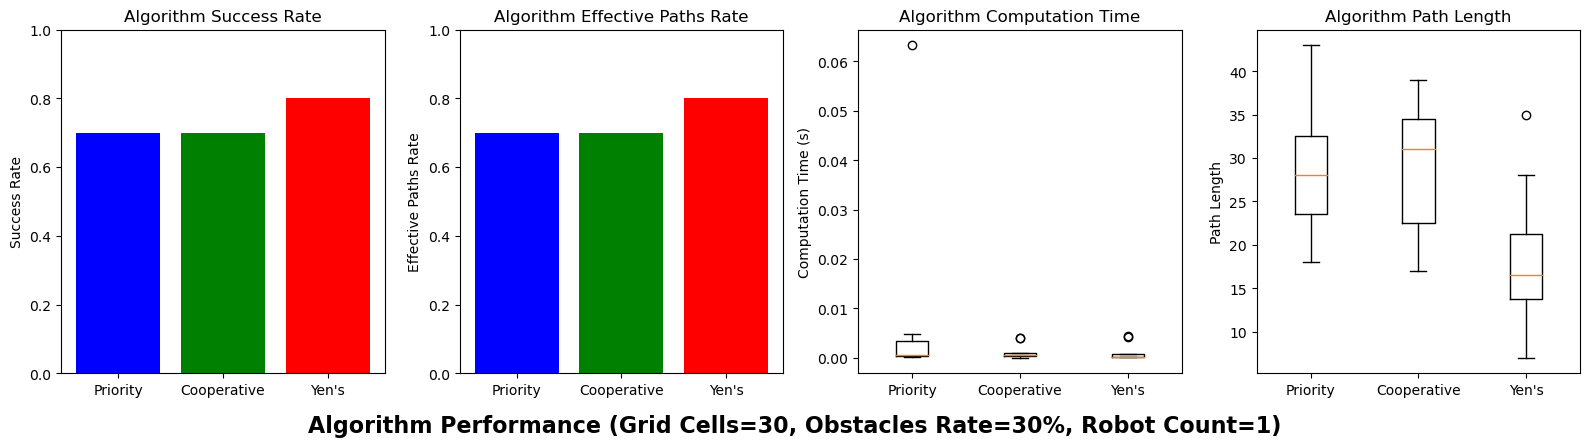

34.0
17.5
29.0
26.0
22.666666666666668
24.0
20.0
42.0
34.0
Success Rate: 0.1
Effective Path Rate: 0.43333333333333335
Average Computation Time: 0.007286930084228515
Meaningful Path Lengths: [22.666666666666668]
27.5
17.5
15.0
12.666666666666666
26.5
25.666666666666668
29.5
22.666666666666668
16.5
Success Rate: 0.3
Effective Path Rate: 0.6666666666666666
Average Computation Time: 0.004201936721801758
Meaningful Path Lengths: [12.666666666666666, 25.666666666666668, 22.666666666666668]
23.0
21.333333333333332
23.0
17.333333333333332
21.666666666666668
25.333333333333332
34.666666666666664
28.0
27.0
30.5
Success Rate: 0.6
Effective Path Rate: 0.8333333333333334
Average Computation Time: 0.00316011905670166
Meaningful Path Lengths: [23.0, 21.333333333333332, 17.333333333333332, 21.666666666666668, 25.333333333333332, 34.666666666666664]


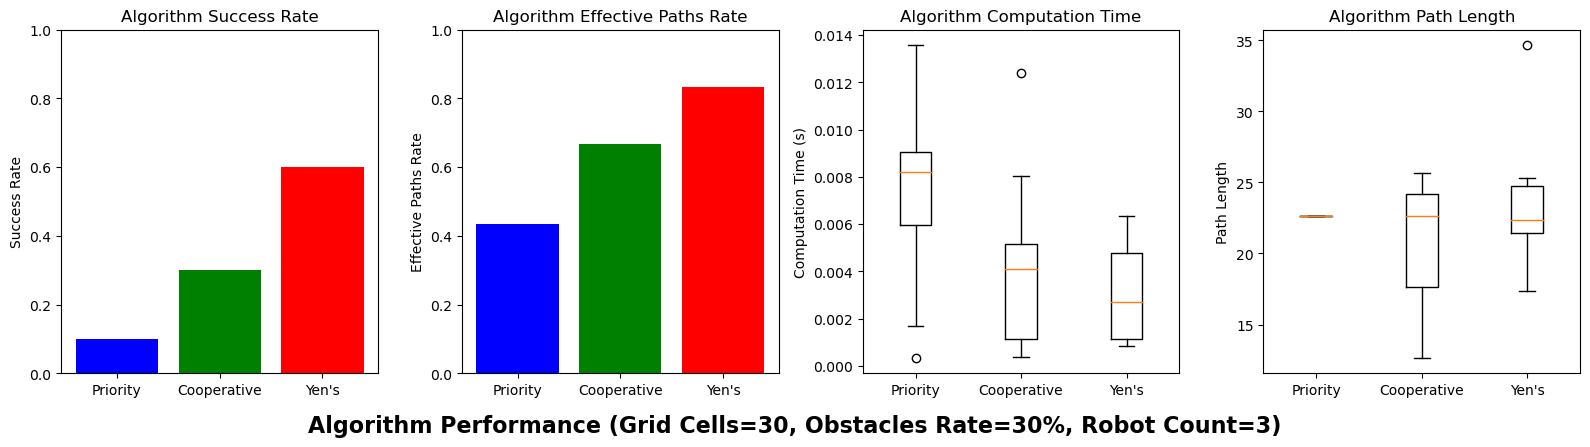

15.0
27.0
19.0
22.666666666666668
20.6
19.8
26.333333333333332
22.5
22.0
21.4
Success Rate: 0.4
Effective Path Rate: 0.78
Average Computation Time: 0.00543065071105957
Meaningful Path Lengths: [15.0, 20.6, 19.8, 21.4]
20.666666666666668
35.5
26.5
32.5
18.5
19.75
30.75
24.0
31.0
23.666666666666668
Success Rate: 0.0
Effective Path Rate: 0.62
Average Computation Time: 0.006711006164550781
Meaningful Path Lengths: []
11.0
23.0
32.25
18.75
15.25
8.5
19.75
23.2
25.25
24.5
Success Rate: 0.1
Effective Path Rate: 0.78
Average Computation Time: 0.006237316131591797
Meaningful Path Lengths: [23.2]


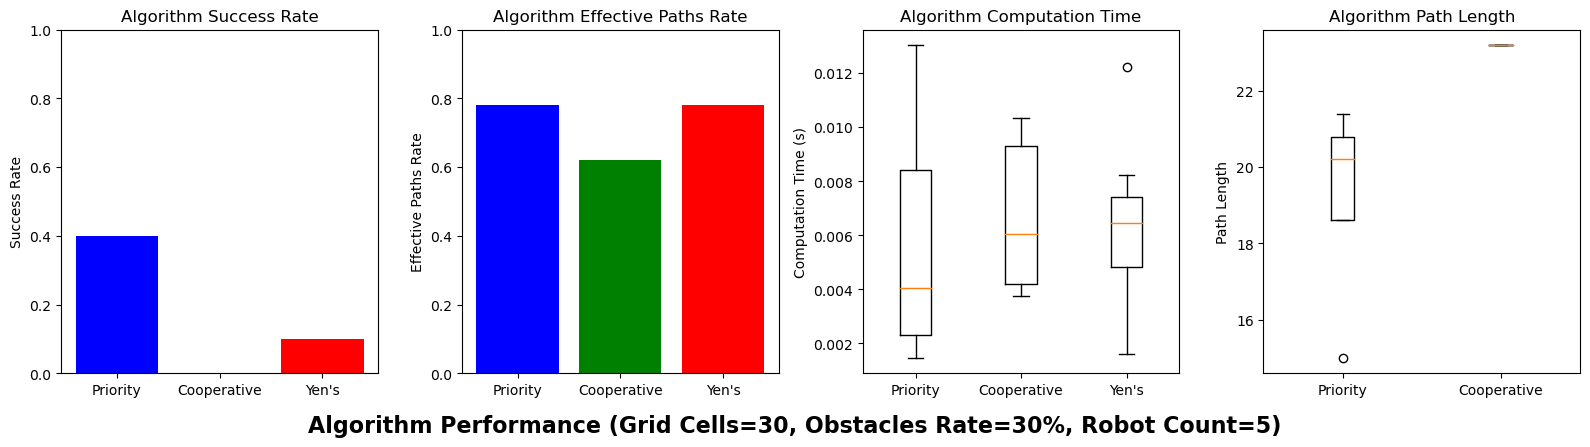

18.833333333333332
23.0
17.833333333333332
18.166666666666668
22.5
24.833333333333332
19.25
24.0
28.0
20.0
Success Rate: 0.0
Effective Path Rate: 0.6714285714285715
Average Computation Time: 0.009538722038269044
Meaningful Path Lengths: []
10.333333333333334
19.2
20.2
33.333333333333336
32.0
22.333333333333332
34.333333333333336
23.25
25.0
20.333333333333332
Success Rate: 0.0
Effective Path Rate: 0.6
Average Computation Time: 0.00745687484741211
Meaningful Path Lengths: []
17.0
24.666666666666668
20.666666666666668
19.4
26.0
15.0
21.2
34.0
18.666666666666668
23.25
Success Rate: 0.1
Effective Path Rate: 0.7000000000000001
Average Computation Time: 0.010855960845947265
Meaningful Path Lengths: [17.0]


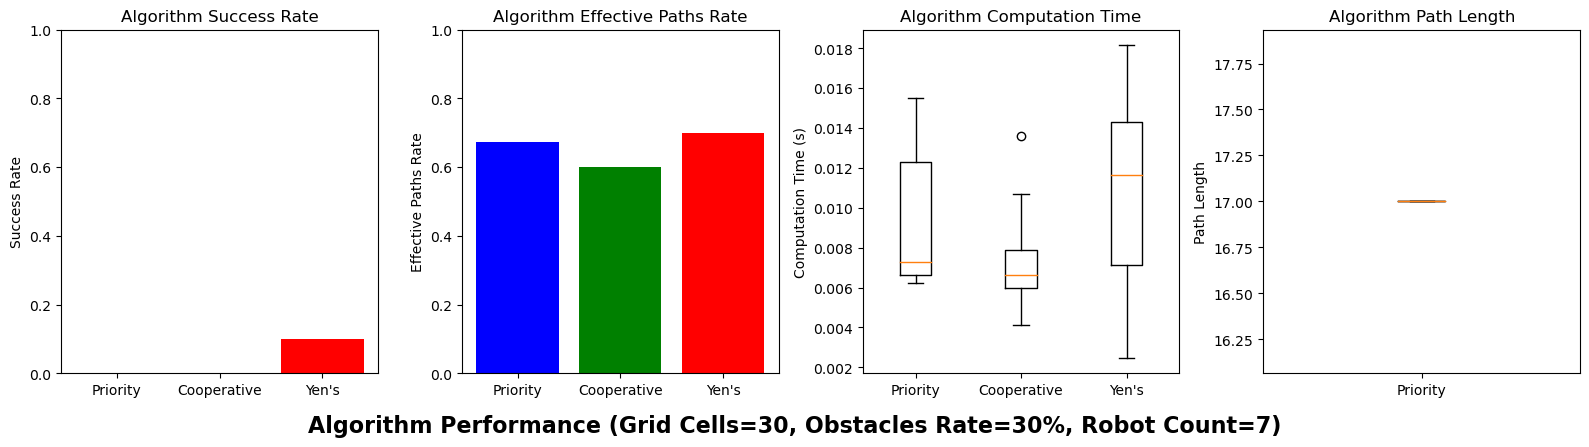

16.142857142857142
17.142857142857142
19.833333333333332
16.0
22.5
18.0
24.666666666666668
26.5
17.875
15.0
Success Rate: 0.0
Effective Path Rate: 0.6666666666666666
Average Computation Time: 0.01564812660217285
Meaningful Path Lengths: []
25.5
39.666666666666664
23.833333333333332
8.11111111111111
21.0
16.857142857142858
28.6
30.0
19.0
17.857142857142858
Success Rate: 0.1
Effective Path Rate: 0.6000000000000001
Average Computation Time: 0.009998583793640136
Meaningful Path Lengths: [8.11111111111111]
24.142857142857142
18.428571428571427
19.0
13.6
21.666666666666668
25.5
19.4
18.285714285714285
19.714285714285715
18.875
Success Rate: 0.0
Effective Path Rate: 0.7333333333333333
Average Computation Time: 0.012692832946777343
Meaningful Path Lengths: []


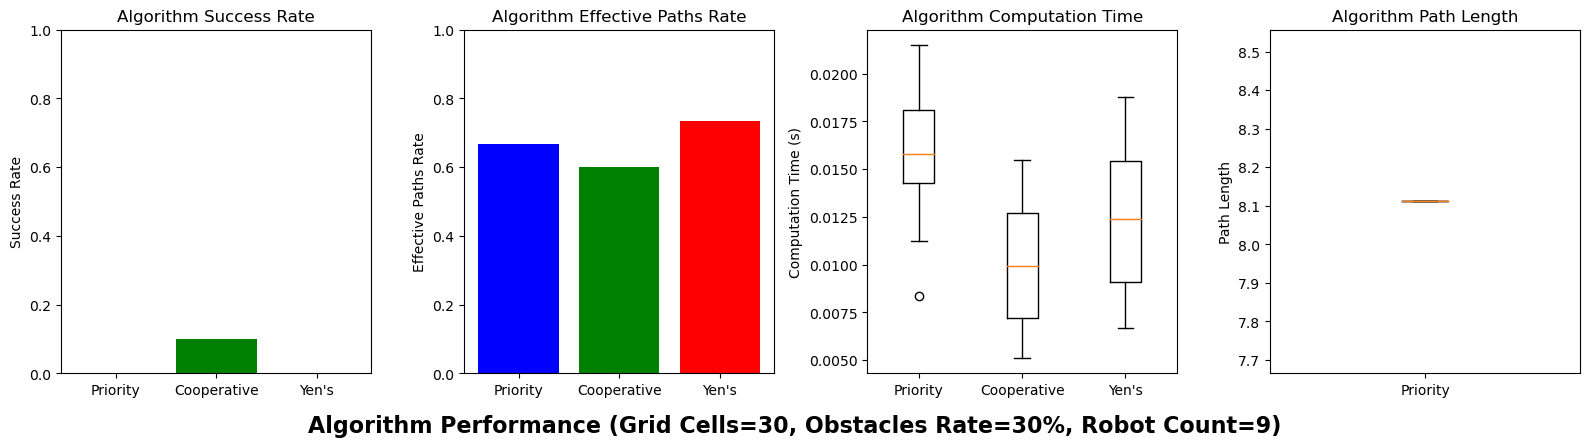

37.0
13.0
43.0
Success Rate: 0.3
Effective Path Rate: 0.3
Average Computation Time: 0.0014777421951293946
Meaningful Path Lengths: [37.0, 13.0, 43.0]
33.0
9.0
17.0
29.0
52.0
Success Rate: 0.5
Effective Path Rate: 0.5
Average Computation Time: 0.0015118837356567383
Meaningful Path Lengths: [33.0, 9.0, 17.0, 29.0, 52.0]
28.0
32.0
9.0
5.0
50.0
Success Rate: 0.5
Effective Path Rate: 0.5
Average Computation Time: 0.0012715816497802734
Meaningful Path Lengths: [28.0, 32.0, 9.0, 5.0, 50.0]


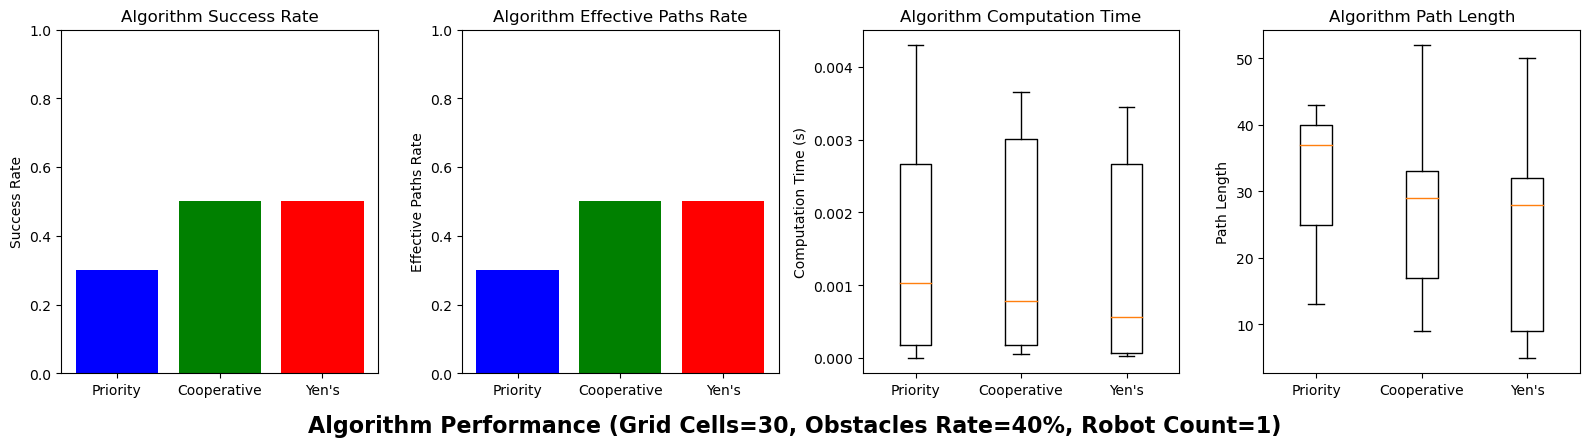

18.0
18.666666666666668
34.0
16.0
29.0
6.0
26.0
24.0
20.0
Success Rate: 0.3
Effective Path Rate: 0.6
Average Computation Time: 0.003716301918029785
Meaningful Path Lengths: [18.666666666666668, 24.0, 20.0]
7.0
31.0
31.0
3.0
41.0
26.0
18.666666666666668
10.666666666666666
33.5
Success Rate: 0.2
Effective Path Rate: 0.5333333333333333
Average Computation Time: 0.0038709163665771483
Meaningful Path Lengths: [18.666666666666668, 10.666666666666666]
31.0
40.0
19.0
23.0
28.5
23.0
31.0
24.0
32.0
8.0
Success Rate: 0.2
Effective Path Rate: 0.6666666666666666
Average Computation Time: 0.004201197624206543
Meaningful Path Lengths: [19.0, 24.0]


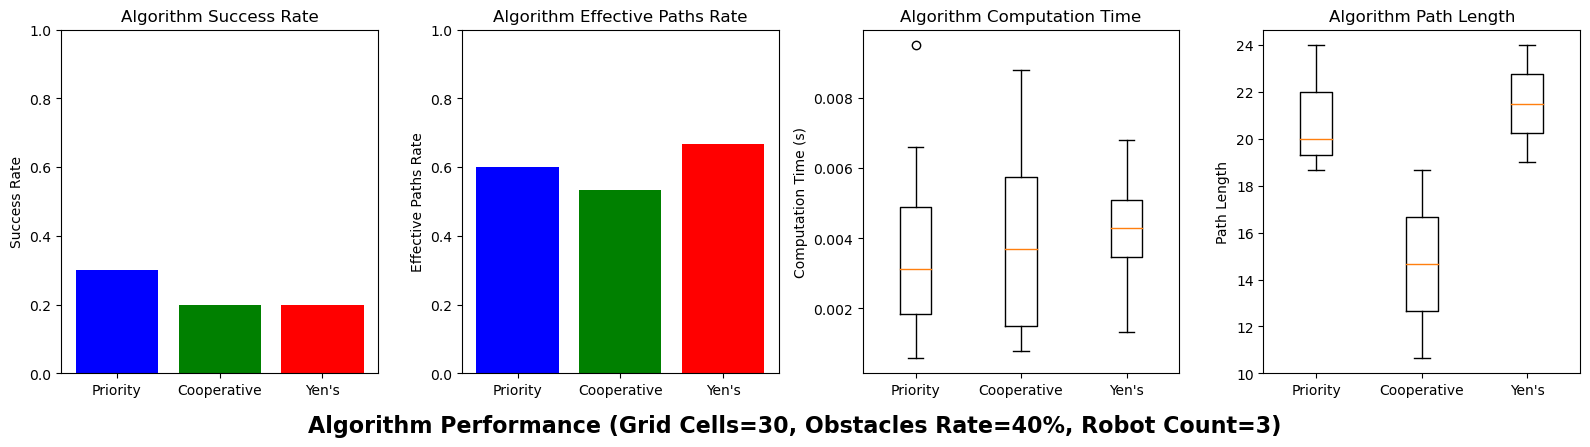

31.0
35.5
31.75
24.666666666666668
13.0
21.666666666666668
35.0
23.25
22.5
Success Rate: 0.0
Effective Path Rate: 0.5
Average Computation Time: 0.007053160667419433
Meaningful Path Lengths: []
14.0
17.0
31.666666666666668
18.0
33.5
20.666666666666668
18.0
18.333333333333332
42.0
14.0
Success Rate: 0.0
Effective Path Rate: 0.45999999999999996
Average Computation Time: 0.004521608352661133
Meaningful Path Lengths: []
8.0
21.8
14.333333333333334
28.666666666666668
33.0
14.666666666666666
23.75
32.0
13.333333333333334
27.0
Success Rate: 0.1
Effective Path Rate: 0.5599999999999999
Average Computation Time: 0.005833053588867187
Meaningful Path Lengths: [21.8]


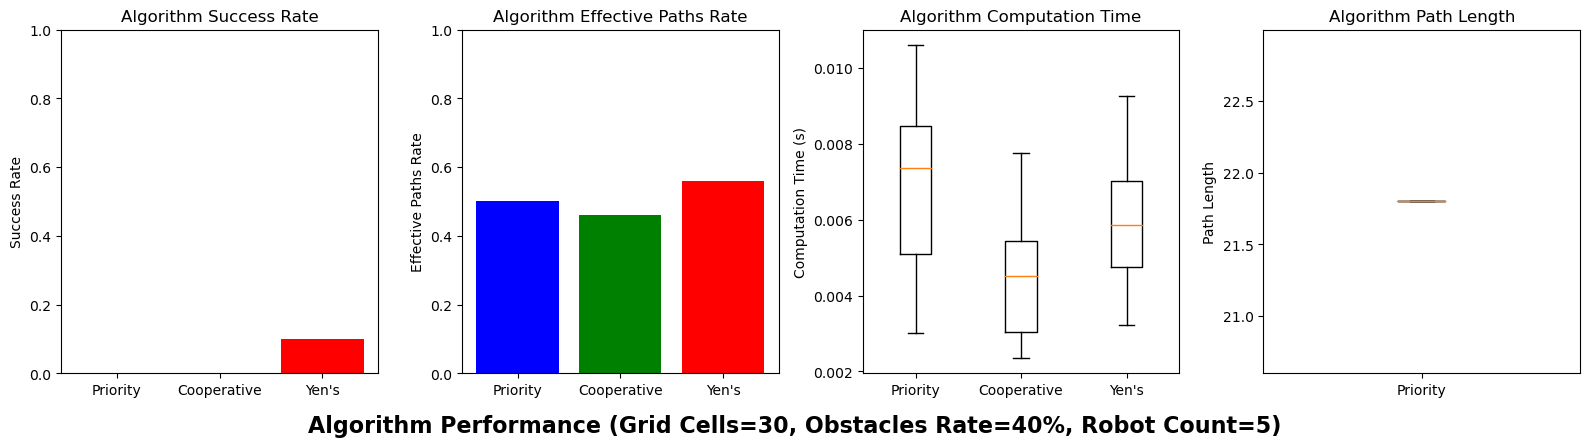

22.5
35.0
25.6
11.5
22.142857142857142
33.5
21.8
17.333333333333332
24.8
23.5
Success Rate: 0.1
Effective Path Rate: 0.5857142857142856
Average Computation Time: 0.010179829597473145
Meaningful Path Lengths: [22.142857142857142]
10.5
13.4
13.666666666666666
29.666666666666668
24.333333333333332
27.0
18.333333333333332
15.25
35.5
14.0
Success Rate: 0.0
Effective Path Rate: 0.4428571428571429
Average Computation Time: 0.0051666259765625
Meaningful Path Lengths: []
26.5
21.333333333333332
27.5
28.666666666666668
21.6
19.25
21.4
19.0
19.2
23.0
Success Rate: 0.0
Effective Path Rate: 0.6571428571428571
Average Computation Time: 0.00991353988647461
Meaningful Path Lengths: []


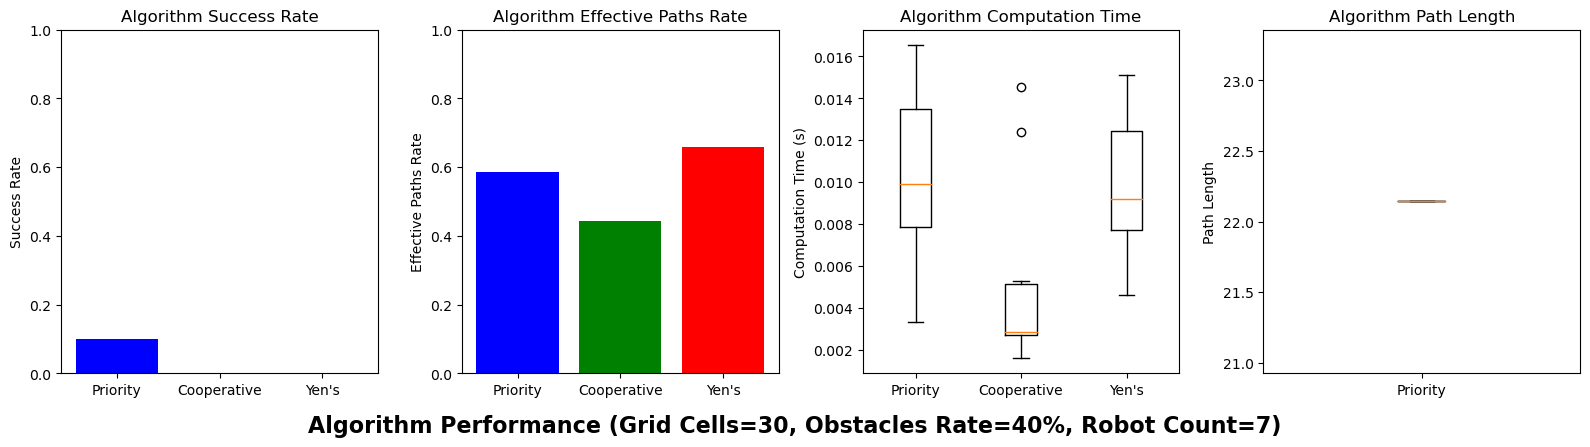

22.2
16.2
21.2
23.333333333333332
20.75
22.571428571428573
19.142857142857142
20.142857142857142
25.833333333333332
14.714285714285714
Success Rate: 0.0
Effective Path Rate: 0.6222222222222222
Average Computation Time: 0.011425089836120606
Meaningful Path Lengths: []
16.2
30.0
24.0
27.25
24.5
14.833333333333334
35.75
26.333333333333332
21.5
12.5
Success Rate: 0.0
Effective Path Rate: 0.36666666666666664
Average Computation Time: 0.009512519836425782
Meaningful Path Lengths: []
13.666666666666666
17.0
23.8
20.0
21.4
19.0
19.6
14.625
21.5
29.8
Success Rate: 0.0
Effective Path Rate: 0.5666666666666667
Average Computation Time: 0.01209118366241455
Meaningful Path Lengths: []


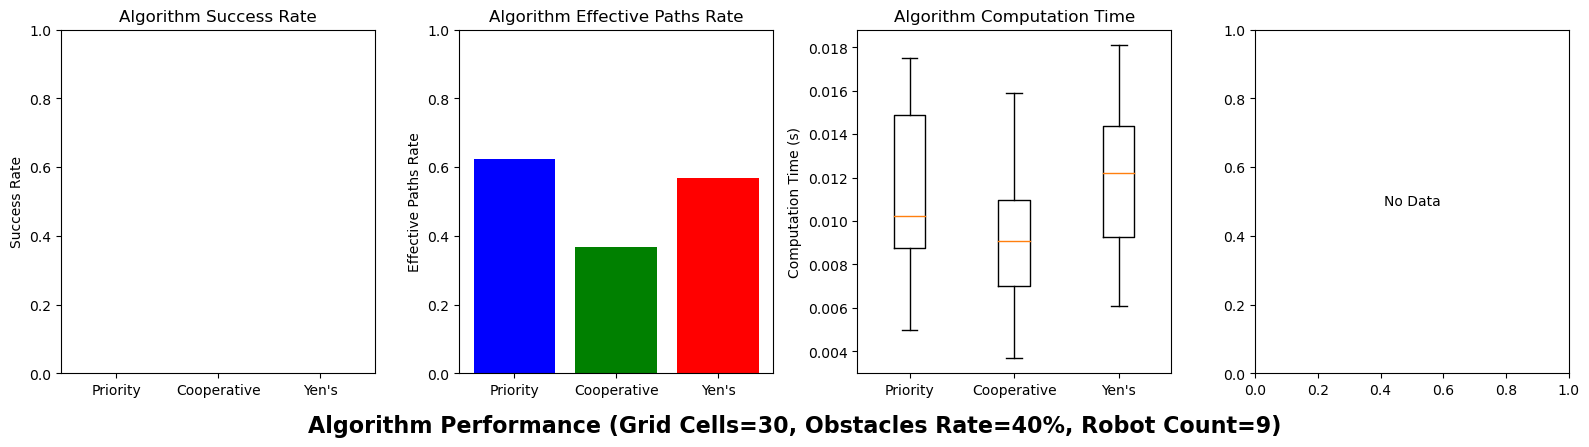

14.0
11.0
10.0
17.0
34.0
23.0
25.0
26.0
33.0
12.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0007066011428833007
Meaningful Path Lengths: [14.0, 11.0, 10.0, 17.0, 34.0, 23.0, 25.0, 26.0, 33.0, 12.0]
10.0
29.0
18.0
30.0
35.0
57.0
11.0
22.0
40.0
27.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0006337404251098633
Meaningful Path Lengths: [10.0, 29.0, 18.0, 30.0, 35.0, 57.0, 11.0, 22.0, 40.0, 27.0]
21.0
25.0
60.0
25.0
16.0
26.0
37.0
11.0
18.0
35.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0005326986312866211
Meaningful Path Lengths: [21.0, 25.0, 60.0, 25.0, 16.0, 26.0, 37.0, 11.0, 18.0, 35.0]


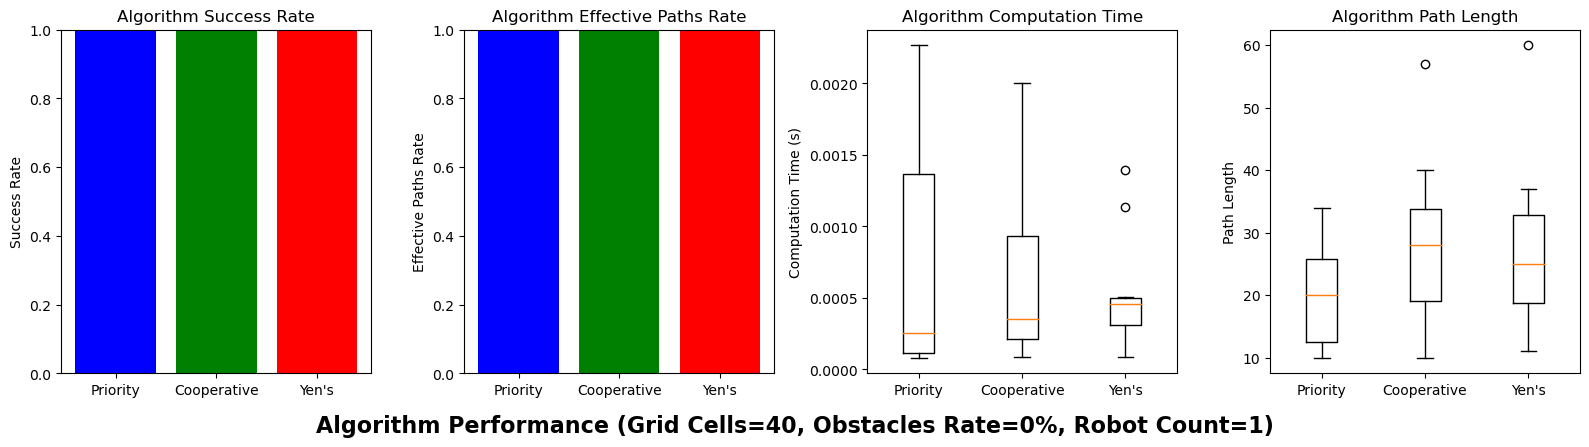

39.666666666666664
17.0
28.0
36.666666666666664
22.666666666666668
19.666666666666668
26.333333333333332
38.0
20.666666666666668
34.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.005238652229309082
Meaningful Path Lengths: [39.666666666666664, 17.0, 28.0, 36.666666666666664, 22.666666666666668, 19.666666666666668, 26.333333333333332, 38.0, 20.666666666666668, 34.0]
26.333333333333332
26.333333333333332
11.333333333333334
46.0
29.0
49.333333333333336
41.333333333333336
18.666666666666668
24.666666666666668
22.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.006276607513427734
Meaningful Path Lengths: [26.333333333333332, 26.333333333333332, 11.333333333333334, 46.0, 29.0, 49.333333333333336, 41.333333333333336, 18.666666666666668, 24.666666666666668, 22.0]
37.333333333333336
26.666666666666668
32.0
22.666666666666668
23.0
27.666666666666668
37.666666666666664
40.333333333333336
18.333333333333332
34.666666666666664
Success Rate: 1.0
Effe

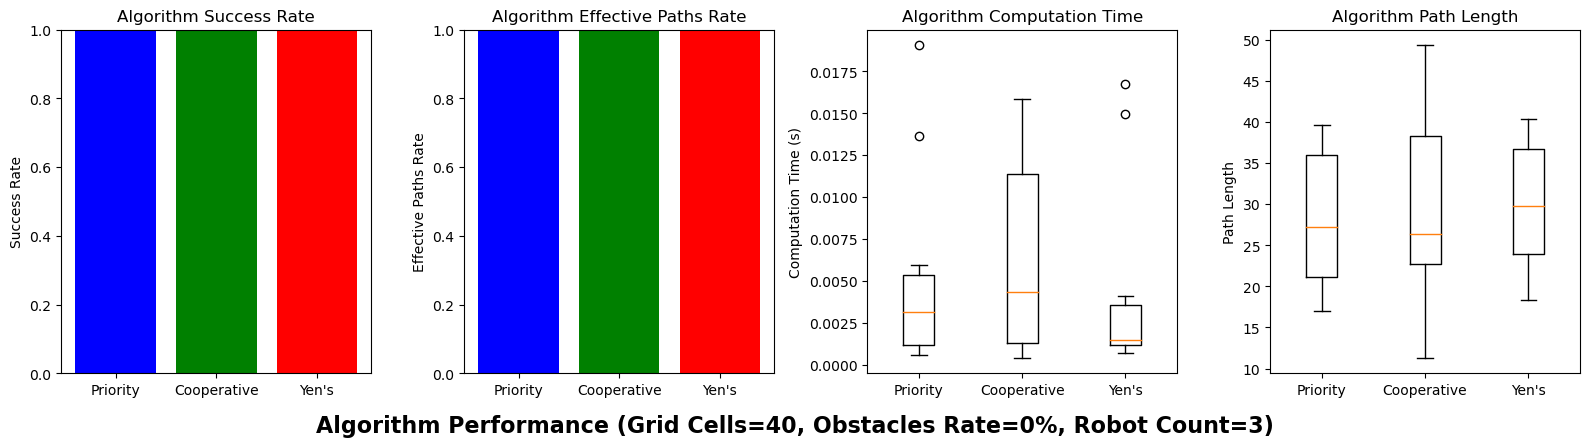

29.0
28.8
23.6
27.0
37.0
21.4
28.8
27.2
32.0
31.8
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.007963085174560547
Meaningful Path Lengths: [29.0, 28.8, 23.6, 27.0, 37.0, 21.4, 28.8, 27.2, 32.0, 31.8]
18.2
47.0
41.75
30.0
38.0
41.2
46.75
17.6
33.2
32.6
Success Rate: 0.7
Effective Path Rate: 0.9400000000000001
Average Computation Time: 0.011020994186401368
Meaningful Path Lengths: [18.2, 30.0, 38.0, 41.2, 17.6, 33.2, 32.6]
28.4
27.0
23.4
29.2
22.0
28.6
26.6
23.2
29.8
32.4
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.007822942733764649
Meaningful Path Lengths: [28.4, 27.0, 23.4, 29.2, 22.0, 28.6, 26.6, 23.2, 29.8, 32.4]


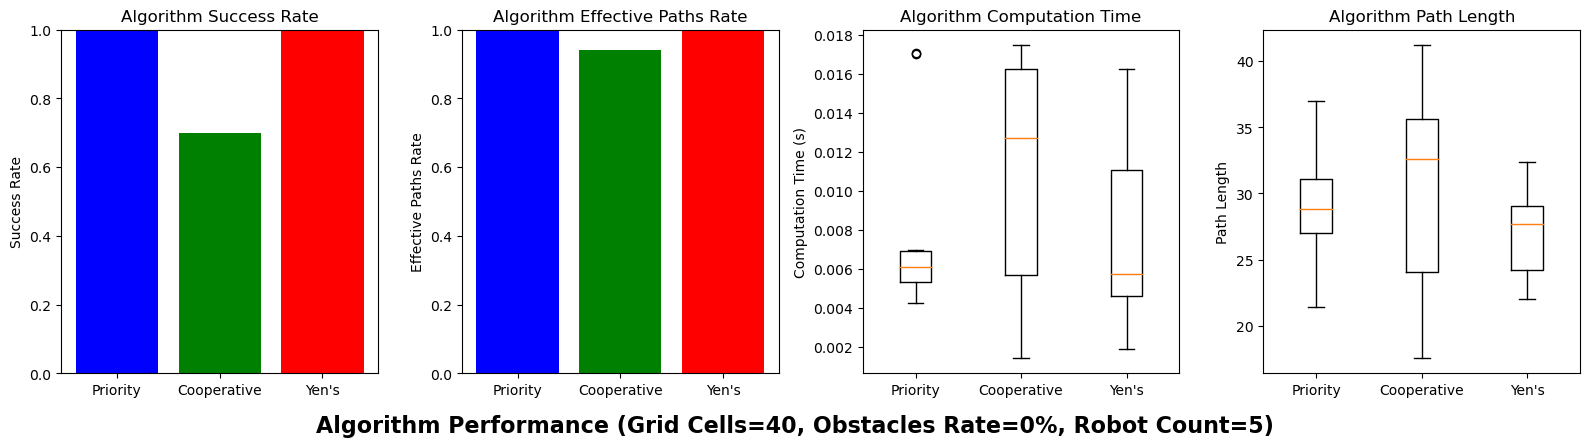

19.571428571428573
25.571428571428573
32.42857142857143
24.571428571428573
21.714285714285715
31.714285714285715
25.571428571428573
35.142857142857146
32.714285714285715
24.285714285714285
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.011762070655822753
Meaningful Path Lengths: [19.571428571428573, 25.571428571428573, 32.42857142857143, 24.571428571428573, 21.714285714285715, 31.714285714285715, 25.571428571428573, 35.142857142857146, 32.714285714285715, 24.285714285714285]
23.714285714285715
20.857142857142858
40.57142857142857
56.166666666666664
50.57142857142857
32.857142857142854
29.714285714285715
31.428571428571427
26.571428571428573
36.285714285714285
Success Rate: 0.9
Effective Path Rate: 0.9857142857142858
Average Computation Time: 0.02533867359161377
Meaningful Path Lengths: [23.714285714285715, 20.857142857142858, 40.57142857142857, 50.57142857142857, 32.857142857142854, 29.714285714285715, 31.428571428571427, 26.571428571428573, 36.285714285714285]


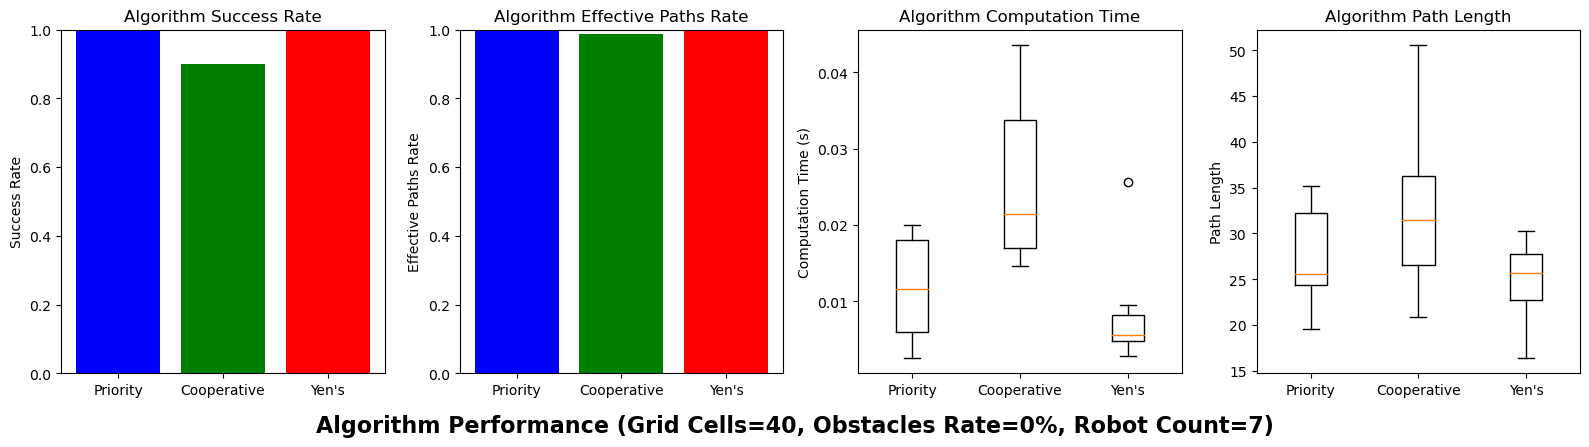

30.11111111111111
20.333333333333332
32.0
26.666666666666668
22.555555555555557
30.77777777777778
30.11111111111111
29.22222222222222
28.444444444444443
22.666666666666668
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.010075068473815918
Meaningful Path Lengths: [30.11111111111111, 20.333333333333332, 32.0, 26.666666666666668, 22.555555555555557, 30.77777777777778, 30.11111111111111, 29.22222222222222, 28.444444444444443, 22.666666666666668]
34.111111111111114
17.77777777777778
32.666666666666664
28.666666666666668
30.375
28.75
31.444444444444443
29.0
24.2
27.77777777777778
Success Rate: 0.6
Effective Path Rate: 0.8999999999999999
Average Computation Time: 0.026142525672912597
Meaningful Path Lengths: [34.111111111111114, 17.77777777777778, 32.666666666666664, 28.666666666666668, 31.444444444444443, 27.77777777777778]
25.11111111111111
23.333333333333332
22.333333333333332
22.0
21.0
27.77777777777778
30.77777777777778
23.22222222222222
24.444444444444443
28.5555

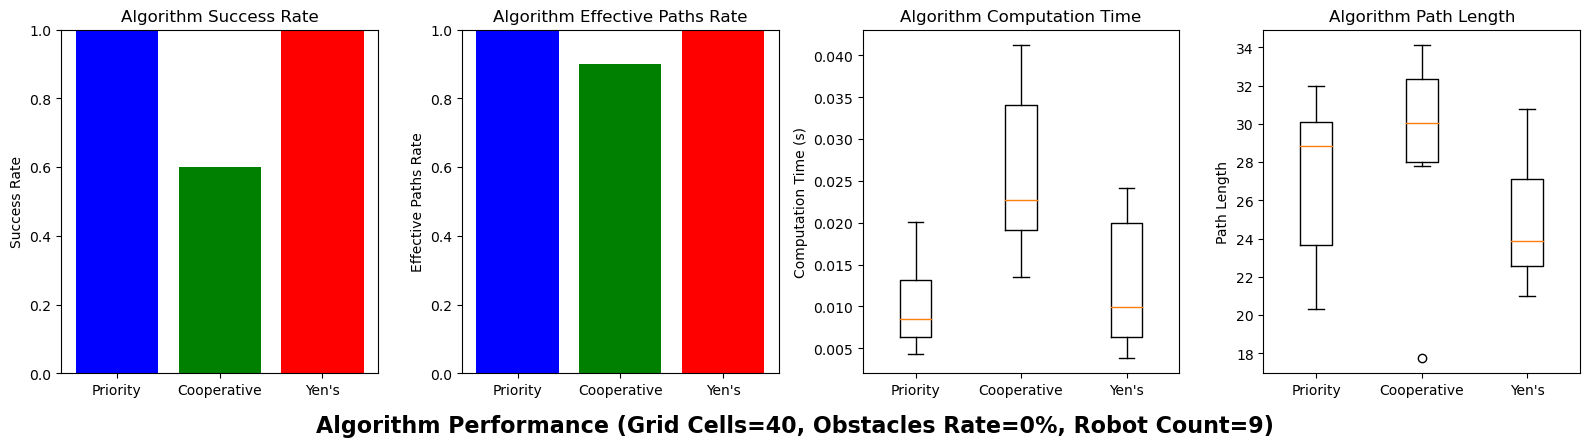

39.0
29.0
32.0
43.0
12.0
64.0
24.0
37.0
39.0
34.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.000813746452331543
Meaningful Path Lengths: [39.0, 29.0, 32.0, 43.0, 12.0, 64.0, 24.0, 37.0, 39.0, 34.0]
26.0
26.0
32.0
11.0
16.0
30.0
38.0
24.0
26.0
24.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0005775690078735352
Meaningful Path Lengths: [26.0, 26.0, 32.0, 11.0, 16.0, 30.0, 38.0, 24.0, 26.0, 24.0]
22.0
25.0
25.0
36.0
50.0
11.0
50.0
19.0
21.0
44.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0015833377838134766
Meaningful Path Lengths: [22.0, 25.0, 25.0, 36.0, 50.0, 11.0, 50.0, 19.0, 21.0, 44.0]


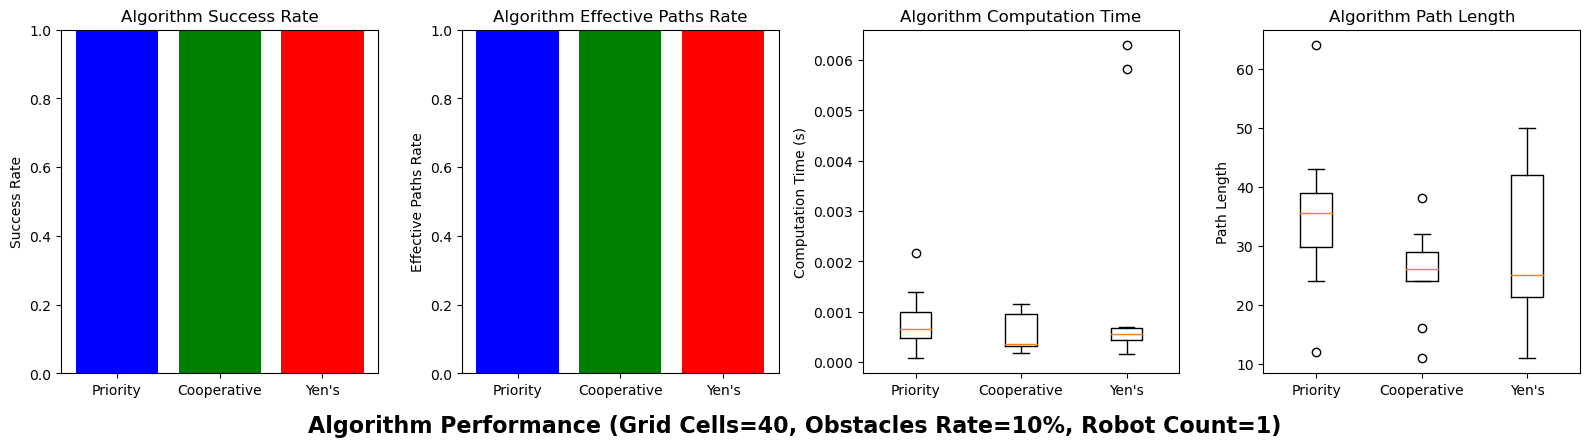

36.333333333333336
28.0
22.333333333333332
33.666666666666664
37.0
20.0
28.333333333333332
17.0
23.0
38.0
Success Rate: 0.9
Effective Path Rate: 0.9666666666666667
Average Computation Time: 0.003971099853515625
Meaningful Path Lengths: [36.333333333333336, 28.0, 22.333333333333332, 33.666666666666664, 37.0, 20.0, 28.333333333333332, 17.0, 38.0]
18.0
29.0
27.333333333333332
22.5
25.666666666666668
29.0
41.0
12.5
17.0
16.333333333333332
Success Rate: 0.5
Effective Path Rate: 0.7666666666666666
Average Computation Time: 0.01157519817352295
Meaningful Path Lengths: [27.333333333333332, 25.666666666666668, 29.0, 41.0, 16.333333333333332]
27.0
24.0
27.0
35.0
23.333333333333332
30.0
31.666666666666668
11.666666666666666
41.0
37.333333333333336
Success Rate: 0.8
Effective Path Rate: 0.9333333333333332
Average Computation Time: 0.0061859130859375
Meaningful Path Lengths: [24.0, 27.0, 35.0, 23.333333333333332, 31.666666666666668, 11.666666666666666, 41.0, 37.333333333333336]


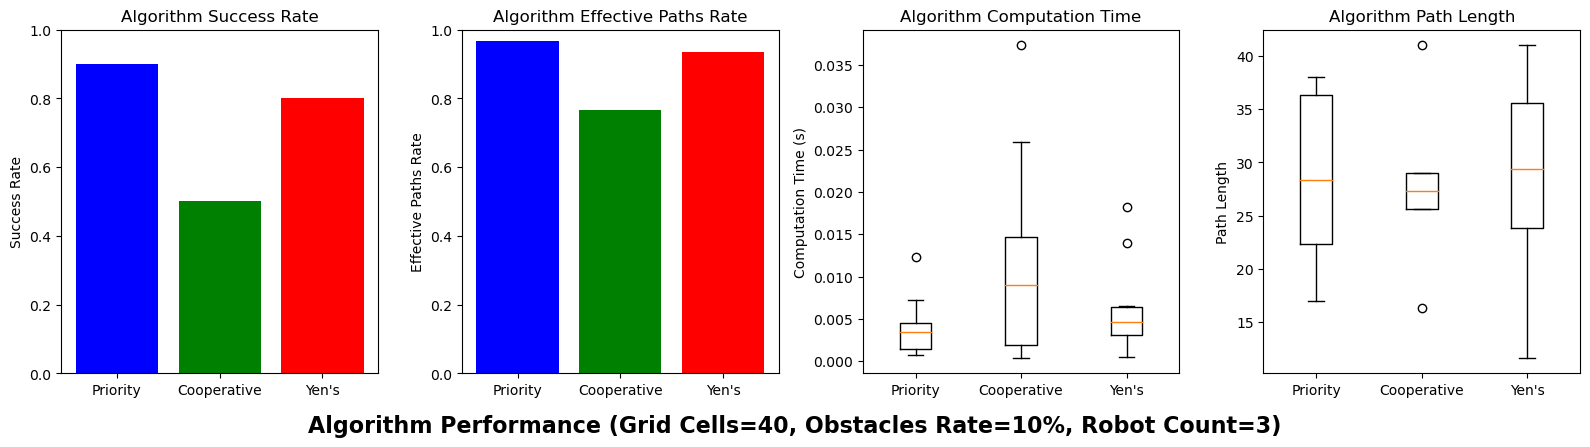

29.0
28.666666666666668
29.2
27.0
25.0
35.0
28.0
29.4
34.8
22.0
Success Rate: 0.6
Effective Path Rate: 0.8800000000000001
Average Computation Time: 0.014304614067077637
Meaningful Path Lengths: [29.0, 29.2, 25.0, 28.0, 29.4, 34.8]
26.0
24.8
27.0
37.0
48.6
34.2
29.4
27.4
31.0
22.666666666666668
Success Rate: 0.7
Effective Path Rate: 0.9199999999999999
Average Computation Time: 0.011439156532287598
Meaningful Path Lengths: [26.0, 24.8, 48.6, 34.2, 29.4, 27.4, 31.0]
18.8
28.666666666666668
29.2
32.5
29.6
26.4
21.0
25.5
33.0
23.8
Success Rate: 0.6
Effective Path Rate: 0.9
Average Computation Time: 0.010130023956298828
Meaningful Path Lengths: [18.8, 29.2, 29.6, 26.4, 33.0, 23.8]


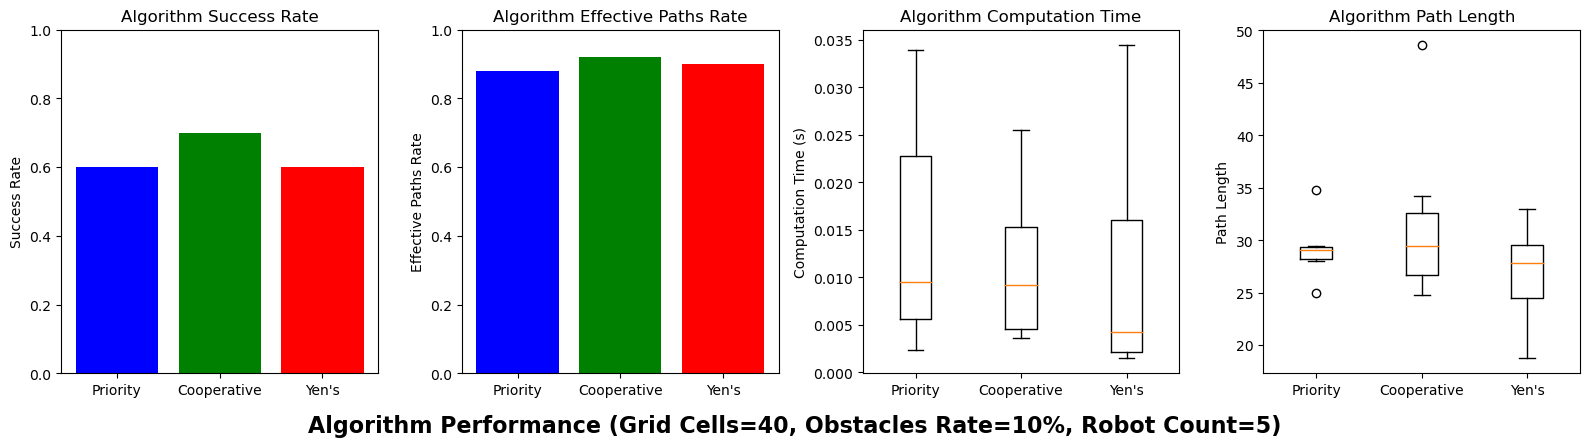

23.833333333333332
39.42857142857143
30.166666666666668
33.833333333333336
22.714285714285715
32.57142857142857
25.333333333333332
29.833333333333332
24.666666666666668
19.5
Success Rate: 0.3
Effective Path Rate: 0.8714285714285713
Average Computation Time: 0.02061278820037842
Meaningful Path Lengths: [39.42857142857143, 22.714285714285715, 32.57142857142857]
25.166666666666668
38.0
25.142857142857142
33.42857142857143
38.5
33.714285714285715
24.6
15.4
45.857142857142854
43.0
Success Rate: 0.4
Effective Path Rate: 0.8857142857142858
Average Computation Time: 0.02320852279663086
Meaningful Path Lengths: [25.142857142857142, 33.42857142857143, 33.714285714285715, 45.857142857142854]
25.142857142857142
22.142857142857142
27.2
26.428571428571427
24.666666666666668
28.285714285714285
29.285714285714285
22.0
23.142857142857142
21.428571428571427
Success Rate: 0.8
Effective Path Rate: 0.9571428571428572
Average Computation Time: 0.011502790451049804
Meaningful Path Lengths: [25.14285714285714

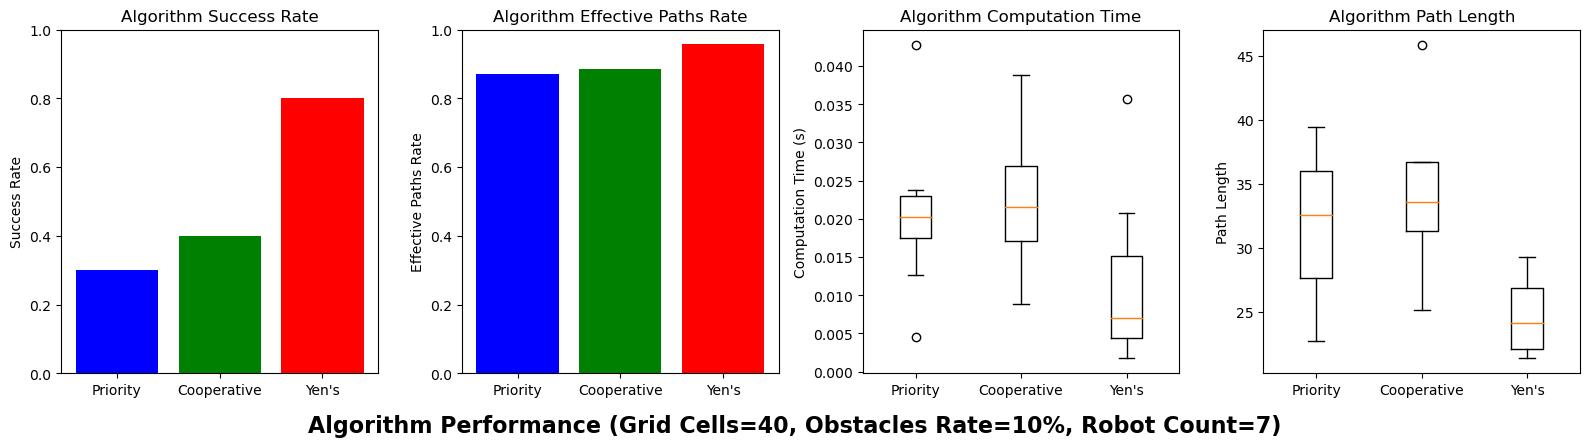

23.444444444444443
28.0
31.142857142857142
22.75
23.11111111111111
22.25
24.444444444444443
22.25
23.77777777777778
29.444444444444443
Success Rate: 0.5
Effective Path Rate: 0.911111111111111
Average Computation Time: 0.020409321784973143
Meaningful Path Lengths: [23.444444444444443, 23.11111111111111, 24.444444444444443, 23.77777777777778, 29.444444444444443]
24.125
34.857142857142854
39.5
36.44444444444444
39.833333333333336
30.444444444444443
24.0
25.857142857142858
33.333333333333336
24.714285714285715
Success Rate: 0.2
Effective Path Rate: 0.8111111111111111
Average Computation Time: 0.030035758018493654
Meaningful Path Lengths: [36.44444444444444, 30.444444444444443]
23.5
22.22222222222222
28.142857142857142
27.714285714285715
29.875
22.77777777777778
27.11111111111111
24.444444444444443
40.2
27.555555555555557
Success Rate: 0.5
Effective Path Rate: 0.8888888888888888
Average Computation Time: 0.02769312858581543
Meaningful Path Lengths: [22.22222222222222, 22.77777777777778, 27.

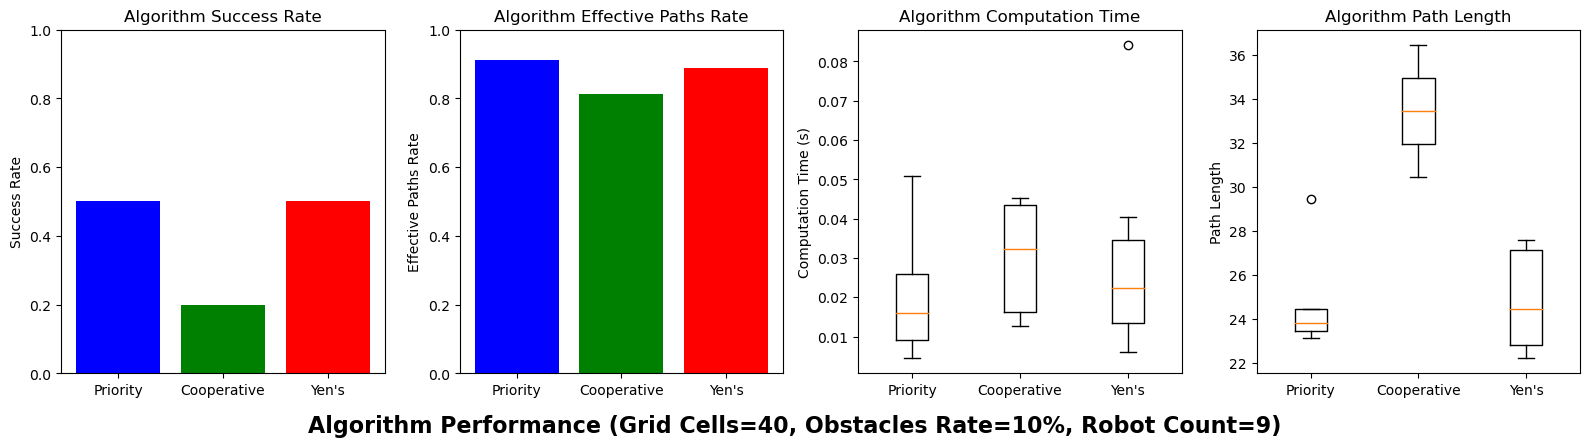

47.0
28.0
19.0
6.0
32.0
26.0
40.0
12.0
42.0
32.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0008672237396240235
Meaningful Path Lengths: [47.0, 28.0, 19.0, 6.0, 32.0, 26.0, 40.0, 12.0, 42.0, 32.0]
45.0
5.0
25.0
12.0
33.0
38.0
Success Rate: 0.6
Effective Path Rate: 0.6
Average Computation Time: 0.004833126068115234
Meaningful Path Lengths: [45.0, 5.0, 25.0, 12.0, 33.0, 38.0]
60.0
23.0
10.0
13.0
12.0
28.0
19.0
32.0
Success Rate: 0.8
Effective Path Rate: 0.8
Average Computation Time: 0.0030650854110717773
Meaningful Path Lengths: [60.0, 23.0, 10.0, 13.0, 12.0, 28.0, 19.0, 32.0]


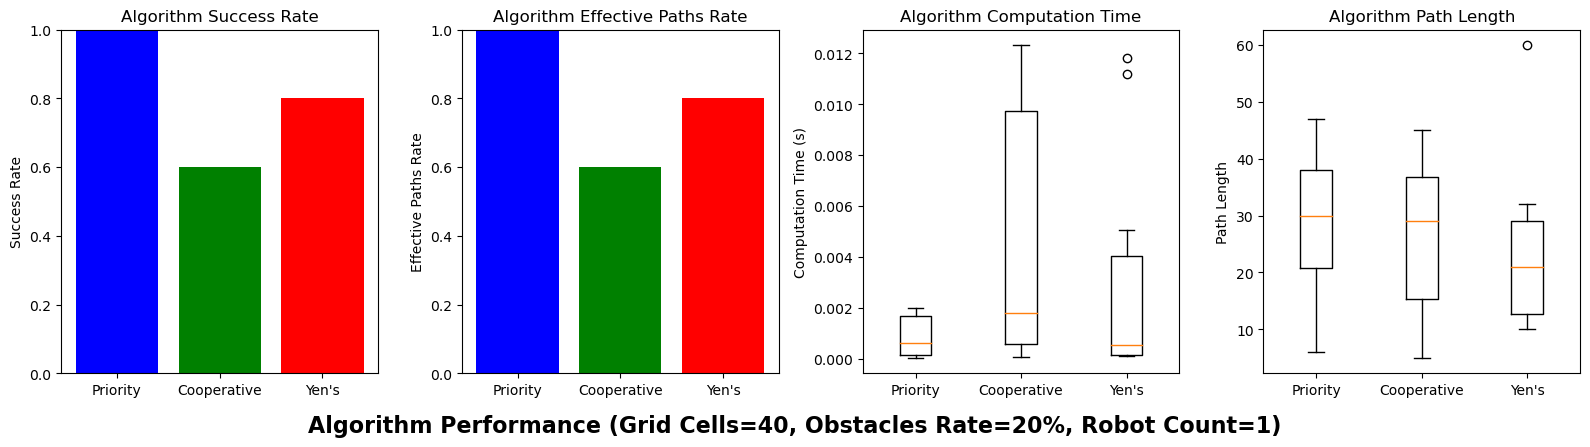

31.0
19.5
21.0
24.0
31.666666666666668
41.0
35.666666666666664
38.666666666666664
44.0
28.666666666666668
Success Rate: 0.6
Effective Path Rate: 0.7999999999999999
Average Computation Time: 0.00906517505645752
Meaningful Path Lengths: [21.0, 24.0, 31.666666666666668, 35.666666666666664, 38.666666666666664, 28.666666666666668]
26.0
28.0
35.333333333333336
31.0
40.0
24.0
30.666666666666668
24.333333333333332
34.0
37.5
Success Rate: 0.4
Effective Path Rate: 0.7666666666666666
Average Computation Time: 0.009354543685913087
Meaningful Path Lengths: [35.333333333333336, 24.0, 30.666666666666668, 24.333333333333332]
26.666666666666668
32.5
22.0
34.333333333333336
50.5
24.333333333333332
19.666666666666668
43.5
16.333333333333332
21.666666666666668
Success Rate: 0.7
Effective Path Rate: 0.9
Average Computation Time: 0.006145286560058594
Meaningful Path Lengths: [26.666666666666668, 22.0, 34.333333333333336, 24.333333333333332, 19.666666666666668, 16.333333333333332, 21.666666666666668]


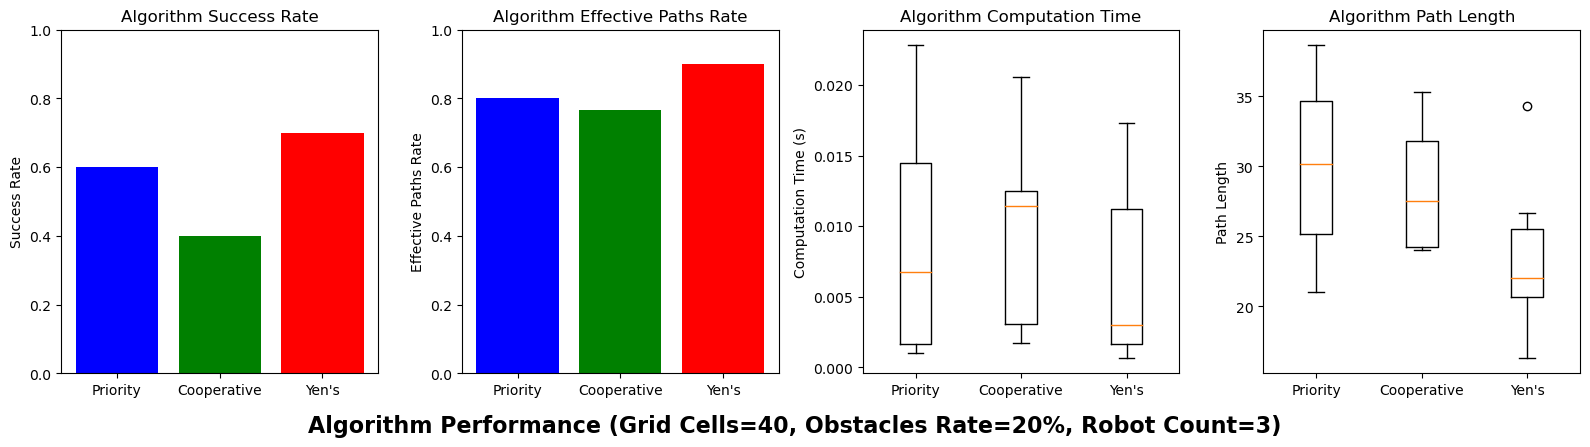

29.6
20.8
25.8
23.8
38.5
33.8
19.666666666666668
31.333333333333332
27.333333333333332
29.333333333333332
Success Rate: 0.5
Effective Path Rate: 0.82
Average Computation Time: 0.014039182662963867
Meaningful Path Lengths: [29.6, 20.8, 25.8, 23.8, 33.8]
23.6
28.0
36.0
31.5
28.75
39.0
22.75
33.4
38.75
37.333333333333336
Success Rate: 0.2
Effective Path Rate: 0.8
Average Computation Time: 0.014324474334716796
Meaningful Path Lengths: [23.6, 33.4]
22.5
28.6
26.6
21.0
29.0
35.0
29.2
24.25
27.2
31.2
Success Rate: 0.5
Effective Path Rate: 0.9
Average Computation Time: 0.008827495574951171
Meaningful Path Lengths: [28.6, 26.6, 29.2, 27.2, 31.2]


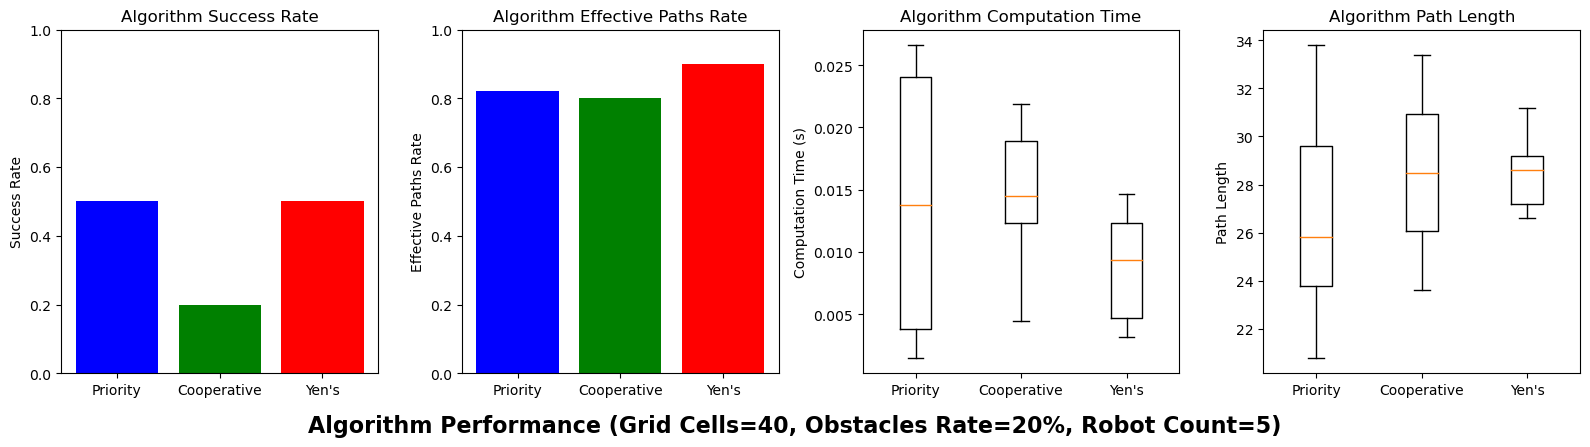

33.0
19.6
24.142857142857142
28.8
30.428571428571427
26.666666666666668
20.333333333333332
23.142857142857142
27.428571428571427
27.833333333333332
Success Rate: 0.4
Effective Path Rate: 0.8714285714285713
Average Computation Time: 0.015840864181518553
Meaningful Path Lengths: [24.142857142857142, 30.428571428571427, 23.142857142857142, 27.428571428571427]
36.0
29.333333333333332
59.5
24.4
40.25
39.0
40.5
38.5
53.0
40.833333333333336
Success Rate: 0.0
Effective Path Rate: 0.5714285714285714
Average Computation Time: 0.026479887962341308
Meaningful Path Lengths: []
25.142857142857142
13.666666666666666
33.0
23.285714285714285
24.6
26.0
26.0
28.0
30.666666666666668
25.714285714285715
Success Rate: 0.3
Effective Path Rate: 0.8142857142857143
Average Computation Time: 0.01991603374481201
Meaningful Path Lengths: [25.142857142857142, 23.285714285714285, 25.714285714285715]


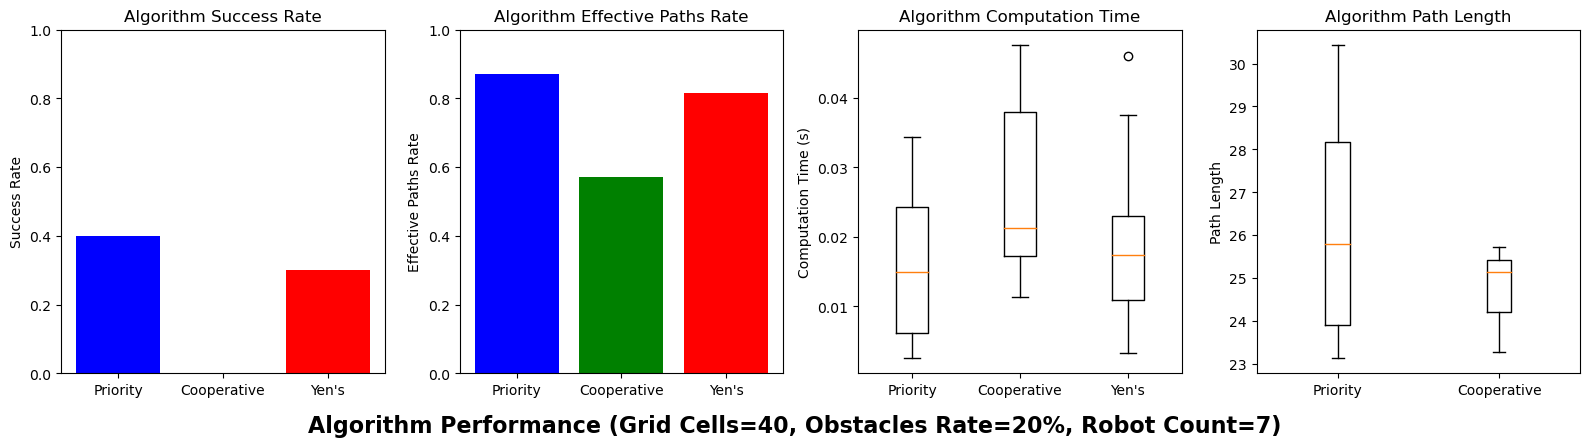

24.444444444444443
28.77777777777778
26.25
29.0
24.428571428571427
24.6
26.5
20.375
27.285714285714285
27.0
Success Rate: 0.2
Effective Path Rate: 0.8222222222222223
Average Computation Time: 0.026183533668518066
Meaningful Path Lengths: [24.444444444444443, 28.77777777777778]
31.285714285714285
41.5
32.8
24.666666666666668
28.666666666666668
38.5
26.6
31.142857142857142
20.75
26.4
Success Rate: 0.0
Effective Path Rate: 0.6555555555555556
Average Computation Time: 0.02371547222137451
Meaningful Path Lengths: []
34.0
29.571428571428573
16.6
18.11111111111111
19.5
22.77777777777778
23.22222222222222
24.88888888888889
19.875
26.571428571428573
Success Rate: 0.4
Effective Path Rate: 0.8444444444444444
Average Computation Time: 0.022220420837402343
Meaningful Path Lengths: [18.11111111111111, 22.77777777777778, 23.22222222222222, 24.88888888888889]


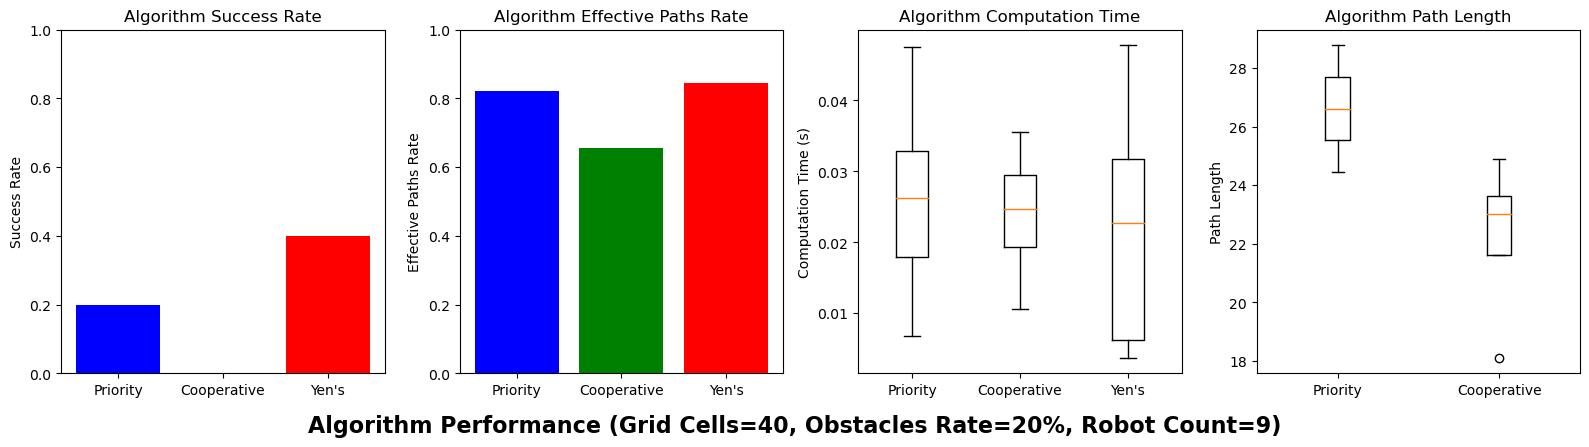

48.0
27.0
47.0
43.0
23.0
43.0
68.0
Success Rate: 0.7
Effective Path Rate: 0.7
Average Computation Time: 0.010004782676696777
Meaningful Path Lengths: [48.0, 27.0, 47.0, 43.0, 23.0, 43.0, 68.0]
17.0
30.0
44.0
9.0
47.0
14.0
2.0
39.0
25.0
Success Rate: 0.9
Effective Path Rate: 0.9
Average Computation Time: 0.0015755653381347655
Meaningful Path Lengths: [17.0, 30.0, 44.0, 9.0, 47.0, 14.0, 2.0, 39.0, 25.0]
62.0
23.0
30.0
15.0
43.0
33.0
39.0
Success Rate: 0.7
Effective Path Rate: 0.7
Average Computation Time: 0.002679777145385742
Meaningful Path Lengths: [62.0, 23.0, 30.0, 15.0, 43.0, 33.0, 39.0]


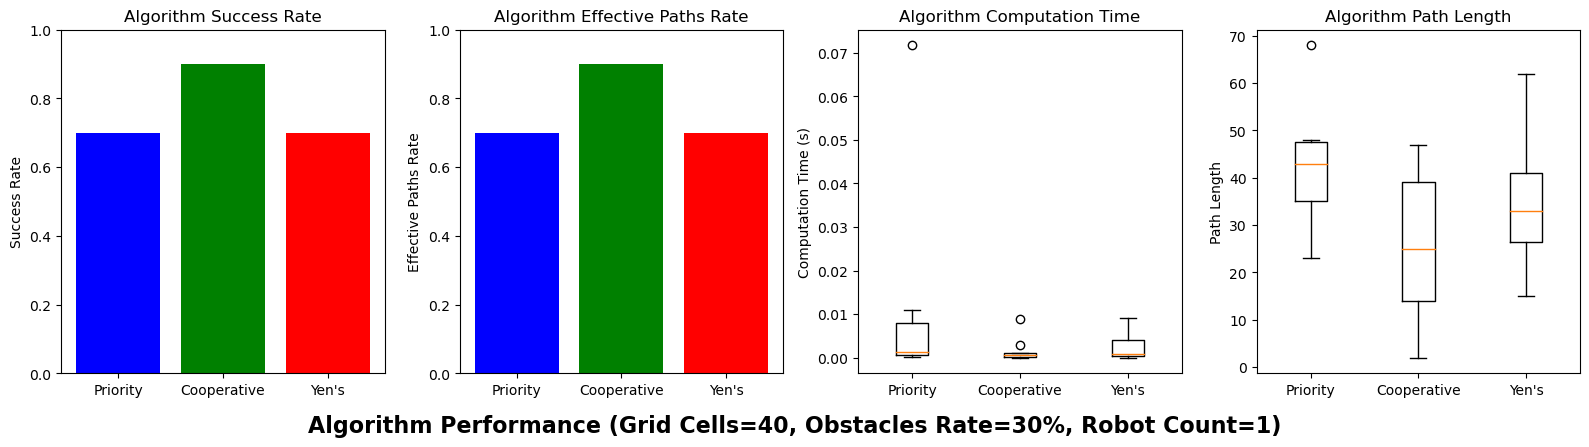

35.5
15.0
26.5
33.0
27.333333333333332
28.0
19.5
22.0
28.0
32.5
Success Rate: 0.3
Effective Path Rate: 0.6666666666666666
Average Computation Time: 0.009036064147949219
Meaningful Path Lengths: [33.0, 27.333333333333332, 28.0]
41.5
28.0
12.5
33.0
15.666666666666666
52.5
35.0
28.333333333333332
Success Rate: 0.3
Effective Path Rate: 0.6
Average Computation Time: 0.011088299751281738
Meaningful Path Lengths: [33.0, 15.666666666666666, 28.333333333333332]
40.5
18.0
15.0
28.5
41.0
29.0
34.5
43.666666666666664
38.5
23.0
Success Rate: 0.2
Effective Path Rate: 0.7000000000000001
Average Computation Time: 0.00995790958404541
Meaningful Path Lengths: [41.0, 43.666666666666664]


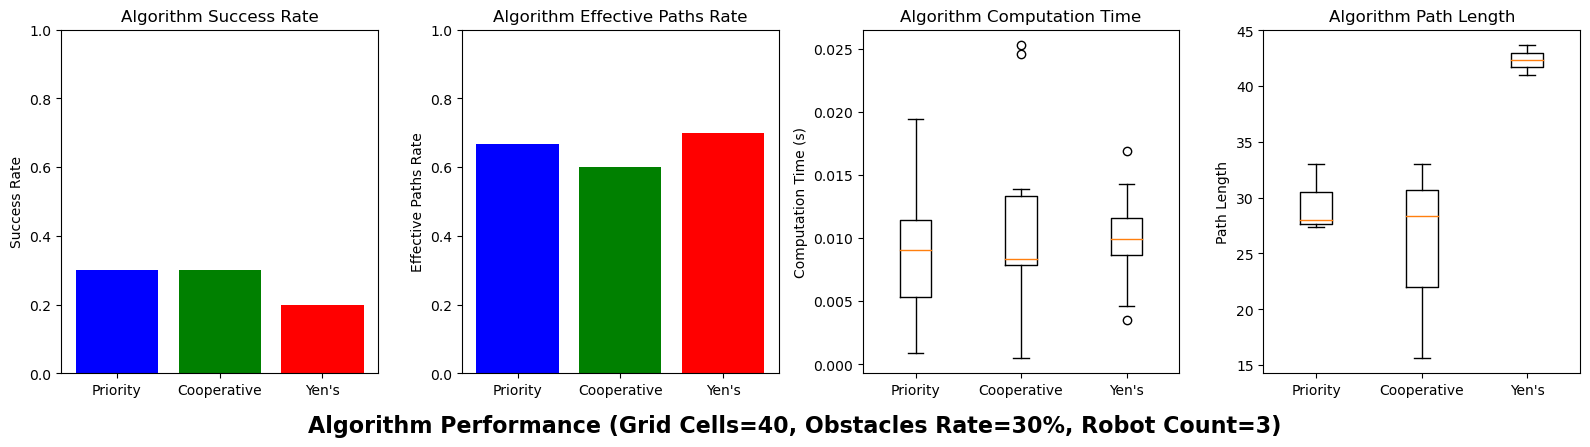

27.0
49.0
30.5
46.5
25.333333333333332
45.0
27.0
20.6
34.0
16.0
Success Rate: 0.1
Effective Path Rate: 0.6
Average Computation Time: 0.017180991172790528
Meaningful Path Lengths: [20.6]
32.5
19.5
26.333333333333332
44.666666666666664
37.0
24.333333333333332
27.333333333333332
20.5
29.333333333333332
30.0
Success Rate: 0.1
Effective Path Rate: 0.6799999999999999
Average Computation Time: 0.011626100540161133
Meaningful Path Lengths: [30.0]
22.75
20.6
16.25
30.0
17.333333333333332
22.25
17.25
20.5
29.5
28.666666666666668
Success Rate: 0.1
Effective Path Rate: 0.78
Average Computation Time: 0.012931013107299804
Meaningful Path Lengths: [20.6]


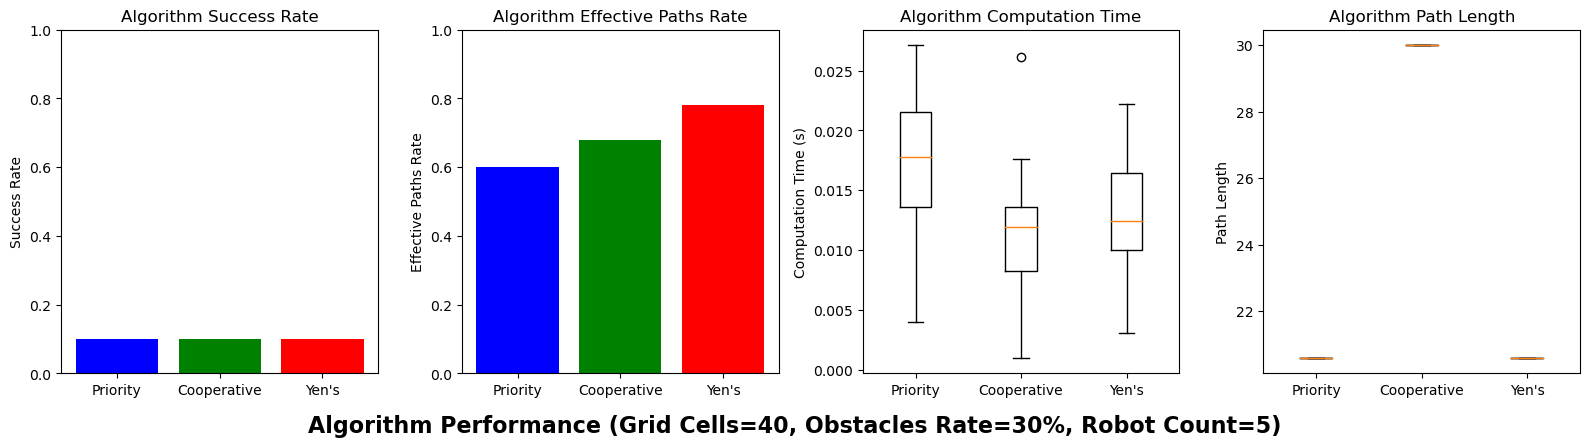

27.0
22.25
19.666666666666668
33.5
24.0
16.75
15.333333333333334
30.857142857142858
14.75
29.0
Success Rate: 0.1
Effective Path Rate: 0.6
Average Computation Time: 0.026866674423217773
Meaningful Path Lengths: [30.857142857142858]
21.25
30.8
26.25
46.0
26.0
25.0
20.0
48.333333333333336
33.4
50.0
Success Rate: 0.0
Effective Path Rate: 0.5428571428571428
Average Computation Time: 0.01788921356201172
Meaningful Path Lengths: []
21.0
25.8
30.833333333333332
29.0
25.0
34.25
25.4
24.166666666666668
26.5
16.166666666666668
Success Rate: 0.0
Effective Path Rate: 0.7142857142857143
Average Computation Time: 0.01914994716644287
Meaningful Path Lengths: []


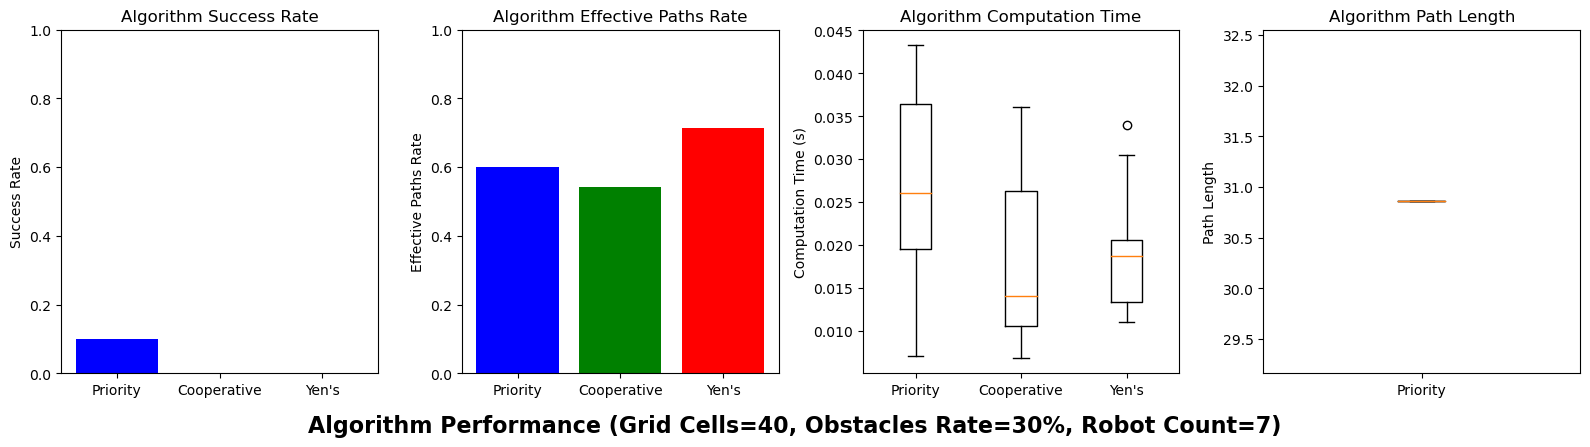

28.75
17.571428571428573
29.857142857142858
25.555555555555557
20.5
24.0
25.285714285714285
24.714285714285715
28.833333333333332
31.6
Success Rate: 0.1
Effective Path Rate: 0.7333333333333333
Average Computation Time: 0.025065135955810548
Meaningful Path Lengths: [25.555555555555557]
33.4
37.5
37.0
31.5
34.166666666666664
21.4
39.25
33.5
23.833333333333332
41.8
Success Rate: 0.0
Effective Path Rate: 0.5666666666666667
Average Computation Time: 0.020421695709228516
Meaningful Path Lengths: []
24.666666666666668
22.0
29.75
24.75
31.0
27.857142857142858
23.428571428571427
29.375
20.0
24.666666666666668
Success Rate: 0.0
Effective Path Rate: 0.6888888888888889
Average Computation Time: 0.027910232543945312
Meaningful Path Lengths: []


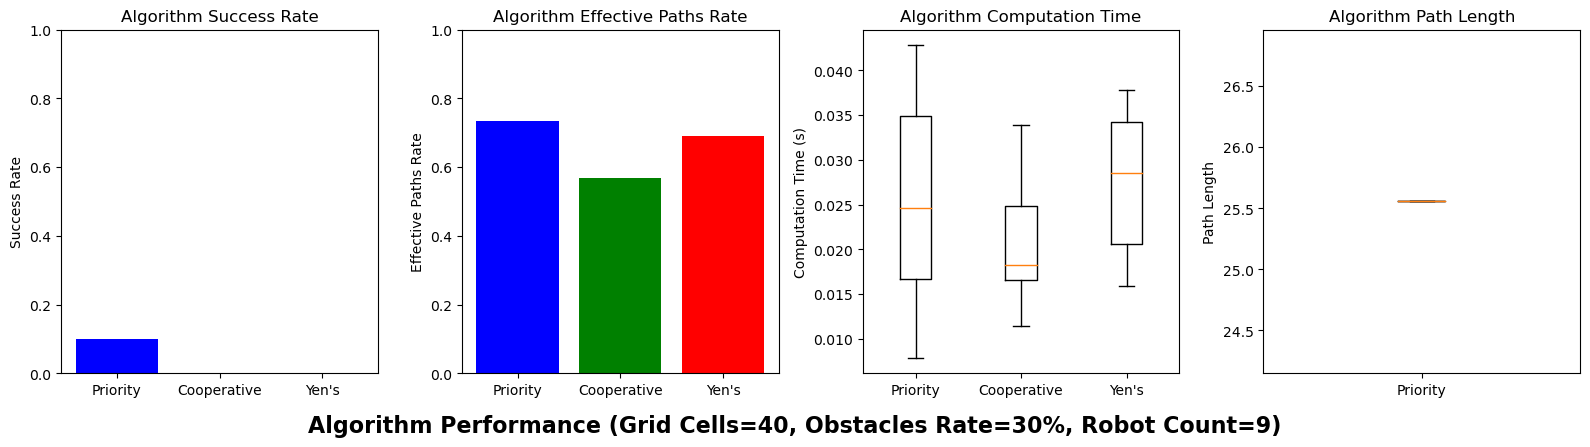

33.0
41.0
Success Rate: 0.2
Effective Path Rate: 0.2
Average Computation Time: 0.0053222417831420895
Meaningful Path Lengths: [33.0, 41.0]
42.0
18.0
8.0
74.0
34.0
68.0
Success Rate: 0.6
Effective Path Rate: 0.6
Average Computation Time: 0.0032024383544921875
Meaningful Path Lengths: [42.0, 18.0, 8.0, 74.0, 34.0, 68.0]
26.0
32.0
69.0
13.0
48.0
7.0
Success Rate: 0.6
Effective Path Rate: 0.6
Average Computation Time: 0.002537441253662109
Meaningful Path Lengths: [26.0, 32.0, 69.0, 13.0, 48.0, 7.0]


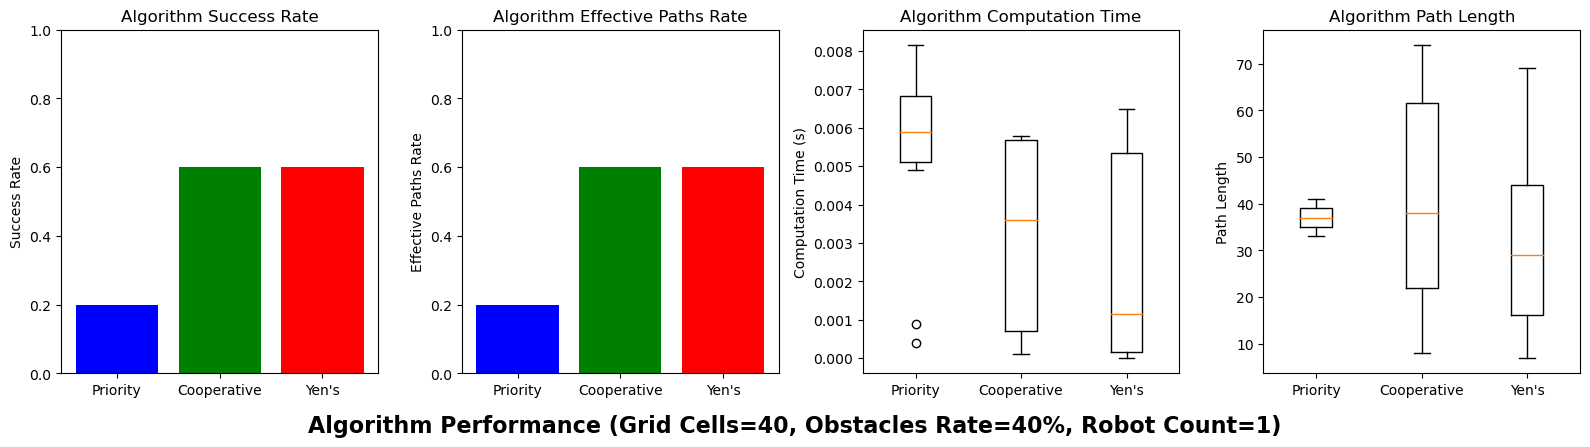

18.0
13.0
34.0
38.0
50.666666666666664
30.5
22.0
13.0
45.5
Success Rate: 0.1
Effective Path Rate: 0.43333333333333335
Average Computation Time: 0.011312413215637206
Meaningful Path Lengths: [50.666666666666664]
22.0
39.0
28.5
7.0
23.0
43.0
39.333333333333336
10.0
51.0
24.666666666666668
Success Rate: 0.2
Effective Path Rate: 0.6
Average Computation Time: 0.007165384292602539
Meaningful Path Lengths: [39.333333333333336, 24.666666666666668]
30.0
34.5
38.0
32.0
30.333333333333332
43.5
65.0
14.333333333333334
27.333333333333332
22.0
Success Rate: 0.3
Effective Path Rate: 0.6
Average Computation Time: 0.007611083984375
Meaningful Path Lengths: [30.333333333333332, 14.333333333333334, 27.333333333333332]


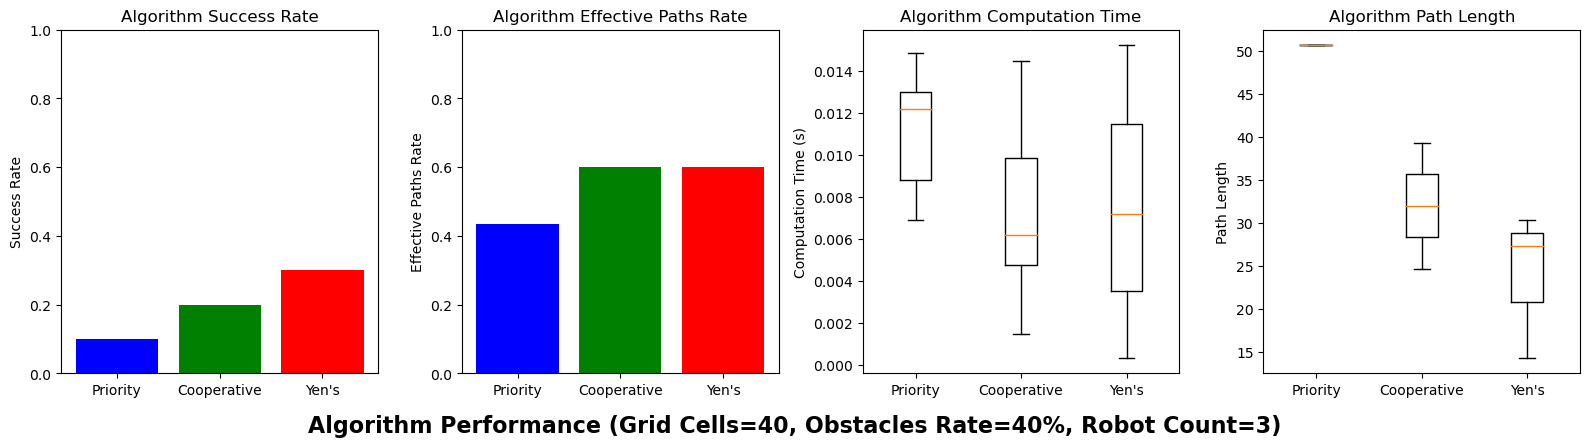

32.0
39.4
34.4
26.5
69.0
18.0
31.666666666666668
34.0
22.25
37.0
Success Rate: 0.4
Effective Path Rate: 0.74
Average Computation Time: 0.009180641174316407
Meaningful Path Lengths: [39.4, 34.4, 34.0, 37.0]
27.0
43.0
12.333333333333334
47.0
55.0
29.0
37.5
67.0
16.0
43.0
Success Rate: 0.0
Effective Path Rate: 0.4
Average Computation Time: 0.009883928298950195
Meaningful Path Lengths: []
31.0
36.0
23.8
38.6
25.0
22.0
29.0
40.333333333333336
29.2
23.0
Success Rate: 0.3
Effective Path Rate: 0.6799999999999999
Average Computation Time: 0.011646366119384766
Meaningful Path Lengths: [23.8, 38.6, 29.2]


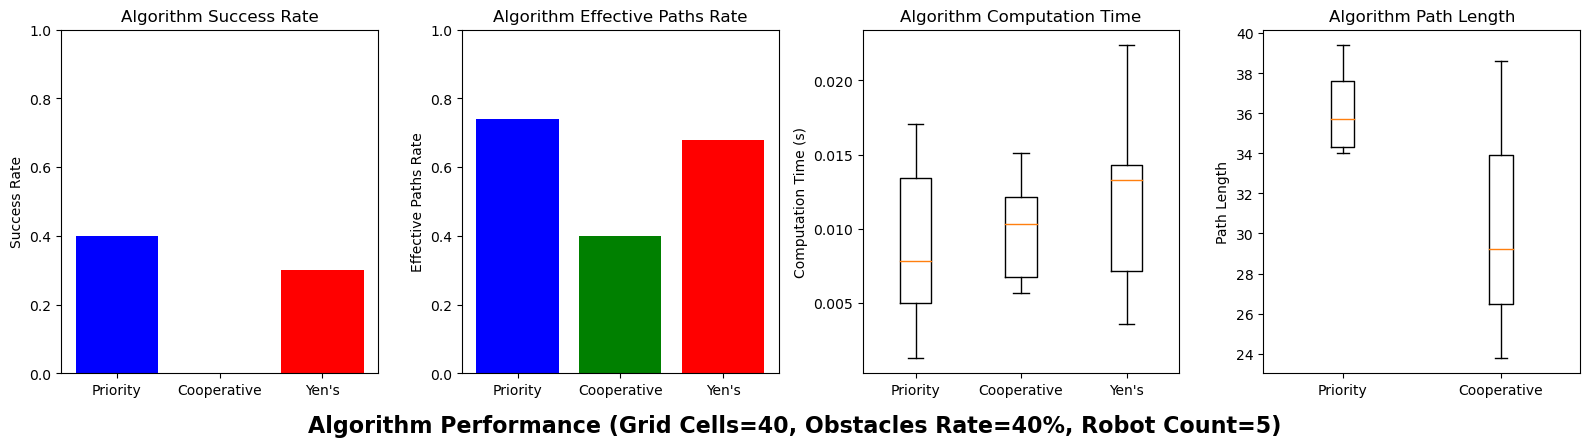

43.5
32.0
34.8
26.0
26.333333333333332
17.75
39.5
41.0
39.333333333333336
16.25
Success Rate: 0.0
Effective Path Rate: 0.6
Average Computation Time: 0.019234561920166017
Meaningful Path Lengths: []
57.0
55.0
18.75
31.75
51.0
35.5
31.5
38.0
32.666666666666664
24.5
Success Rate: 0.0
Effective Path Rate: 0.42857142857142855
Average Computation Time: 0.011884617805480956
Meaningful Path Lengths: []
27.333333333333332
30.75
42.666666666666664
21.8
28.666666666666668
39.0
32.0
25.0
37.0
16.25
Success Rate: 0.0
Effective Path Rate: 0.4857142857142857
Average Computation Time: 0.022356915473937988
Meaningful Path Lengths: []


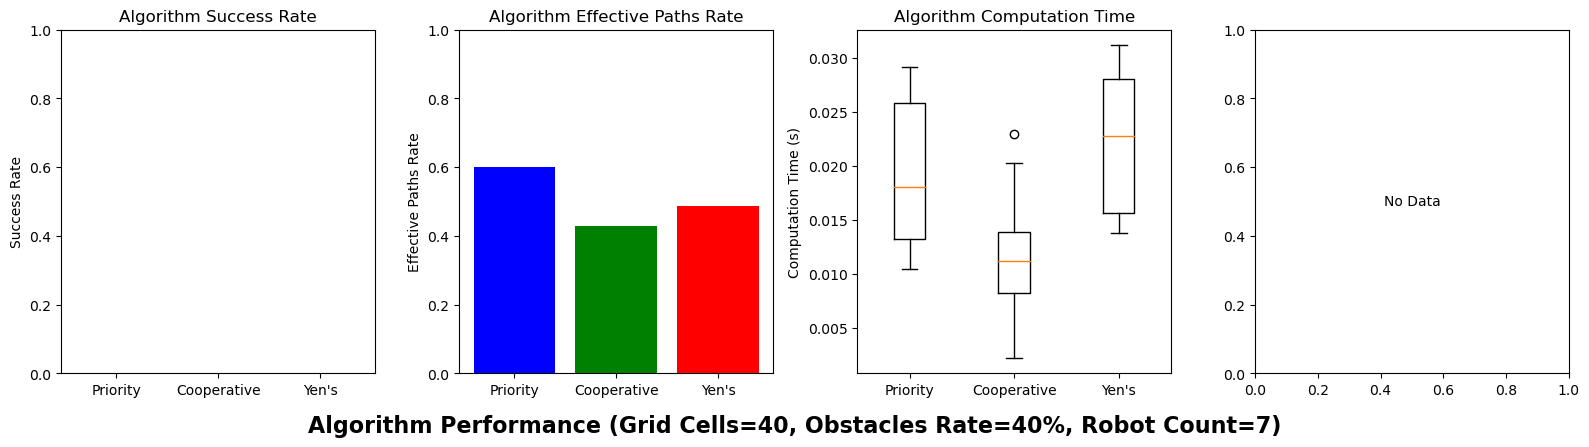

26.4
28.77777777777778
27.0
26.0
30.8
29.0
49.666666666666664
20.5
30.75
40.333333333333336
Success Rate: 0.1
Effective Path Rate: 0.5444444444444445
Average Computation Time: 0.02824075222015381
Meaningful Path Lengths: [28.77777777777778]
41.75
30.333333333333332
53.25
27.0
66.5
41.666666666666664
36.0
30.0
17.0
50.333333333333336
Success Rate: 0.0
Effective Path Rate: 0.36666666666666664
Average Computation Time: 0.016954994201660155
Meaningful Path Lengths: []
35.6
27.2
31.6
20.857142857142858
33.8
25.25
23.142857142857142
23.142857142857142
25.25
26.0
Success Rate: 0.0
Effective Path Rate: 0.6444444444444444
Average Computation Time: 0.023423218727111818
Meaningful Path Lengths: []


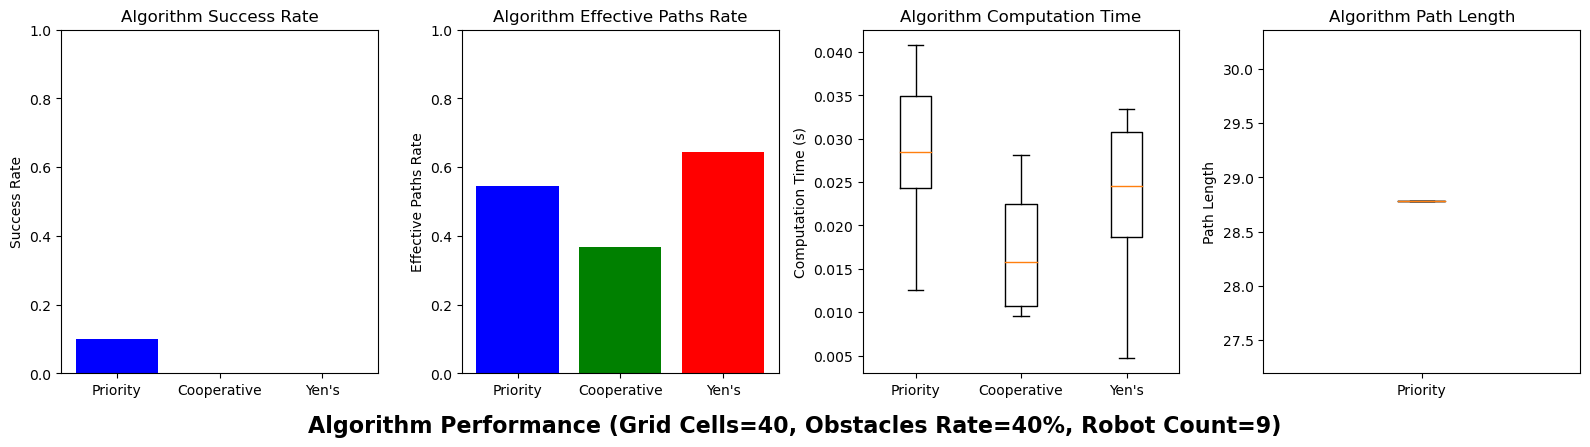

66.0
22.0
19.0
16.0
31.0
46.0
11.0
35.0
13.0
38.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0012055635452270508
Meaningful Path Lengths: [66.0, 22.0, 19.0, 16.0, 31.0, 46.0, 11.0, 35.0, 13.0, 38.0]
2.0
16.0
76.0
14.0
32.0
31.0
38.0
20.0
32.0
32.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.0034110546112060547
Meaningful Path Lengths: [2.0, 16.0, 76.0, 14.0, 32.0, 31.0, 38.0, 20.0, 32.0, 32.0]
41.0
37.0
49.0
64.0
79.0
30.0
16.0
21.0
20.0
10.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.002750134468078613
Meaningful Path Lengths: [41.0, 37.0, 49.0, 64.0, 79.0, 30.0, 16.0, 21.0, 20.0, 10.0]


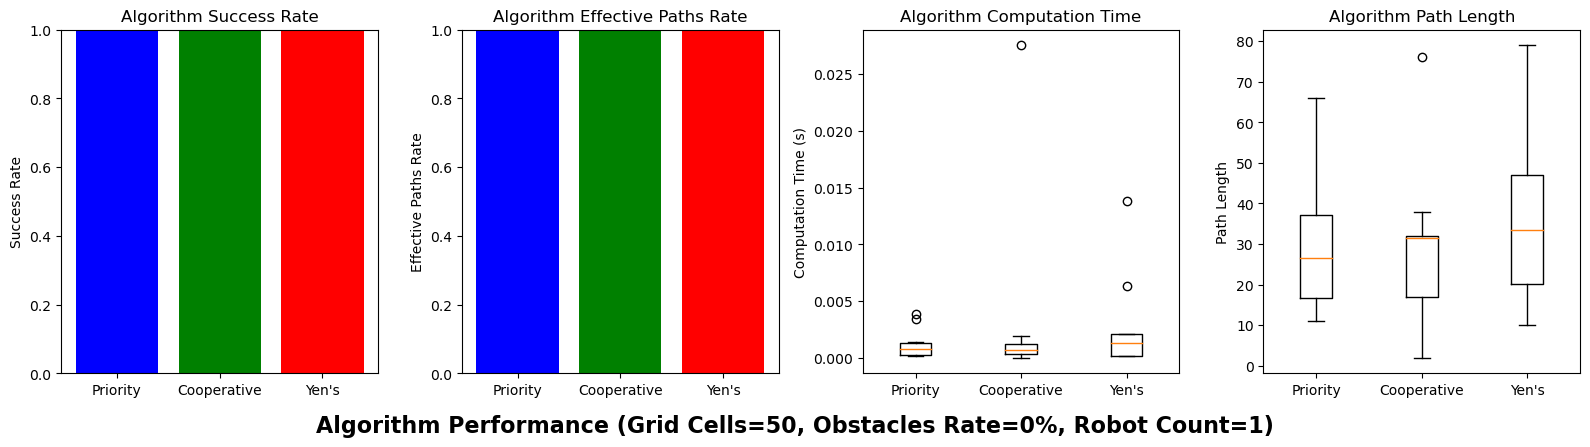

25.0
43.0
54.333333333333336
30.666666666666668
22.666666666666668
36.0
44.0
47.0
39.333333333333336
23.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.012353324890136718
Meaningful Path Lengths: [25.0, 43.0, 54.333333333333336, 30.666666666666668, 22.666666666666668, 36.0, 44.0, 47.0, 39.333333333333336, 23.0]
31.666666666666668
44.0
65.33333333333333
43.333333333333336
38.333333333333336
43.666666666666664
39.333333333333336
35.0
17.666666666666668
27.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.015772914886474608
Meaningful Path Lengths: [31.666666666666668, 44.0, 65.33333333333333, 43.333333333333336, 38.333333333333336, 43.666666666666664, 39.333333333333336, 35.0, 17.666666666666668, 27.0]
52.333333333333336
20.0
50.333333333333336
29.0
20.333333333333332
24.666666666666668
40.666666666666664
37.666666666666664
45.333333333333336
28.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.009018158912658692
Mean

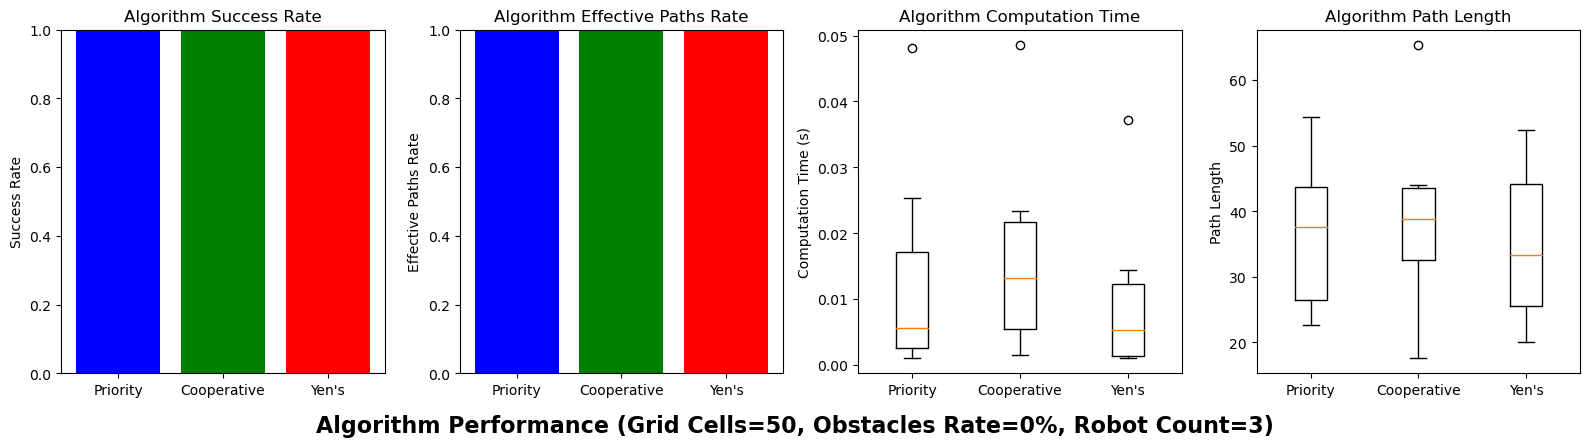

26.0
30.8
26.0
30.6
16.2
30.6
37.8
44.8
48.6
28.6
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.008652377128601074
Meaningful Path Lengths: [26.0, 30.8, 26.0, 30.6, 16.2, 30.6, 37.8, 44.8, 48.6, 28.6]
28.8
37.8
28.4
30.8
16.6
33.2
35.0
33.2
56.4
26.4
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.012868475914001466
Meaningful Path Lengths: [28.8, 37.8, 28.4, 30.8, 16.6, 33.2, 35.0, 33.2, 56.4, 26.4]
30.2
20.8
39.8
25.6
32.2
53.0
39.4
30.2
33.6
28.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.015077996253967284
Meaningful Path Lengths: [30.2, 20.8, 39.8, 25.6, 32.2, 53.0, 39.4, 30.2, 33.6, 28.0]


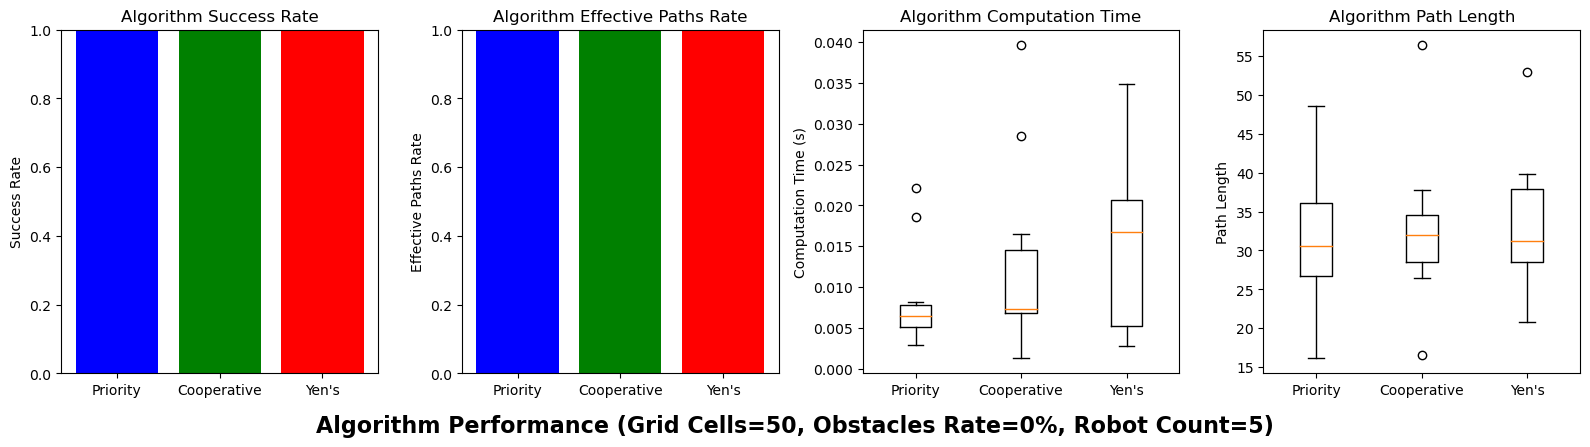

39.142857142857146
25.0
36.57142857142857
32.42857142857143
32.285714285714285
27.714285714285715
37.0
23.571428571428573
32.285714285714285
30.285714285714285
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.013564515113830566
Meaningful Path Lengths: [39.142857142857146, 25.0, 36.57142857142857, 32.42857142857143, 32.285714285714285, 27.714285714285715, 37.0, 23.571428571428573, 32.285714285714285, 30.285714285714285]
33.57142857142857
49.42857142857143
27.428571428571427
39.142857142857146
39.142857142857146
36.5
35.285714285714285
26.571428571428573
45.714285714285715
32.142857142857146
Success Rate: 0.9
Effective Path Rate: 0.9857142857142858
Average Computation Time: 0.022228097915649413
Meaningful Path Lengths: [33.57142857142857, 49.42857142857143, 27.428571428571427, 39.142857142857146, 39.142857142857146, 35.285714285714285, 26.571428571428573, 45.714285714285715, 32.142857142857146]
38.142857142857146
36.714285714285715
28.285714285714285
22.57142857142

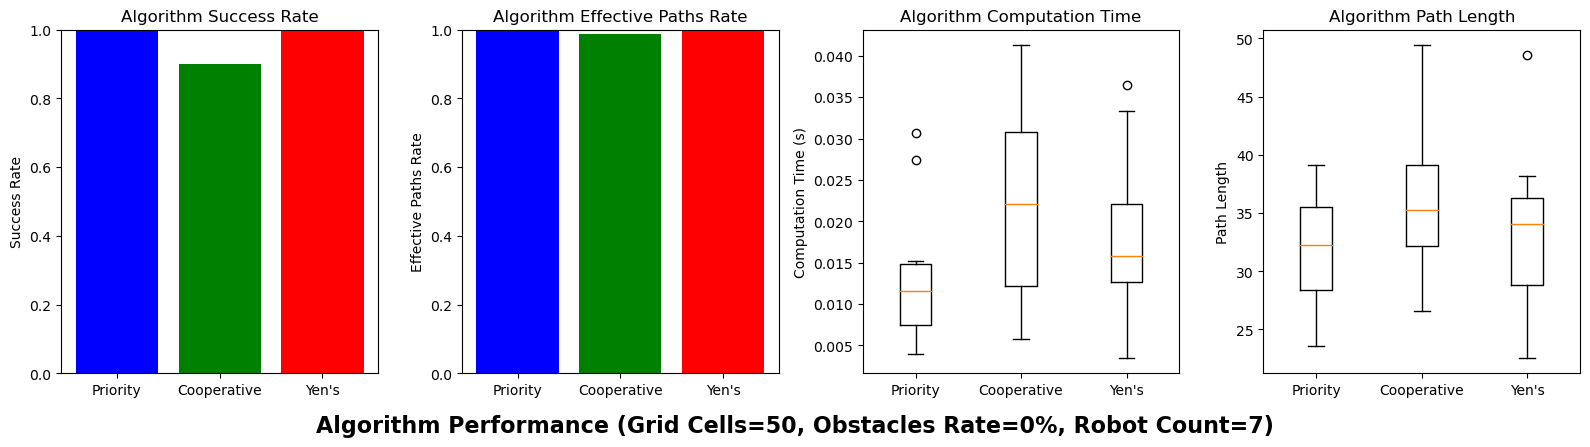

32.22222222222222
41.666666666666664
26.333333333333332
31.444444444444443
25.666666666666668
29.333333333333332
32.0
27.444444444444443
36.77777777777778
34.55555555555556
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.014572238922119141
Meaningful Path Lengths: [32.22222222222222, 41.666666666666664, 26.333333333333332, 31.444444444444443, 25.666666666666668, 29.333333333333332, 32.0, 27.444444444444443, 36.77777777777778, 34.55555555555556]
54.333333333333336
45.0
39.77777777777778
29.444444444444443
39.888888888888886
40.111111111111114
38.333333333333336
28.428571428571427
46.55555555555556
27.22222222222222
Success Rate: 0.8
Effective Path Rate: 0.9444444444444444
Average Computation Time: 0.03200688362121582
Meaningful Path Lengths: [45.0, 39.77777777777778, 29.444444444444443, 39.888888888888886, 40.111111111111114, 38.333333333333336, 46.55555555555556, 27.22222222222222]
31.333333333333332
38.0
40.44444444444444
36.111111111111114
32.55555555555556
35.

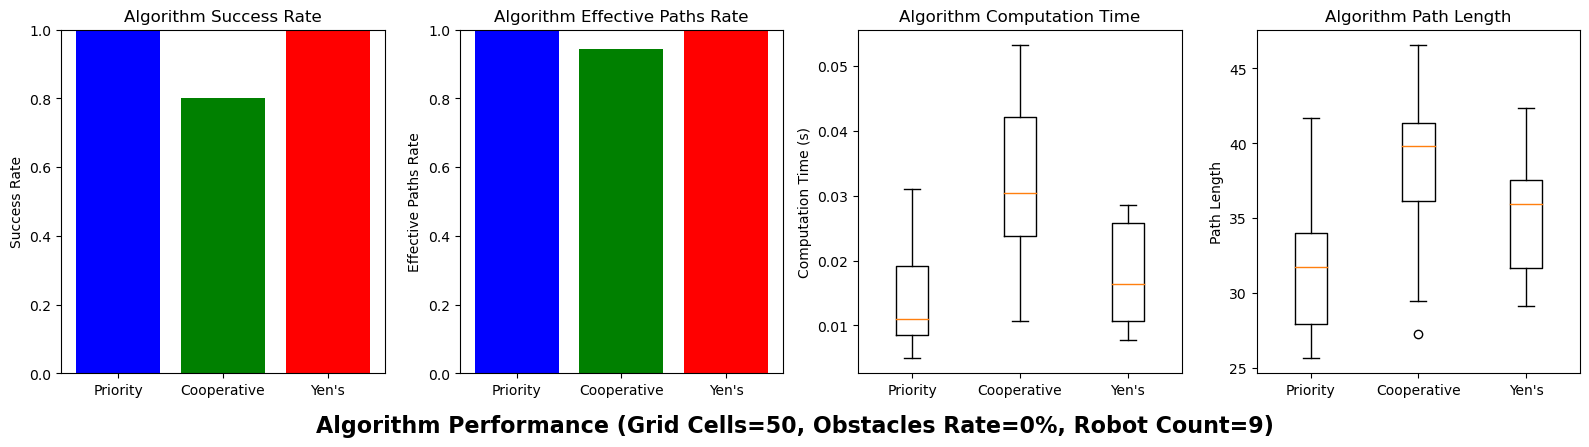

54.0
42.0
4.0
43.0
46.0
24.0
Success Rate: 0.6
Effective Path Rate: 0.6
Average Computation Time: 0.012290072441101075
Meaningful Path Lengths: [54.0, 42.0, 4.0, 43.0, 46.0, 24.0]
36.0
30.0
28.0
33.0
36.0
26.0
60.0
40.0
41.0
Success Rate: 0.9
Effective Path Rate: 0.9
Average Computation Time: 0.003525042533874512
Meaningful Path Lengths: [36.0, 30.0, 28.0, 33.0, 36.0, 26.0, 60.0, 40.0, 41.0]
43.0
55.0
42.0
32.0
23.0
47.0
56.0
65.0
70.0
33.0
Success Rate: 1.0
Effective Path Rate: 1.0
Average Computation Time: 0.004118895530700684
Meaningful Path Lengths: [43.0, 55.0, 42.0, 32.0, 23.0, 47.0, 56.0, 65.0, 70.0, 33.0]


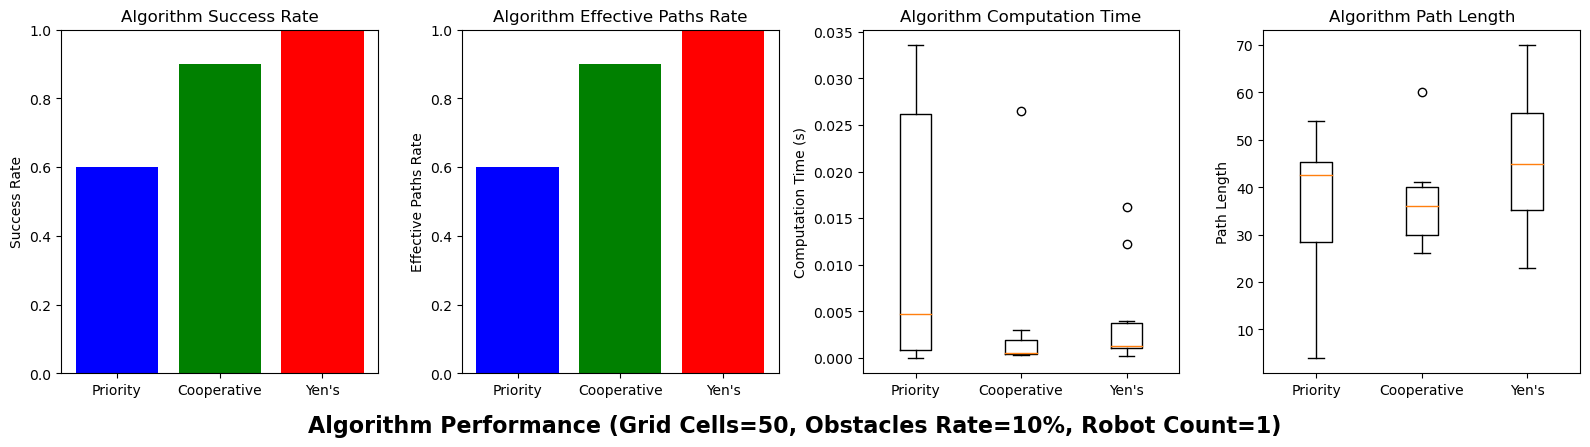

36.0
30.0
29.333333333333332
36.666666666666664
33.0
46.666666666666664
39.333333333333336
40.666666666666664
33.666666666666664
45.5
Success Rate: 0.9
Effective Path Rate: 0.9666666666666667
Average Computation Time: 0.009128212928771973
Meaningful Path Lengths: [36.0, 30.0, 29.333333333333332, 36.666666666666664, 33.0, 46.666666666666664, 39.333333333333336, 40.666666666666664, 33.666666666666664]
33.333333333333336
46.333333333333336
40.666666666666664
40.5
38.333333333333336
36.666666666666664
41.0
33.0
19.5
38.333333333333336
Success Rate: 0.8
Effective Path Rate: 0.9333333333333332
Average Computation Time: 0.015792703628540038
Meaningful Path Lengths: [33.333333333333336, 46.333333333333336, 40.666666666666664, 38.333333333333336, 36.666666666666664, 41.0, 33.0, 38.333333333333336]
43.0
38.333333333333336
44.0
40.333333333333336
27.666666666666668
53.333333333333336
23.0
38.666666666666664
30.333333333333332
24.333333333333332
Success Rate: 0.8
Effective Path Rate: 0.9
Average C

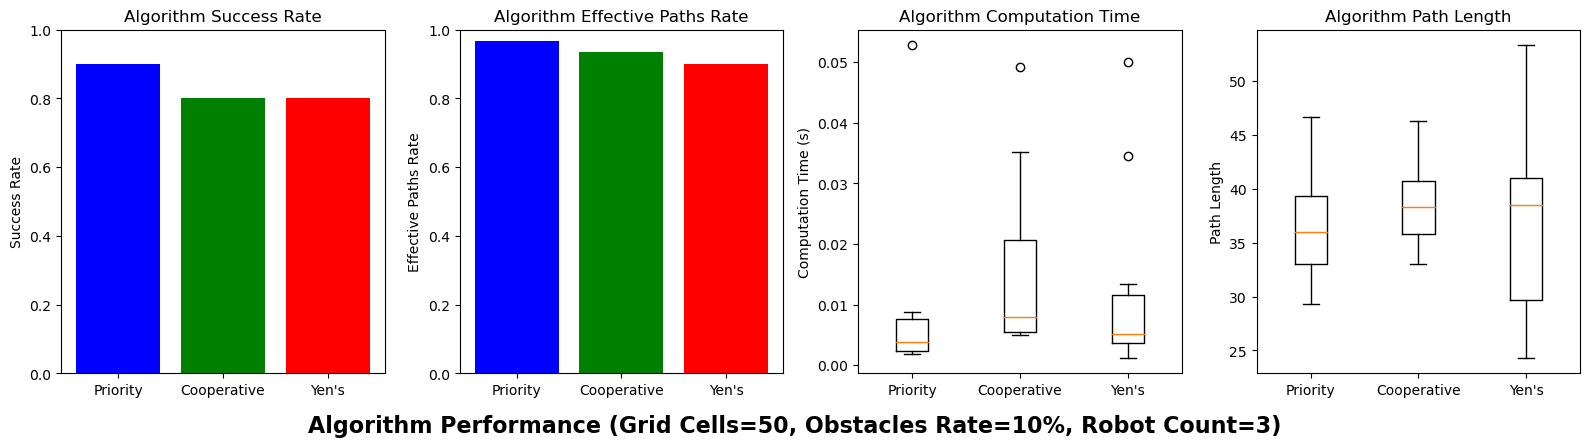

20.0
24.4
17.6
34.4
26.75
18.0
27.75
34.2
23.666666666666668
29.5
Success Rate: 0.4
Effective Path Rate: 0.86
Average Computation Time: 0.01986086368560791
Meaningful Path Lengths: [24.4, 17.6, 34.4, 34.2]
28.4
64.25
58.75
58.25
42.4
37.25
29.8
41.5
50.4
34.0
Success Rate: 0.5
Effective Path Rate: 0.9
Average Computation Time: 0.02646160125732422
Meaningful Path Lengths: [28.4, 42.4, 29.8, 50.4, 34.0]
37.5
41.0
24.2
26.6
52.0
26.0
34.8
26.8
24.6
26.75
Success Rate: 0.7
Effective Path Rate: 0.9400000000000001
Average Computation Time: 0.01663362979888916
Meaningful Path Lengths: [41.0, 24.2, 26.6, 26.0, 34.8, 26.8, 24.6]


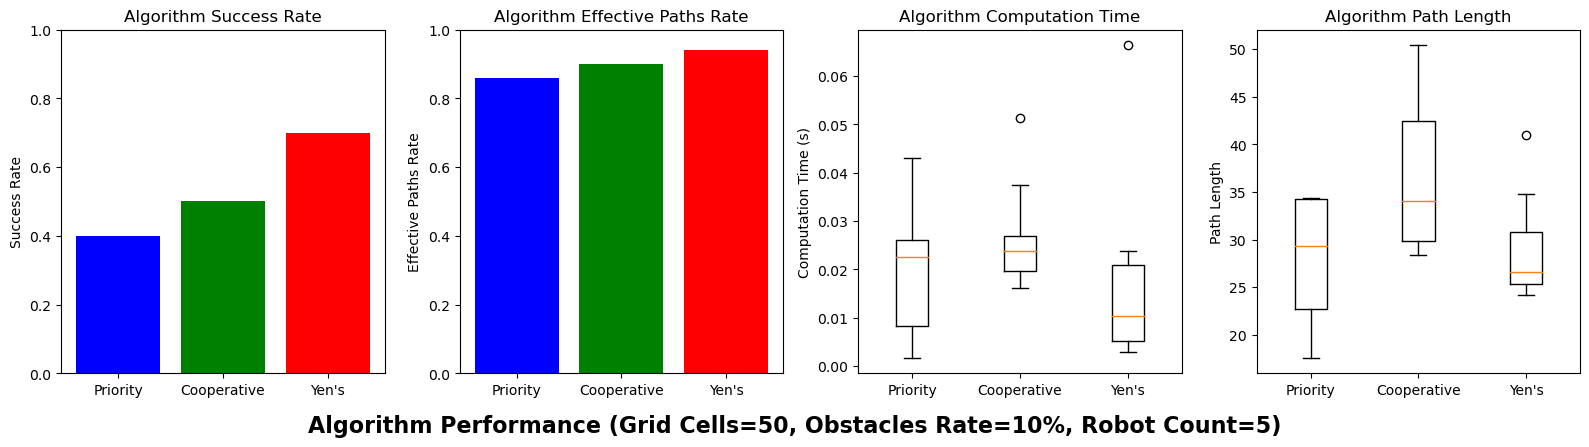

26.142857142857142
32.333333333333336
27.333333333333332
32.166666666666664
39.0
34.857142857142854
44.42857142857143
24.5
34.6
34.0
Success Rate: 0.3
Effective Path Rate: 0.8571428571428571
Average Computation Time: 0.04043338298797607
Meaningful Path Lengths: [26.142857142857142, 34.857142857142854, 44.42857142857143]
29.285714285714285
42.6
38.285714285714285
40.142857142857146
39.5
53.6
18.166666666666668
55.833333333333336
33.857142857142854
32.285714285714285
Success Rate: 0.5
Effective Path Rate: 0.9
Average Computation Time: 0.030428814888000488
Meaningful Path Lengths: [29.285714285714285, 38.285714285714285, 40.142857142857146, 33.857142857142854, 32.285714285714285]
29.714285714285715
33.0
31.0
38.0
23.5
33.833333333333336
27.714285714285715
37.57142857142857
34.166666666666664
15.714285714285714
Success Rate: 0.6
Effective Path Rate: 0.9285714285714286
Average Computation Time: 0.019804167747497558
Meaningful Path Lengths: [29.714285714285715, 33.0, 38.0, 27.714285714285715

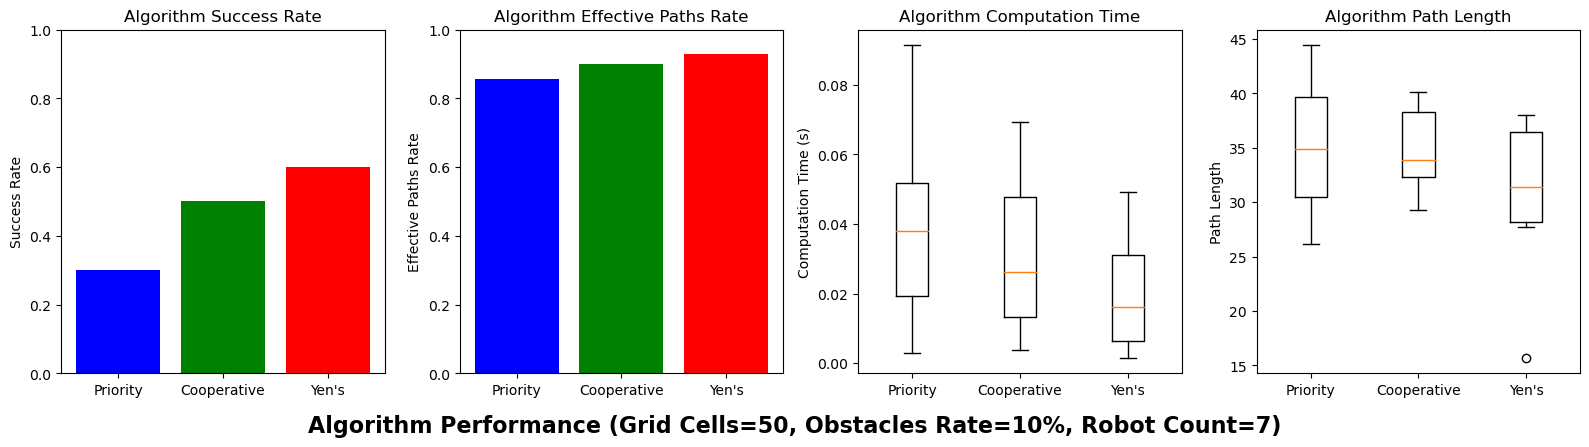

39.22222222222222
26.88888888888889
37.6
35.75
35.22222222222222
32.125
27.875
29.666666666666668
39.875
40.875
Success Rate: 0.4
Effective Path Rate: 0.8999999999999999
Average Computation Time: 0.035250401496887206
Meaningful Path Lengths: [39.22222222222222, 26.88888888888889, 35.22222222222222, 29.666666666666668]
40.875
32.666666666666664
31.75
29.666666666666668
38.4
22.375
31.0
61.57142857142857
30.22222222222222
32.0
Success Rate: 0.1
Effective Path Rate: 0.7888888888888889
Average Computation Time: 0.04601941108703613
Meaningful Path Lengths: [30.22222222222222]
29.571428571428573
28.0
38.625
30.75
35.55555555555556
26.22222222222222
34.0
38.22222222222222
33.111111111111114
25.0
Success Rate: 0.4
Effective Path Rate: 0.911111111111111
Average Computation Time: 0.03651902675628662
Meaningful Path Lengths: [35.55555555555556, 26.22222222222222, 38.22222222222222, 33.111111111111114]


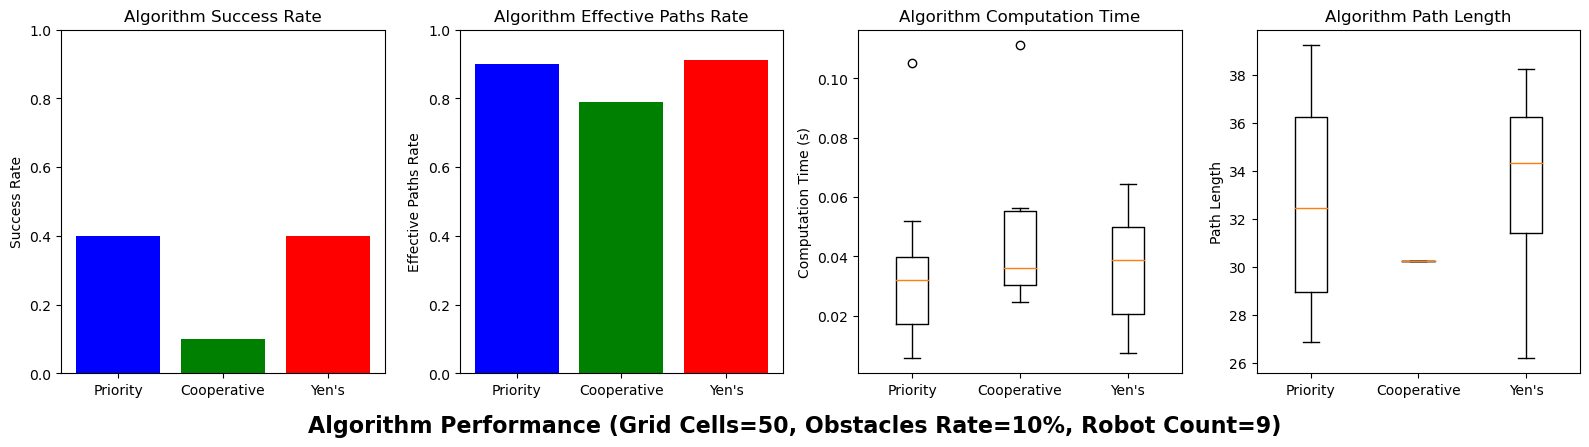

28.0
29.0
33.0
51.0
43.0
23.0
39.0
Success Rate: 0.7
Effective Path Rate: 0.7
Average Computation Time: 0.006566476821899414
Meaningful Path Lengths: [28.0, 29.0, 33.0, 51.0, 43.0, 23.0, 39.0]
46.0
52.0
31.0
30.0
57.0
44.0
51.0
49.0
42.0
Success Rate: 0.9
Effective Path Rate: 0.9
Average Computation Time: 0.0033609628677368163
Meaningful Path Lengths: [46.0, 52.0, 31.0, 30.0, 57.0, 44.0, 51.0, 49.0, 42.0]
62.0
48.0
10.0
33.0
59.0
62.0
17.0
25.0
26.0
Success Rate: 0.9
Effective Path Rate: 0.9
Average Computation Time: 0.003506636619567871
Meaningful Path Lengths: [62.0, 48.0, 10.0, 33.0, 59.0, 62.0, 17.0, 25.0, 26.0]


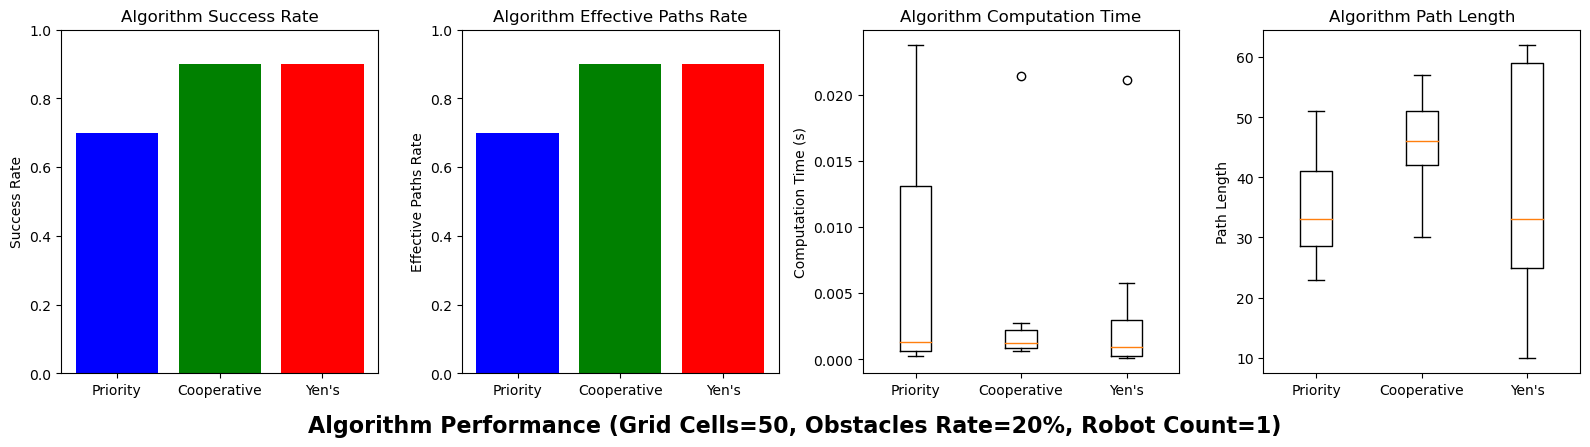

37.0
35.666666666666664
23.0
36.0
24.0
36.0
29.666666666666668
47.5
44.333333333333336
Success Rate: 0.5
Effective Path Rate: 0.7666666666666666
Average Computation Time: 0.016915011405944824
Meaningful Path Lengths: [37.0, 35.666666666666664, 36.0, 29.666666666666668, 44.333333333333336]
30.666666666666668
40.333333333333336
30.0
51.666666666666664
48.333333333333336
19.333333333333332
25.5
32.0
59.666666666666664
48.0
Success Rate: 0.7
Effective Path Rate: 0.8333333333333334
Average Computation Time: 0.013478922843933105
Meaningful Path Lengths: [30.666666666666668, 40.333333333333336, 30.0, 51.666666666666664, 48.333333333333336, 19.333333333333332, 59.666666666666664]
37.333333333333336
30.333333333333332
26.0
24.0
18.666666666666668
39.333333333333336
44.5
53.5
19.5
20.666666666666668
Success Rate: 0.5
Effective Path Rate: 0.8333333333333334
Average Computation Time: 0.013408708572387695
Meaningful Path Lengths: [37.333333333333336, 30.333333333333332, 18.666666666666668, 39.33333

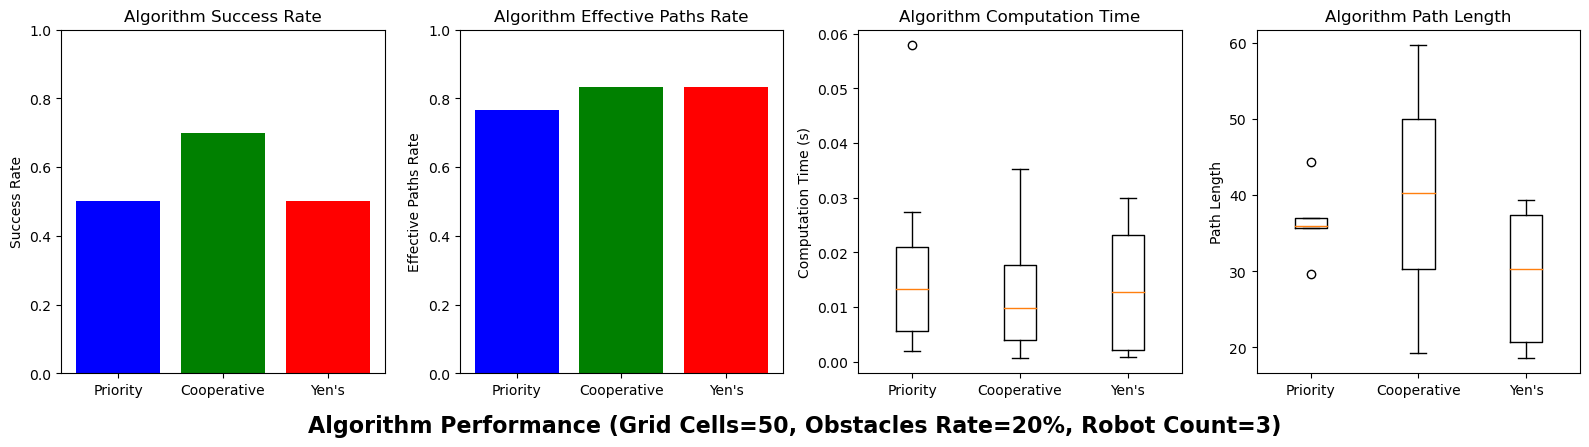

43.2
38.0
31.0
35.5
45.75
25.25
26.666666666666668
42.2
40.4
23.4
Success Rate: 0.5
Effective Path Rate: 0.86
Average Computation Time: 0.02053680419921875
Meaningful Path Lengths: [43.2, 38.0, 42.2, 40.4, 23.4]
37.25
23.0
28.5
45.333333333333336
31.0
32.4
35.0
28.75
37.0
60.666666666666664
Success Rate: 0.4
Effective Path Rate: 0.82
Average Computation Time: 0.01813673973083496
Meaningful Path Lengths: [23.0, 31.0, 32.4, 37.0]
23.666666666666668
33.8
35.25
23.8
28.8
34.0
41.75
40.25
25.5
35.6
Success Rate: 0.4
Effective Path Rate: 0.86
Average Computation Time: 0.018583226203918456
Meaningful Path Lengths: [33.8, 23.8, 28.8, 35.6]


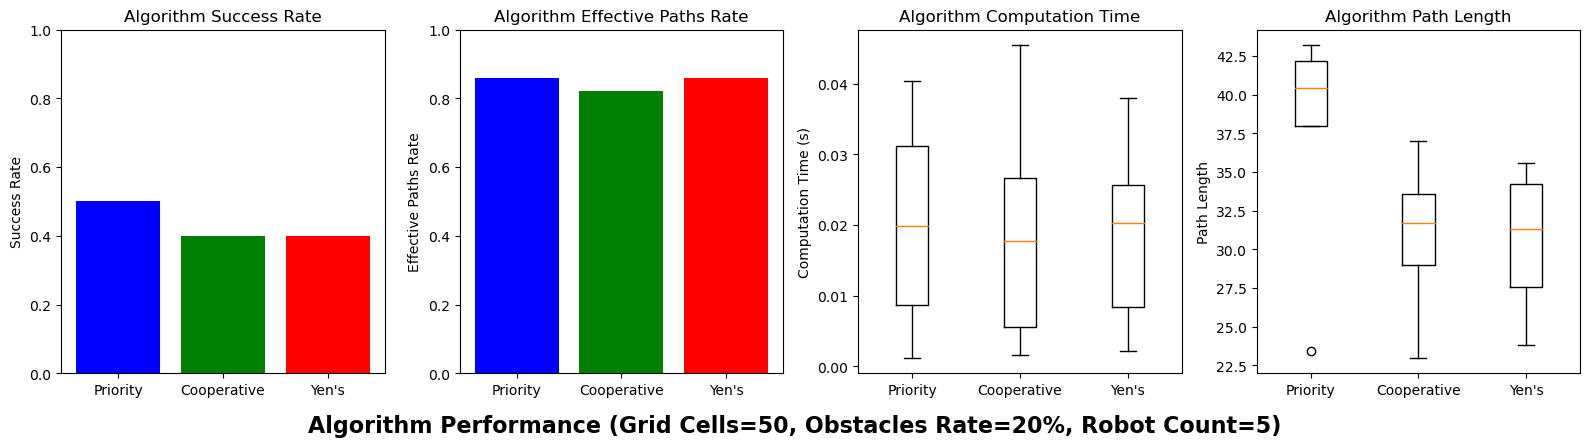

32.75
32.25
39.285714285714285
29.833333333333332
36.714285714285715
28.4
24.0
34.0
25.166666666666668
41.166666666666664
Success Rate: 0.3
Effective Path Rate: 0.7857142857142857
Average Computation Time: 0.038884854316711424
Meaningful Path Lengths: [39.285714285714285, 36.714285714285715, 34.0]
61.0
39.2
46.6
35.2
50.8
37.5
34.5
40.166666666666664
63.0
51.25
Success Rate: 0.0
Effective Path Rate: 0.7000000000000001
Average Computation Time: 0.031223011016845704
Meaningful Path Lengths: []
42.166666666666664
29.571428571428573
25.4
36.5
42.57142857142857
21.857142857142858
37.75
32.0
29.8
25.857142857142858
Success Rate: 0.4
Effective Path Rate: 0.8142857142857143
Average Computation Time: 0.030673575401306153
Meaningful Path Lengths: [29.571428571428573, 42.57142857142857, 21.857142857142858, 25.857142857142858]


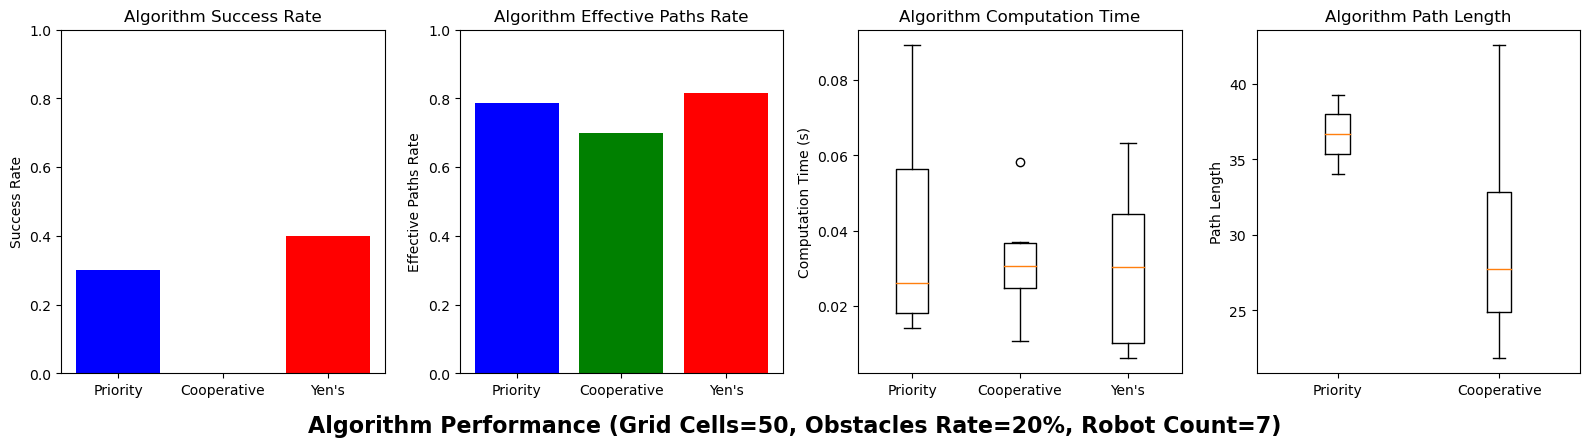

26.571428571428573
35.5
32.42857142857143
25.125
36.0
29.875
22.666666666666668
38.0
38.0
40.5
Success Rate: 0.0
Effective Path Rate: 0.8
Average Computation Time: 0.04840142726898193
Meaningful Path Lengths: []
31.625
29.5
41.375
34.5
31.166666666666668
41.0
48.4
36.25
41.166666666666664
18.857142857142858
Success Rate: 0.0
Effective Path Rate: 0.7
Average Computation Time: 0.048100066184997556
Meaningful Path Lengths: []
32.285714285714285
30.375
31.75
27.125
23.875
26.5
29.285714285714285
31.22222222222222
37.6
34.666666666666664
Success Rate: 0.2
Effective Path Rate: 0.8333333333333334
Average Computation Time: 0.038244318962097165
Meaningful Path Lengths: [31.22222222222222, 34.666666666666664]


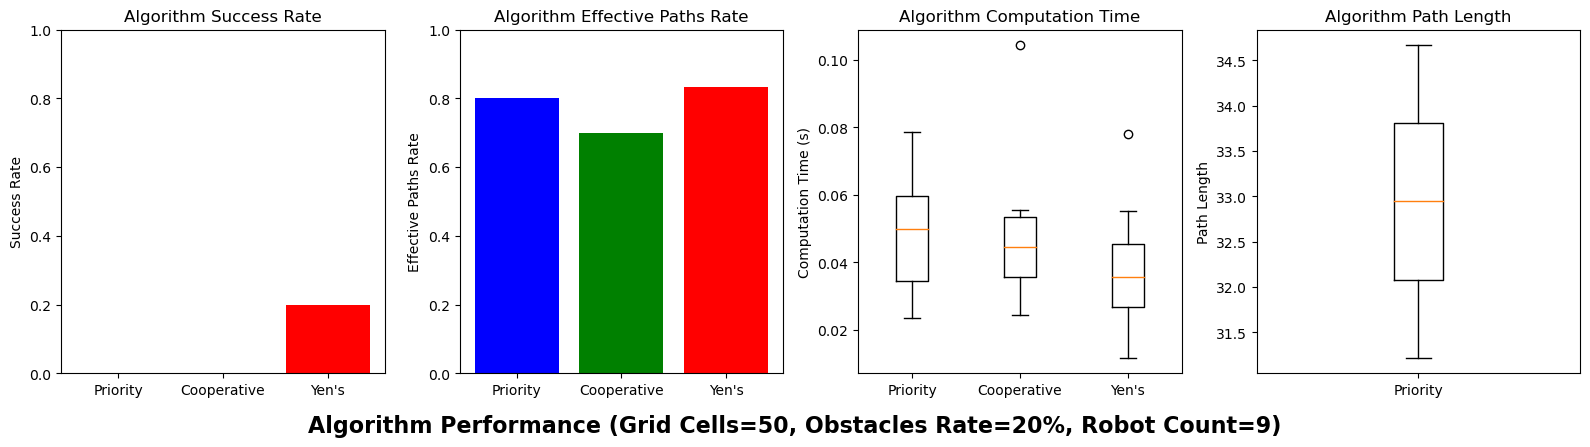

22.0
67.0
11.0
30.0
22.0
35.0
22.0
Success Rate: 0.7
Effective Path Rate: 0.7
Average Computation Time: 0.0033898353576660156
Meaningful Path Lengths: [22.0, 67.0, 11.0, 30.0, 22.0, 35.0, 22.0]
58.0
29.0
23.0
38.0
25.0
29.0
Success Rate: 0.6
Effective Path Rate: 0.6
Average Computation Time: 0.007044148445129394
Meaningful Path Lengths: [58.0, 29.0, 23.0, 38.0, 25.0, 29.0]
14.0
33.0
41.0
45.0
47.0
26.0
Success Rate: 0.6
Effective Path Rate: 0.6
Average Computation Time: 0.007405614852905274
Meaningful Path Lengths: [14.0, 33.0, 41.0, 45.0, 47.0, 26.0]


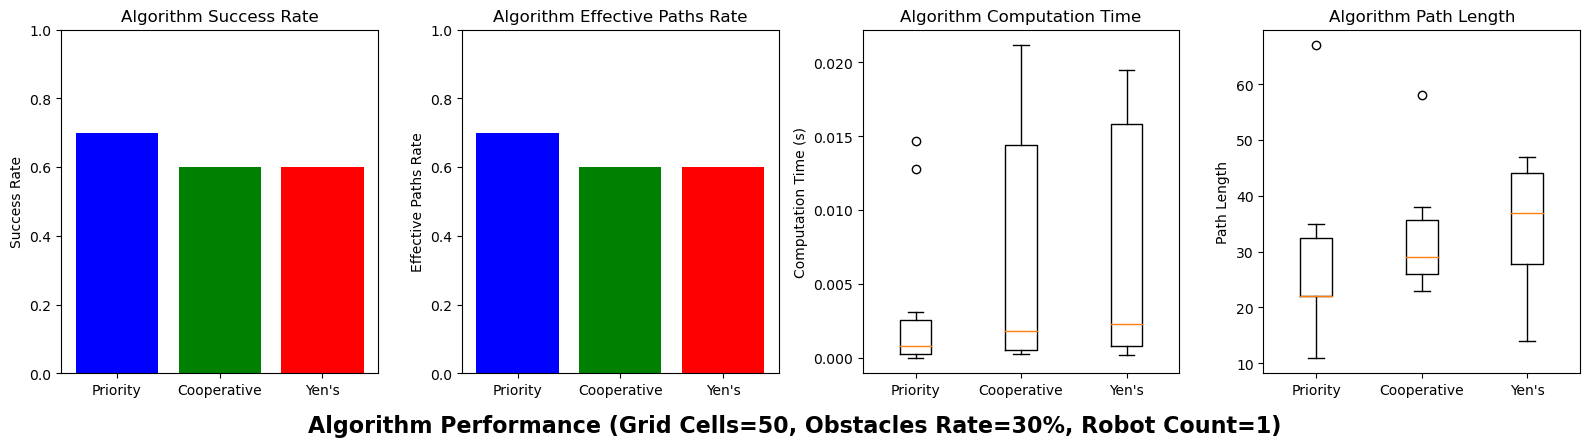

68.0
24.0
36.0
32.666666666666664
43.0
56.0
28.333333333333332
56.5
40.0
37.0
Success Rate: 0.3
Effective Path Rate: 0.6
Average Computation Time: 0.020371413230895995
Meaningful Path Lengths: [32.666666666666664, 28.333333333333332, 40.0]
30.5
31.666666666666668
47.666666666666664
45.0
20.0
40.0
26.5
37.333333333333336
23.0
46.0
Success Rate: 0.5
Effective Path Rate: 0.7999999999999999
Average Computation Time: 0.01219472885131836
Meaningful Path Lengths: [31.666666666666668, 47.666666666666664, 20.0, 37.333333333333336, 46.0]
55.0
59.0
27.0
36.5
20.5
30.0
39.0
45.0
22.0
37.5
Success Rate: 0.1
Effective Path Rate: 0.6666666666666666
Average Computation Time: 0.015888285636901856
Meaningful Path Lengths: [27.0]


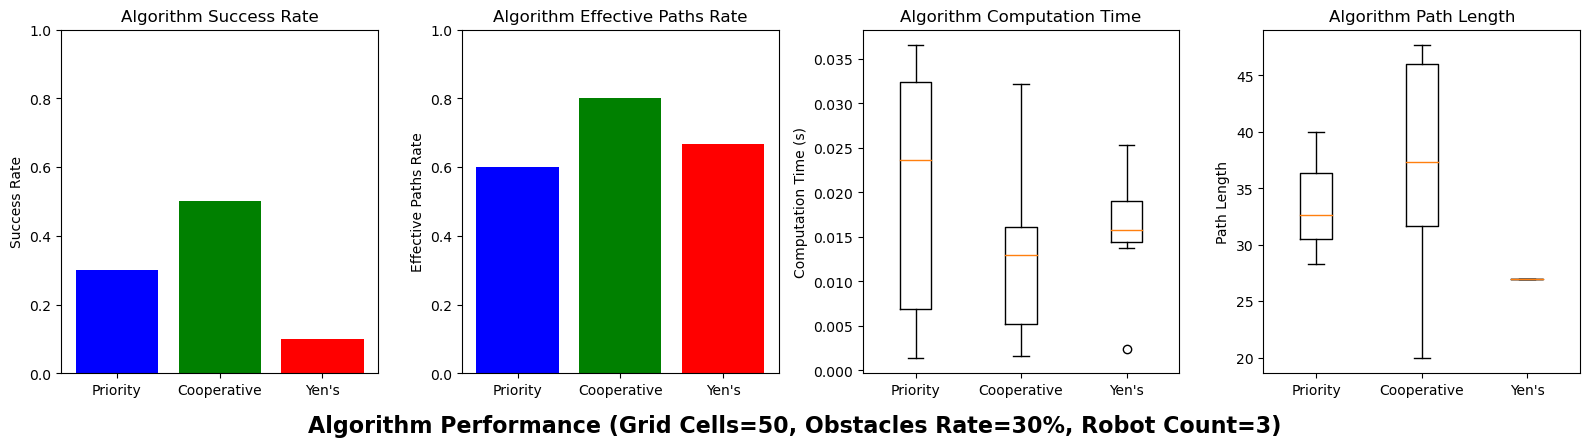

24.25
43.0
37.6
48.2
57.333333333333336
36.25
35.8
32.0
37.0
30.0
Success Rate: 0.3
Effective Path Rate: 0.72
Average Computation Time: 0.025974392890930176
Meaningful Path Lengths: [37.6, 48.2, 35.8]
63.0
69.33333333333333
35.4
24.8
31.333333333333332
29.333333333333332
26.25
67.5
52.75
34.75
Success Rate: 0.2
Effective Path Rate: 0.72
Average Computation Time: 0.02137458324432373
Meaningful Path Lengths: [35.4, 24.8]
46.5
38.4
36.666666666666664
30.6
40.25
24.75
36.5
35.8
46.0
33.333333333333336
Success Rate: 0.3
Effective Path Rate: 0.76
Average Computation Time: 0.022629547119140624
Meaningful Path Lengths: [38.4, 30.6, 35.8]


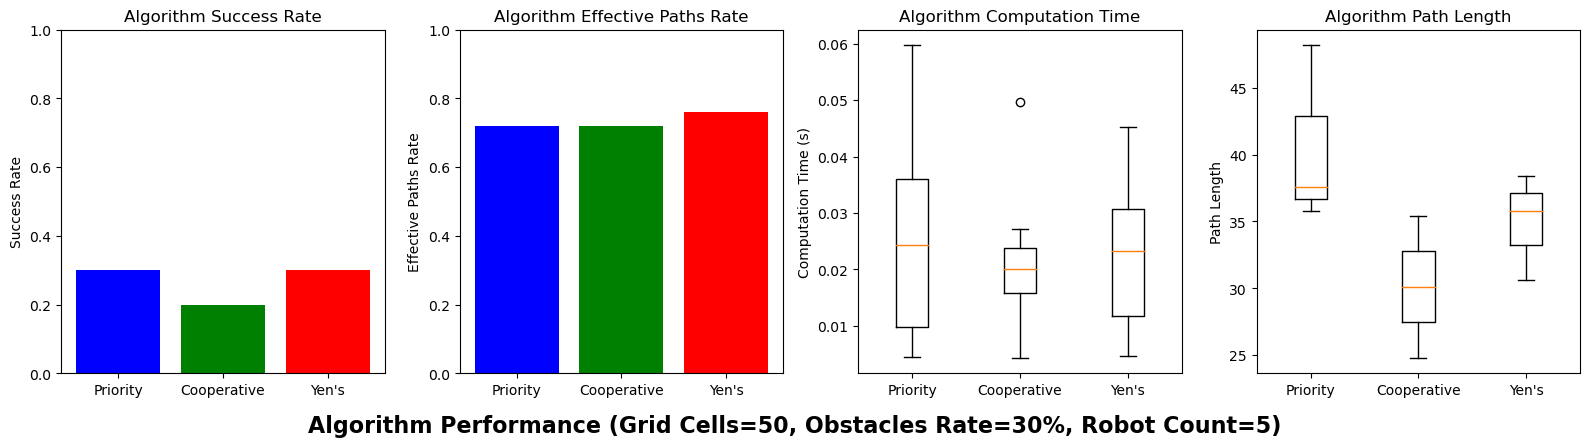

30.333333333333332
38.833333333333336
29.8
37.0
40.0
32.666666666666664
35.0
31.0
34.4
44.5
Success Rate: 0.0
Effective Path Rate: 0.6714285714285715
Average Computation Time: 0.04028997421264648
Meaningful Path Lengths: []
40.5
50.333333333333336
20.0
31.0
50.0
45.2
33.0
43.25
43.2
20.0
Success Rate: 0.0
Effective Path Rate: 0.6142857142857142
Average Computation Time: 0.03689982891082764
Meaningful Path Lengths: []
22.0
36.2
33.8
35.166666666666664
52.0
37.666666666666664
33.0
37.2
43.333333333333336
22.75
Success Rate: 0.0
Effective Path Rate: 0.6285714285714287
Average Computation Time: 0.04303684234619141
Meaningful Path Lengths: []


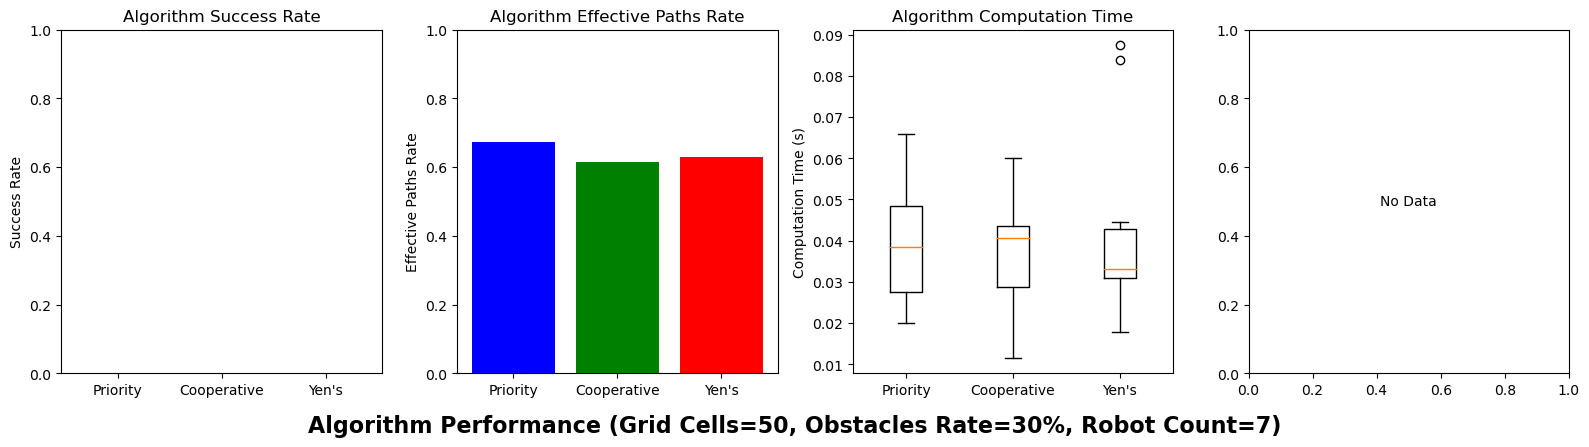

31.88888888888889
28.714285714285715
35.285714285714285
28.875
33.77777777777778
34.2
38.625
37.0
41.714285714285715
29.0
Success Rate: 0.2
Effective Path Rate: 0.8111111111111111
Average Computation Time: 0.038457274436950684
Meaningful Path Lengths: [31.88888888888889, 33.77777777777778]
50.2
53.142857142857146
34.125
26.5
36.2
52.333333333333336
54.0
58.8
21.4
35.5
Success Rate: 0.0
Effective Path Rate: 0.6000000000000001
Average Computation Time: 0.04215826988220215
Meaningful Path Lengths: []
35.0
34.142857142857146
22.5
28.25
33.857142857142854
29.285714285714285
31.142857142857142
26.25
41.333333333333336
33.833333333333336
Success Rate: 0.0
Effective Path Rate: 0.7222222222222222
Average Computation Time: 0.04031820297241211
Meaningful Path Lengths: []


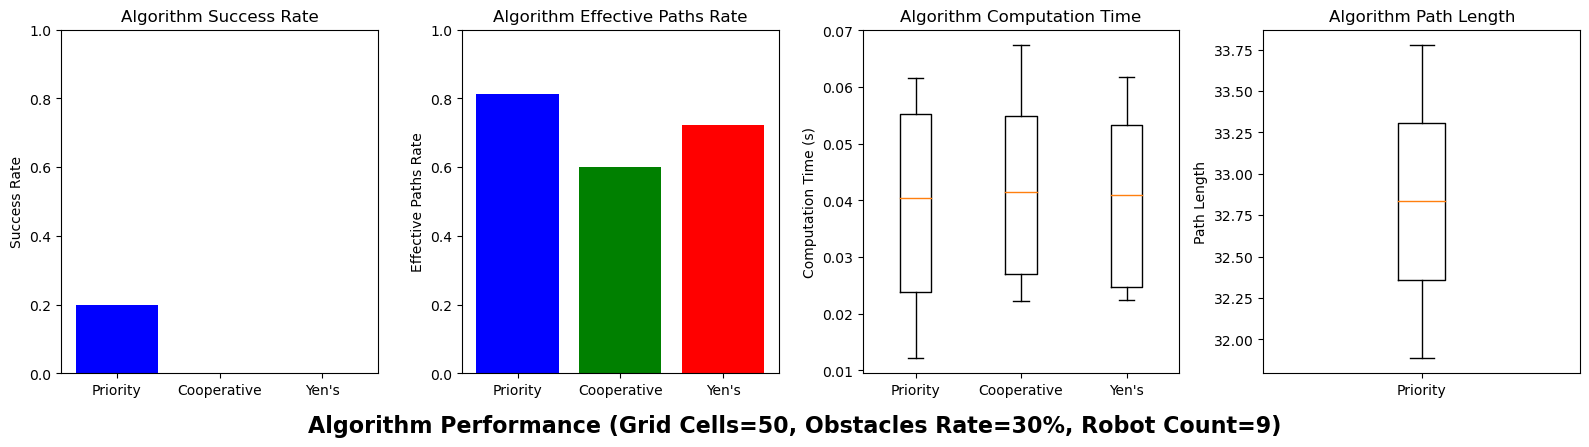

49.0
43.0
27.0
49.0
18.0
Success Rate: 0.5
Effective Path Rate: 0.5
Average Computation Time: 0.004804253578186035
Meaningful Path Lengths: [49.0, 43.0, 27.0, 49.0, 18.0]
16.0
28.0
12.0
Success Rate: 0.3
Effective Path Rate: 0.3
Average Computation Time: 0.006174540519714356
Meaningful Path Lengths: [16.0, 28.0, 12.0]
52.0
29.0
13.0
29.0
52.0
41.0
Success Rate: 0.6
Effective Path Rate: 0.6
Average Computation Time: 0.00449674129486084
Meaningful Path Lengths: [52.0, 29.0, 13.0, 29.0, 52.0, 41.0]


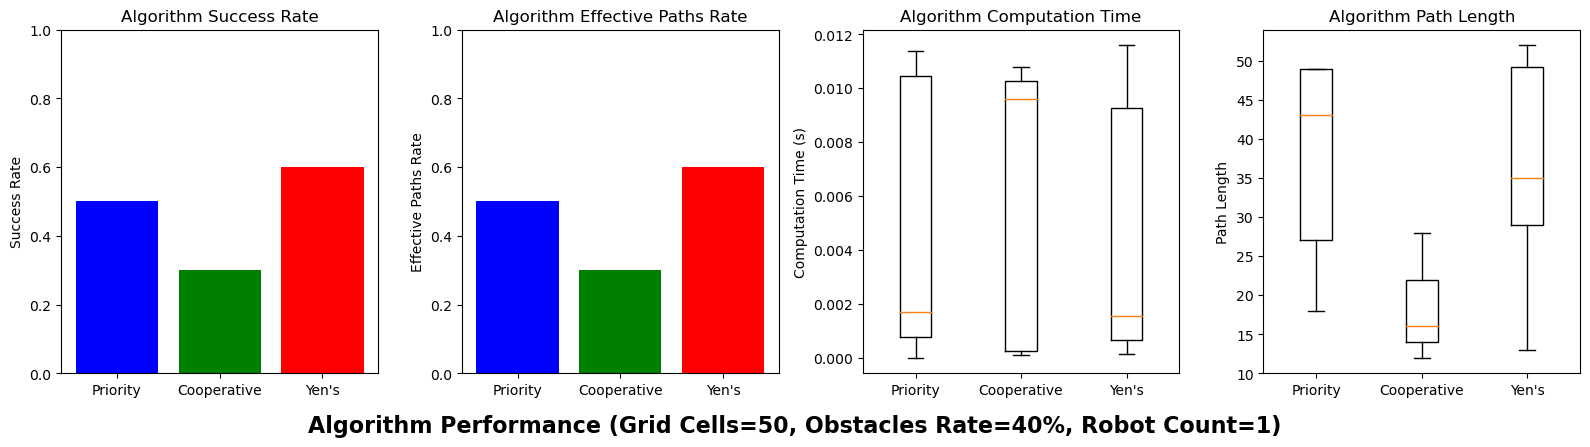

40.0
55.5
49.5
61.5
52.0
9.0
23.0
88.0
37.0
7.0
Success Rate: 0.2
Effective Path Rate: 0.5666666666666667
Average Computation Time: 0.011662149429321289
Meaningful Path Lengths: [40.0, 37.0]
43.0
14.5
69.5
43.0
88.0
39.5
35.0
41.5
50.0
Success Rate: 0.1
Effective Path Rate: 0.5
Average Computation Time: 0.01326005458831787
Meaningful Path Lengths: [43.0]
48.666666666666664
45.0
33.333333333333336
35.5
56.5
76.0
43.0
68.0
17.5
72.0
Success Rate: 0.2
Effective Path Rate: 0.6333333333333333
Average Computation Time: 0.015209817886352539
Meaningful Path Lengths: [48.666666666666664, 33.333333333333336]


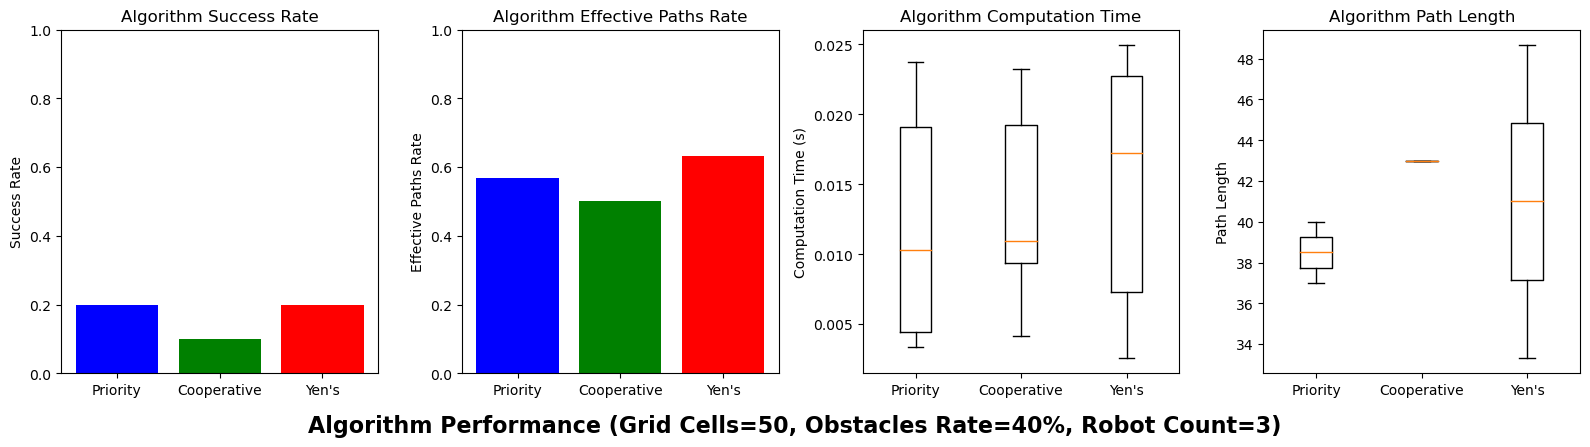

33.5
33.0
24.5
50.666666666666664
42.5
33.6
44.0
35.0
29.666666666666668
45.5
Success Rate: 0.1
Effective Path Rate: 0.6
Average Computation Time: 0.021777248382568358
Meaningful Path Lengths: [33.6]
38.333333333333336
39.5
23.5
41.666666666666664
29.666666666666668
37.0
60.75
48.0
57.0
Success Rate: 0.0
Effective Path Rate: 0.5
Average Computation Time: 0.020092177391052245
Meaningful Path Lengths: []
44.666666666666664
33.0
22.0
39.25
14.5
33.0
44.5
39.666666666666664
46.0
23.666666666666668
Success Rate: 0.0
Effective Path Rate: 0.58
Average Computation Time: 0.025613617897033692
Meaningful Path Lengths: []


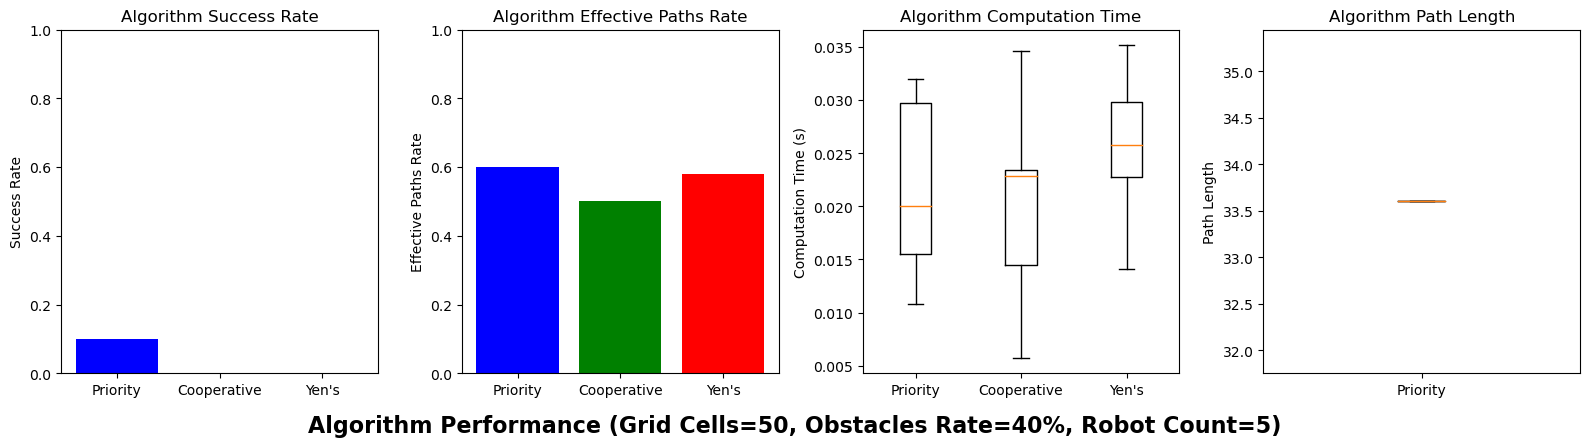

35.5
55.25
43.75
29.6
41.0
37.333333333333336
53.333333333333336
17.8
41.0
44.0
Success Rate: 0.0
Effective Path Rate: 0.6142857142857142
Average Computation Time: 0.03319969177246094
Meaningful Path Lengths: []
42.75
40.666666666666664
19.0
58.333333333333336
40.0
25.333333333333332
52.0
43.0
46.0
51.666666666666664
Success Rate: 0.0
Effective Path Rate: 0.4714285714285714
Average Computation Time: 0.01764540672302246
Meaningful Path Lengths: []
27.0
41.5
40.0
42.57142857142857
39.0
28.333333333333332
38.4
41.4
8.0
43.0
Success Rate: 0.1
Effective Path Rate: 0.5285714285714286
Average Computation Time: 0.038327503204345706
Meaningful Path Lengths: [42.57142857142857]


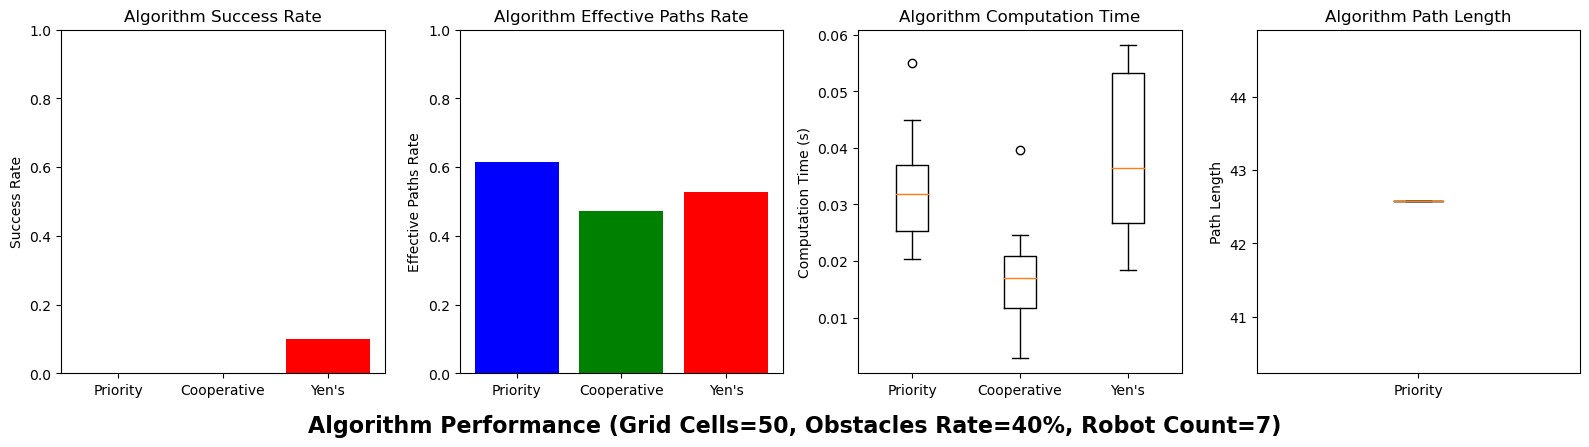

36.0
47.833333333333336
33.0
46.0
50.75
32.833333333333336
38.0
30.833333333333332
34.5
30.0
Success Rate: 0.0
Effective Path Rate: 0.6111111111111112
Average Computation Time: 0.0436063289642334
Meaningful Path Lengths: []
39.0
21.25
42.666666666666664
35.0
49.0
59.666666666666664
39.4
29.0
53.0
35.333333333333336
Success Rate: 0.0
Effective Path Rate: 0.4
Average Computation Time: 0.024918317794799805
Meaningful Path Lengths: []
27.0
44.0
26.666666666666668
45.8
23.333333333333332
36.666666666666664
32.75
33.666666666666664
37.714285714285715
41.0
Success Rate: 0.0
Effective Path Rate: 0.5444444444444445
Average Computation Time: 0.04733126163482666
Meaningful Path Lengths: []


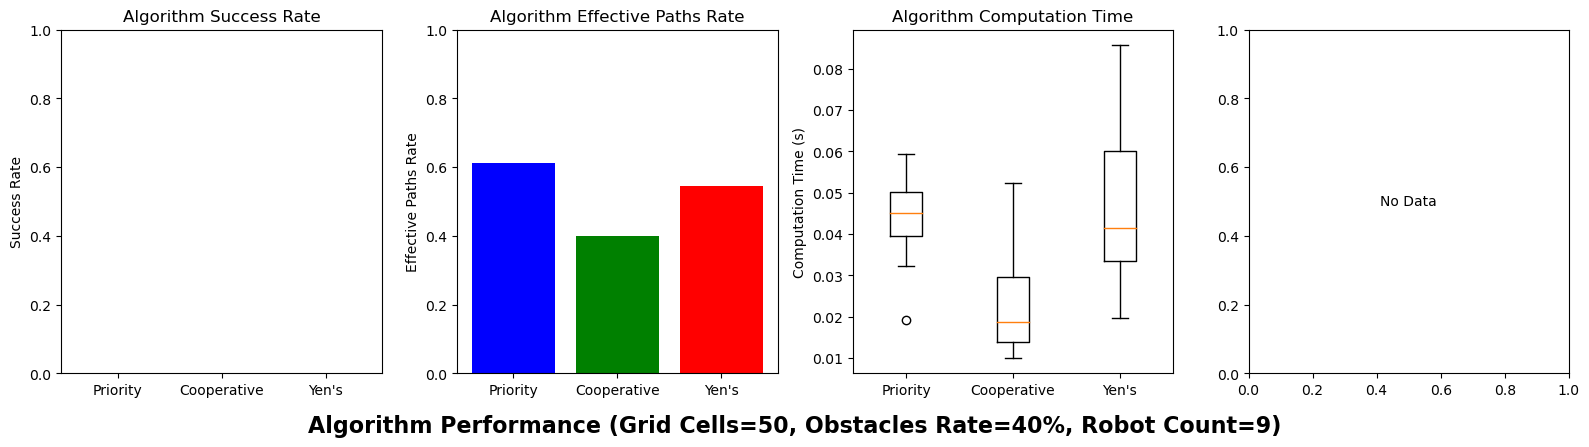

In [6]:
# Performance
for grid_cell in grid_cells:
    for obstacles_rate in obstacles_rates:
        for robot_count in robot_counts:
            # Format
            for K in K_values:
                #
                priority_success, priority_effective, priority_times, priority_lengths  = analyze_algorithm(priority_algorithm, grid_cell,obstacles_rate, robot_count)
#                 priority_success, priority_effective, priority_times, priority_lengths,average_computation_time, average_path_length = analyze_algorithm(priority_algorithm, grid_cell,obstacles_rate, robot_count)
                cooperative_success, cooperative_effective, cooperative_times, cooperative_lengths = analyze_algorithm(cooperative_a_star, grid_cell,obstacles_rate, robot_count)
                yen_success, yen_effective, yen_times, yen_lengths = analyze_algorithm(yen_k_algorithm, grid_cell,obstacles_rate, robot_count)

                results.append({
                    'grid_cell': grid_cell,
                    'obstacles_rate': obstacles_rate,
                    'robot_count': robot_count,
                    'priority': (priority_success, priority_effective, priority_times, priority_lengths),
                    'cooperative': (  cooperative_success, cooperative_effective, cooperative_times, cooperative_lengths),
                    'yen': (yen_success, yen_effective, yen_times, yen_lengths)
                    
#                     ,
#                     'success_rate': success_rate,
#                     'effective_path_rate': effective_path_rate,
#                     'average_computation_time': average_computation_time,
#                     'average_path_length': average_path_length
                })
                
                plot_results(grid_cell, obstacles_rate, robot_count,
             priority_success, priority_effective, priority_times, priority_lengths,
             cooperative_success, cooperative_effective, cooperative_times, cooperative_lengths,
             yen_success, yen_effective, yen_times, yen_lengths)

                   grid_cell  obstacles_rate   robot_count
grid_cell       1.000000e+00    8.532826e-17 -3.486972e-16
obstacles_rate  8.532826e-17    1.000000e+00 -1.326346e-16
robot_count    -3.486972e-16   -1.326346e-16  1.000000e+00


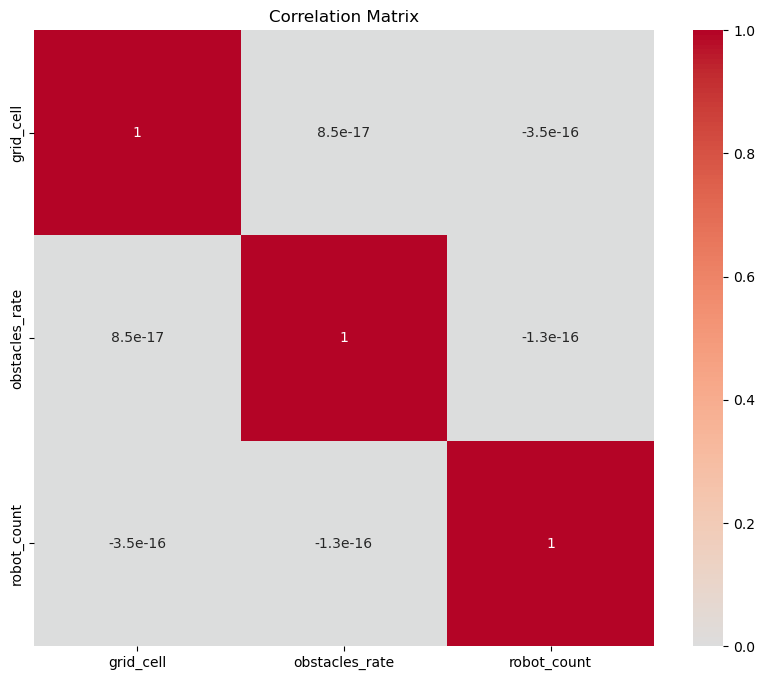

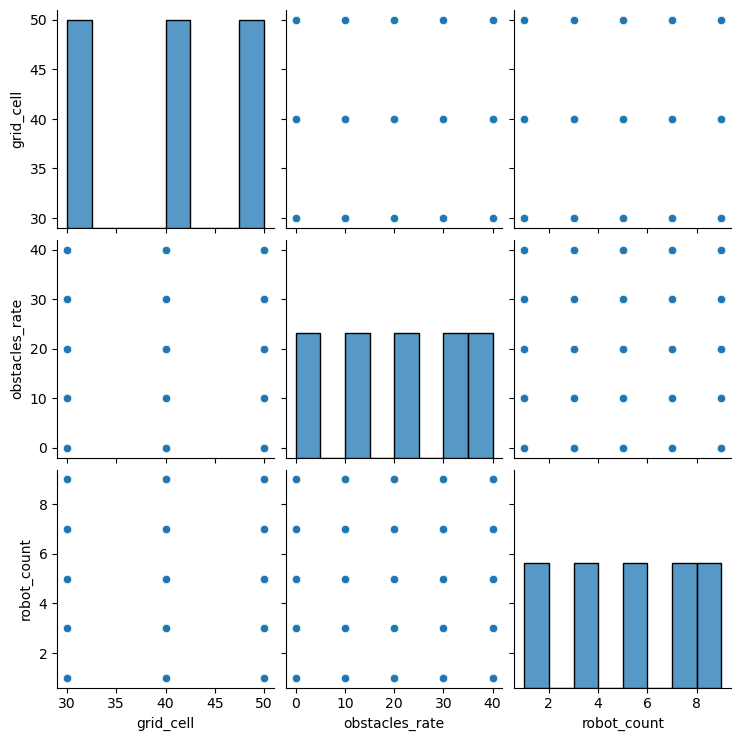

In [9]:
import pandas as pd
import seaborn as sns

experiment_data = pd.DataFrame(results)

# Calculation
correlation_matrix = experiment_data.corr(numeric_only=True)
print(correlation_matrix)

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Impliment
sns.pairplot(experiment_data)
plt.show()
